## 1. Environment

In [1]:
# =============================================================================
# 1. Environment
# =============================================================================
# Kaggle's GPU image already ships xarray / dask / netCDF4 / scipy / torch, so nothing is
# installed by default (pip on Kaggle is slow and occasionally breaks the preinstalled stack).
# Set INSTALL_MISSING = True only if the import check below reports something missing.
import os, sys, glob, json, math, time, shutil, warnings, subprocess
import numpy as np

INSTALL_MISSING = True

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

_missing = []
for _m in ("xarray", "netCDF4", "scipy", "dask", "cftime", "pandas", "torch","gsw", "matplotlib"):
    try:
        __import__(_m)
    except ImportError:
        _missing.append(_m)
if _missing:
    print("Missing packages:", _missing)
    if INSTALL_MISSING:
        _pip(*_missing)
    else:
        print("Set INSTALL_MISSING = True in this cell and re-run to install them.")

import xarray as xr
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*Converting non-nanosecond.*")

print("xarray", xr.__version__, "| numpy", np.__version__, "| torch", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  [{i}] {p.name} -- {p.total_memory/1e9:.1f} GB")
else:
    print("  No GPU. On Kaggle: Settings > Accelerator > GPU T4 x2.")


def detect_platform():
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        pass
    if os.path.exists("/kaggle/working"):
        return "kaggle"
    return "local"

PLATFORM = "kaggle"          # <-- override manually if needed, e.g. PLATFORM = "colab"
print("Platform:", PLATFORM)

Missing packages: ['netCDF4', 'cftime', 'gsw']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 70.7 MB/s eta 0:00:00
xarray 2025.12.0 | numpy 2.0.2 | torch 2.10.0+cu128
CUDA available: True
  [0] Tesla T4 -- 15.6 GB
  [1] Tesla T4 -- 15.6 GB
Platform: kaggle


## 2. Configuration

The only cell you normally need to edit. Paths are auto-discovered, so in most cases you can run straight through.

In [2]:
# =============================================================================
# 2. CONFIG  — the only cell you should normally need to edit
# =============================================================================
CFG = {}

# --- Where the raw data lives -------------------------------------------------
# Roots are searched (recursively, shallow) for *.nc files, which are then classified by
# folder/file name. Put the most likely location first. Both /kaggle/working (your case) and
# /kaggle/input (attached Dataset) are covered, so this works either way.
CFG["DATA_ROOT_CANDIDATES"] = [
    "/kaggle/working/OceanEmbed_Data",
    "/kaggle/working/data",
    "/kaggle/working",
    "/kaggle/input",
    "/content/drive/MyDrive/OceanEmbed_Data",
    "./OceanEmbed_Data",
]

# Folders that must never be scanned for raw inputs (they hold our own outputs).
CFG["SCAN_EXCLUDE"] = ("cache", "checkpoints", "outputs", ".git", "__pycache__", "oceanembed_cache",
                       "spare data files")   # excludes decoy files (e.g. multi-year "duacs_..._2016_2024.nc")

# --- Where our outputs go -----------------------------------------------------
if PLATFORM == "kaggle":
    CFG["WORK_ROOT"] = "/kaggle/working/OceanEmbed_run"
    # /kaggle/working is capped at ~20 GB and your raw data already sits there, so the cache is
    # placed on whichever of these has room (checked below). /kaggle/temp is session-scoped.
    CFG["CACHE_ROOT_CANDIDATES"] = ["/kaggle/working/OceanEmbed_run/cache", "/kaggle/temp/oceanembed_cache"]
elif PLATFORM == "colab":
    CFG["WORK_ROOT"] = "/content/drive/MyDrive/OceanEmbed_run"
    CFG["CACHE_ROOT_CANDIDATES"] = ["/content/oceanembed_cache", "/content/drive/MyDrive/OceanEmbed_run/cache"]
else:
    CFG["WORK_ROOT"] = "./OceanEmbed_run"
    CFG["CACHE_ROOT_CANDIDATES"] = ["./OceanEmbed_run/cache"]

CFG["CHECKPOINT_DIR"] = f"{CFG['WORK_ROOT']}/checkpoints"
CFG["OUTPUT_DIR"] = f"{CFG['WORK_ROOT']}/outputs"
CFG["STATS_DIR"] = f"{CFG['WORK_ROOT']}/stats"
for _d in (CFG["WORK_ROOT"], CFG["CHECKPOINT_DIR"], CFG["OUTPUT_DIR"], CFG["STATS_DIR"]):
    os.makedirs(_d, exist_ok=True)

# --- Variable names inside the files -----------------------------------------
# Section 3 verifies these against your actual files and tells you exactly what to change.
CFG["VAR_NAMES"] = {
    "sst":         {"var": "analysed_sst", "lat": "lat",      "lon": "lon",       "time": "time"},
    "sss":         {"var": "sss_smap",     "lat": "latitude",      "lon": "longitude",       "time": "time"},
    "adt":         {"var": "adt",          "lat": "latitude", "lon": "longitude", "time": "time"},
    "current_u":   {"var": "u",            "lat": "latitude", "lon": "longitude", "time": "time"},
    "current_v":   {"var": "v",            "lat": "latitude", "lon": "longitude", "time": "time"},
    "wind_u":      {"var": "u10",          "lat": "latitude", "lon": "longitude", "time": "time"},
    "wind_v":      {"var": "v10",          "lat": "latitude", "lon": "longitude", "time": "time"},
    "glorys_temp": {"var": "thetao",       "lat": "latitude", "lon": "longitude", "time": "time", "depth": "depth"},
    "argo_temp":   {"var": "temperature",  "lat": "lat",      "lon": "lon",       "time": "time", "depth": "depth"},
}

# GLORYS is one file per depth level; the depth is parsed from the filename when the file itself
# does not carry a usable depth coordinate. Matches ..._thetao_..._380.21m_2016-01-01-....nc
CFG["GLORYS_DEPTH_REGEX"] = r"_(\d+(?:\.\d+)?)m_"

# --- Domain & grid ------------------------------------------------------------
CFG["LAT_MIN"], CFG["LAT_MAX"] = 5.0, 30.0
CFG["LON_MIN"], CFG["LON_MAX"] = 45.0, 105.0
CFG["RES_DEG"] = 0.25
CFG["NATIVE_H"] = int(round((CFG["LAT_MAX"] - CFG["LAT_MIN"]) / CFG["RES_DEG"])) + 1   # 101
CFG["NATIVE_W"] = int(round((CFG["LON_MAX"] - CFG["LON_MIN"]) / CFG["RES_DEG"])) + 1   # 241
CFG["PAD_H"], CFG["PAD_W"] = 112, 256      # multiples of 16 (5 pooling levels)

CFG["STANDARD_DEPTHS"] = np.array(
    [0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700, 1000], dtype="float32")
CFG["N_DEPTHS"] = len(CFG["STANDARD_DEPTHS"])       # 15

CFG["CHANNEL_ORDER"] = ["sst", "sss", "adt", "current_u", "current_v", "wind_u", "wind_v"]
CFG["USE_LAND_MASK_CHANNEL"] = True
CFG["N_CHANNELS"] = len(CFG["CHANNEL_ORDER"]) + (1 if CFG["USE_LAND_MASK_CHANNEL"] else 0)   # 8
CFG["TIME_WINDOW"] = 15                              # T = D -- must equal N_DEPTHS (the network
                                                     # maps the input time axis to the output depth axis)

# --- Missing-day handling (this is what fixes the SSH gap) --------------------
CFG["IMPUTE_PAD_DAYS"] = 30         # look this far outside each chunk for neighbours to interpolate from
CFG["MAX_IMPUTE_GAP_DAYS"] = 20     # longer gaps are filled by carrying the nearest available day instead
CFG["MAX_IMPUTE_FRAC"] = 0.20       # a channel missing more than this fraction => those days are dropped
CFG["ARGO_BAD_FLAG_THRESHOLD"] = -900.0   # LAS/CSV exports flag missing as -9999

CFG["MIN_VALID_DAY_FRAC"] = 0.05

# --- Cache ---------------------------------------------------------------------
CFG["CACHE_DTYPE"] = "float16"      # cache stores NORMALISED values, so fp16 is ~5e-4 precise (~0.02 degC)
CFG["PREPROCESS_CHUNK_DAYS"] = 45   # days per pass-2 write chunk (RAM/throughput trade-off)
CFG["STATS_CHUNK_STRIDE"] = 4       # statistics pass reads every Nth chunk of training days (cheap, accurate)

# --- Model ----------------------------------------------------------------------
CFG["MODEL_SIZE"] = "lite"          # "lite" (~6.3M) or "full" (~25.3M)
CFG["F_MAPS"] = {"full": (32, 64, 128, 256, 512), "lite": (16, 32, 64, 128, 256)}[CFG["MODEL_SIZE"]]
CFG["DROPOUT"] = 0.1
CFG["CBAM_REDUCTION"] = 16
CFG["DEEP_SUPERVISION"] = False

# --- Loss -----------------------------------------------------------------------
CFG["LOSS_KIND"] = "mse"
CFG["THERMOCLINE_DEPTHS"] = (75, 100, 125, 150, 200)
CFG["THERMOCLINE_WEIGHT"] = 1.5

# --- Training --------------------------------------------------------------------
CFG["NUM_GPUS"] = torch.cuda.device_count() if torch.cuda.is_available() else 0
CFG["BATCH_SIZE_PER_GPU"] = 2       # 2 is safe for 15x112x256 volumes on a 15 GB T4 with AMP
CFG["GRAD_ACCUM_STEPS"] = 1
CFG["BATCH_SIZE"] = CFG["BATCH_SIZE_PER_GPU"] * max(CFG["NUM_GPUS"], 1)
CFG["NUM_WORKERS"] = 2 if PLATFORM == "kaggle" else 0
CFG["USE_AMP"] = torch.cuda.is_available()

CFG["PRETRAIN_LR"], CFG["FINETUNE_LR"] = 3e-4, 1e-4
CFG["WEIGHT_DECAY"] = 1e-4
CFG["GRAD_CLIP_NORM"] = 5.0
CFG["PRETRAIN_EPOCHS"] = 30
CFG["FINETUNE_EPOCHS"] = 9        # realistic for one Kaggle session; raise if you resume
CFG["EARLY_STOP_PATIENCE"] = 5
CFG["TRAIN_WINDOW_STRIDE"] = 1      # 2 = use every 2nd training window (halves epoch time)
CFG["MAX_TRAIN_HOURS"] = 8.0        # stop cleanly before Kaggle's 12 h limit; checkpoints are resumable
CFG["LOG_EVERY_N_BATCHES"] = 25
CFG["SEED"] = 42

# --- Split by year ----------------------------------------------------------------
CFG["FINETUNE_TRAIN_YEARS"] = list(range(2016, 2022))
CFG["FINETUNE_VAL_YEARS"] = [2022]
CFG["FINETUNE_TEST_YEARS"] = [2023]
CFG["SPLIT_MODE"] = "year"           # "year" (default) or "fraction" (70/15/15 by index, for short records)
CFG["ENABLE_PRETRAINING"] = True     # Stage 1 is skipped automatically if Gridded Argo is unusable
CFG["PRETRAIN_VAL_FRAC"] = 0.25      # last 25% of available Argo months used for validation

np.random.seed(CFG["SEED"])
torch.manual_seed(CFG["SEED"])
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("Grid:", CFG["NATIVE_H"], "x", CFG["NATIVE_W"], "-> padded", CFG["PAD_H"], "x", CFG["PAD_W"])
print("Channels:", CFG["N_CHANNELS"], "| window T =", CFG["TIME_WINDOW"], "| depths D =", CFG["N_DEPTHS"])
print("GPUs:", CFG["NUM_GPUS"], "| batch", CFG["BATCH_SIZE"], "| AMP", CFG["USE_AMP"])

Grid: 101 x 241 -> padded 112 x 256
Channels: 8 | window T = 15 | depths D = 15
GPUs: 2 | batch 4 | AMP True


In [3]:
# --- GNN-OAM: artifacts (frozen lookup tables, fitted RF models) ------------------------------------
CFG["ARTIFACT_DIR"] = f"{CFG['WORK_ROOT']}/gnn_artifacts"
os.makedirs(CFG["ARTIFACT_DIR"], exist_ok=True)

# --- GNN-OAM: window, tiling, graph (spec Sec. 6, 8, 13) --------------------------------------------
CFG["T_WINDOW"] = 30                 # T-day surface history for the RF module + PCC similarity graph (spec: 30-60)
CFG["TILE_SIZE"] = 12                # lat-lon cells per tile INCLUDING the halo -> 12*12*15 = 2,160 nodes (spec: 1,000-4,000)
CFG["HALO"] = 2                      # halo width (cells); tile 'core' = TILE_SIZE - 2*HALO = 8
CFG["MIN_OCEAN_COL_FRAC"] = 0.25     # a TRAINING tile must contain at least this fraction of ocean columns
CFG["SIM_THRESHOLD"] = 0.9           # S0 in A^S_ij = 1 if PCC_ij >= S0   (GNN-OAM's value; re-tune with Section 11 diagnostics)
CFG["SIM_MAX_PARTNERS"] = 4          # memory guard: top-m most similar partner columns per column. None = literal spec
CFG["SIM_DEPTH_PAIRING"] = "all"     # "all" = literal spec (PCC is per column => all depth pairs); "same" = equal-depth pairs only

# --- Column regressor (spec Sec. 7.1) -- XGBoost gradient-boosted trees (replaces Random Forest) ----
CFG["RF_TREES"] = 10                 # boosting rounds per model (kept at the same default as before)
CFG["XGB_MAX_DEPTH"] = 6             # XGBoost's own default tree depth
CFG["XGB_LEARNING_RATE"] = 0.3       # XGBoost's own default shrinkage
CFG["RF_MAX_FEATURES"] = 0.5         # -> colsample_bynode (per-node column subsample)
CFG["RF_MIN_LEAF"] = 20              # -> min_child_weight (~ minimum samples per leaf, squared-error loss)
CFG["RF_MAX_SAMPLES"] = 0.7          # -> subsample (per-tree row subsample)
CFG["RF_TRAIN_DAYS"] = 400           # training days sampled for the model (spread over the training years)
CFG["RF_ROWS_PER_DAY"] = 500         # random ocean columns per sampled day  (400*500 = 200k rows)
CFG["RF_CROSSFIT"] = True            # out-of-fold z_col for training days (strongly recommended; see Section 9)
CFG["RF_N_FOLDS"] = 3
CFG["RF_PRED_CHUNK_DAYS"] = 4
CFG["RF_N_JOBS"] = -1

# --- Encoder (spec Sec. 7.2-7.4, 13) -----------------------------------------------------------------
CFG["D_MODEL"] = 128
CFG["D_DEPTH"] = 32                  # learned DepthEnc dimension; the RF embedding gets the remaining D_MODEL - D_DEPTH
CFG["ATTN_DIM"] = 32                 # hidden dimension d of the OAM heads (BFC: D_MODEL -> d, FFC: d -> D_MODEL)
CFG["HEADS"] = 4                     # C
CFG["LAYERS"] = 6                    # L
CFG["PHI_HIDDEN"] = 64               # hidden width of the 2-layer skip MLP phi_skip
CFG["USE_LAYERNORM"] = True          # LayerNorm on entry to every BFC block (stabiliser; not in the paper)

# --- Cluster discovery (spec Sec. 7.3.1) -------------------------------------------------------------
CFG["TIME_BINS"] = 52                # day-of-year bins of the time meta-graph
CFG["K_RANGE"] = (2, 8)              # eigengap search range for depth clusters K
CFG["M_RANGE"] = (2, 8)              # eigengap search range for season regimes M
CFG["K_OVERRIDE"] = None             # set an int to bypass the eigengap and force K   (leave None for the spec behaviour)
CFG["M_OVERRIDE"] = None
CFG["DEPTH_PCC_MODE"] = "raw"        # "raw" = literal spec (pooled T_true);  "anomaly" = PCC of per-column temporal anomalies
CFG["DEPTH_PCC_DAY_STRIDE"] = 3      # use every Nth training day when building the depth meta-graph (cheap, accurate)

# --- Loss (spec Sec. 9) --------------------------------------------------------------------------------
CFG["LAMBDAS"] = (0.5, 0.3, 0.2)     # (lambda1, lambda2, lambda3)  PGTransNet optimum
CFG["LAMBDA_MONO"] = 0.0             # lambda4 for the optional density-monotonicity term (0 = off)
CFG["USE_DEPTH_WEIGHTS"] = False     # False -> w_k = 1 (spec default). True -> thermocline weighting of your U-Net notebook
CFG["THERMOCLINE_DEPTHS"] = (75, 100, 125, 150, 200)
CFG["THERMOCLINE_WEIGHT"] = 1.5
CFG["LAMBDA_RAMP_EPOCHS"] = 3        # the lambda terms are ramped linearly over the first epochs (spec 'lambda schedule')

# --- Training ---------------------------------------------------------------------------------------------
CFG["NUM_GPUS"] = torch.cuda.device_count() if torch.cuda.is_available() else 0
CFG["BATCH_TILES"] = 6               # tiles per step. Lower to 3-4 on a 6 GB GPU (edge tensors dominate memory)
CFG["STEPS_PER_EPOCH"] = 1000        # random (day, tile) draws per epoch = STEPS_PER_EPOCH * BATCH_TILES
CFG["VAL_TILES"] = 1500              # fixed validation tiles (same every epoch => comparable val curves)
CFG["EPOCHS"] = 30
CFG["LR"] = 5e-4
CFG["WEIGHT_DECAY"] = 1e-4
CFG["GRAD_CLIP_NORM"] = 5.0
CFG["EARLY_STOP_PATIENCE"] = 6
CFG["MAX_TRAIN_HOURS"] = 3.0         # per variant; checkpoints are resumable across sessions
CFG["LOG_EVERY_N_BATCHES"] = 100
CFG["NUM_WORKERS"] = 2 if PLATFORM == "kaggle" else 0
CFG["SEED"] = 42

# --- Which model variants to train (spec Sec. 11 ablation) ---------------------------------------------
#   A_base : GNN-OAM encoder alone, plain masked MSE on T         (no cluster skip, no physics)
#   B_skip : A + cluster skip connection                          (plain MSE)
#   C_full : B + physics-guided composite loss (needs salinity)   <- the full spec architecture
CFG["RUN_VARIANTS"] = ["C_full"]     # e.g. ["A_base", "B_skip", "C_full"] to run the whole ablation

# --- Evaluation --------------------------------------------------------------------------------------------
CFG["EVAL_DAY_STRIDE"] = 1           # 1 = every test day (like the U-Net notebook). Raise to 2-7 for a faster evaluation
CFG["EVAL_BATCH_TILES"] = 12
CFG["DENSITY_EVAL_DAY_STRIDE"] = 10  # density-consistency metrics are computed on every Nth evaluated day
CFG["SUBBASINS"] = {"Arabian Sea": (45.0, 77.0), "Bay of Bengal": (80.0, 100.0)}   # longitude ranges (deg E)

# --- Split by year (identical to the U-Net notebook) -------------------------------------------------------
CFG["FINETUNE_TRAIN_YEARS"] = list(range(2016, 2022))
CFG["FINETUNE_VAL_YEARS"] = [2022]
CFG["FINETUNE_TEST_YEARS"] = [2023]
CFG["SPLIT_MODE"] = "year"           # "year" (default) or "fraction" (70/15/15 by index, for short records)

np.random.seed(CFG["SEED"])
torch.manual_seed(CFG["SEED"])
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Grid:", CFG["NATIVE_H"], "x", CFG["NATIVE_W"], "| surface channels:", CFG["CHANNEL_ORDER"])
print("T window =", CFG["T_WINDOW"], "| tile =", CFG["TILE_SIZE"], "(halo", CFG["HALO"], ") ->",
      CFG["TILE_SIZE"] ** 2 * CFG["N_DEPTHS"], "nodes/tile | depths =", CFG["N_DEPTHS"])
print("Device:", DEVICE, "| variants:", CFG["RUN_VARIANTS"])

Grid: 101 x 241 | surface channels: ['sst', 'sss', 'adt', 'current_u', 'current_v', 'wind_u', 'wind_v']
T window = 30 | tile = 12 (halo 2 ) -> 2160 nodes/tile | depths = 15
Device: cuda | variants: ['C_full']


## 3. Data discovery and variable-name verification

In [4]:
# =============================================================================
# 3. Data discovery + variable-name verification (auto-corrects where it safely can)
# =============================================================================
import re

_CLASSIFY_RULES = [
    # (key, tuple of lowercase substrings, any of which identifies the file)
    ("glorys_temp", ("glorys", "thetao", "cmems_mod_glo")),
    ("argo_temp",   ("argo", "validation", "incois")),
    ("sst",         ("sst", "podaac", "mur")),
    ("sss",         ("sss", "smap", "salinity")),
    ("adt",         ("ssh", "adt", "sla", "duacs", "sealevel")),
    ("current_u",   ("oscar", "current")),
    ("wind_u",      ("wind", "era5")),
]


def _scan_nc_files(root, max_depth=4):
    out = []
    root = os.path.abspath(root)
    if not os.path.isdir(root):
        return out
    base_depth = root.rstrip("/").count("/")
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames
                       if d.lower() not in CFG["SCAN_EXCLUDE"] and not d.startswith(".")]
        if dirpath.count("/") - base_depth >= max_depth:
            dirnames[:] = []
        for fn in filenames:
            if fn.lower().endswith((".nc", ".nc4", ".grib", ".grb", ".grib2")):
                out.append(os.path.join(dirpath, fn))
    return out


def discover_sources(verbose=True):
    """Classify every NetCDF/GRIB file under candidate roots into CFG['RAW_PATHS']."""
    files = []
    used_roots = []
    for root in CFG["DATA_ROOT_CANDIDATES"]:
        found = _scan_nc_files(root)
        new = [f for f in found if f not in files]
        if new:
            files.extend(new)
            used_roots.append((root, len(new)))

    paths = {k: [] for k in list(CFG["VAR_NAMES"].keys())}
    unmatched = []

    for f in sorted(set(files)):
        low = f.lower()
        hit = None
        for key, keys in _CLASSIFY_RULES:
            if any(s in low for s in keys):
                hit = key
                break
        if hit is None:
            unmatched.append(f)
            continue
        # Avoid duplicate basenames from redundant search roots
        if not any(os.path.basename(f) == os.path.basename(x) for x in paths[hit]):
            paths[hit].append(f)

    # u and v live in the same physical files
    paths["current_v"] = list(paths["current_u"])
    paths["wind_v"] = list(paths["wind_u"])

    if verbose:
        print("Scanned roots:", used_roots or "(none found!)")
        for k in CFG["VAR_NAMES"]:
            n = len(paths[k])
            sample = os.path.basename(paths[k][0]) if n else "--"
            flag = "" if n else "   <-- NOTHING FOUND"
            print(f"  {k:12s}: {n:3d} file(s)   e.g. {sample}{flag}")
        if unmatched:
            print(f"  ({len(unmatched)} file(s) not classified, ignored -- e.g. "
                  f"{os.path.basename(unmatched[0])})")
    return paths


CFG["RAW_PATHS"] = discover_sources()
# Retain only smap2_sss_india_combined and drop SSS_2024
CFG["RAW_PATHS"]["sss"] = [f for f in CFG["RAW_PATHS"]["sss"] if "smap2_sss_india_combined" in f]

_LAT_CANDS = ["lat", "latitude", "nav_lat", "y", "Latitude", "LATITUDE"]
_LON_CANDS = ["lon", "longitude", "nav_lon", "x", "Longitude", "LONGITUDE"]
_TIME_CANDS = ["time", "TIME", "valid_time", "date", "t"]
_DEPTH_CANDS = ["depth", "deptht", "lev", "level", "z", "DEPTH", "pressure"]
_VAR_HINTS = {
    "sst": ["analysed_sst", "sst", "sea_surface_temperature", "temperature"],
    # Included sss_smap_40km as primary alternative for SMAP
    "sss": [ "sss_smap","sss_smap_40km", "sss", "smap_sss", "salinity", "sea_surface_salinity", "so"],
    "adt": ["adt", "zos", "ssh", "sla", "sea_surface_height", "absolute_dynamic_topography"],
    "current_u": ["u", "ug", "uo", "u_current", "eastward_current", "usurf"],
    "current_v": ["v", "vg", "vo", "v_current", "northward_current", "vsurf"],
    "wind_u": ["u10", "u_10", "eastward_wind", "uwnd", "u"],
    "wind_v": ["v10", "v_10", "northward_wind", "vwnd", "v"],
    "glorys_temp": ["thetao", "temperature", "temp", "to"],
    "argo_temp": ["temperature", "temp", "TEMP", "thetao", "t_an"],
}


def _pick(names, candidates):
    for c in candidates:
        if c in names:
            return c
    return None


def _has_finite_data(da):
    """Quickly check whether a variable's first slice contains finite values."""
    try:
        sub = da
        for d in sub.dims:
            if d not in ("lat", "latitude", "lon", "longitude"):
                sub = sub.isel({d: 0})
        return bool(np.isfinite(np.asarray(sub.values)).any())
    except Exception:
        return False


def verify_variables(verbose=True):
    """Open one file per variable, verify data integrity, and auto-correct CFG['VAR_NAMES']."""
    report = {}
    for key, meta in CFG["VAR_NAMES"].items():
        files = CFG["RAW_PATHS"].get(key) or []
        if not files:
            report[key] = "NO FILES"
            continue
        path = files[0]
        engine = "cfgrib" if path.lower().endswith((".grib", ".grb", ".grib2")) else None

        # Fallback to use_cftime=True if standard time decoding fails on Julian calendars
        try:
            ds = xr.open_dataset(path, engine=engine, decode_times=True)
        except Exception:
            try:
                ds = xr.open_dataset(path, engine=engine, decode_times=True, use_cftime=True)
            except Exception as e:
                report[key] = f"OPEN FAILED: {e}"
                continue

        try:
            names = set(ds.variables) | set(ds.dims)
            fixed = []

            # 1. Resolve coordinates
            for axis, cands in (("lat", _LAT_CANDS), ("lon", _LON_CANDS), ("time", _TIME_CANDS)):
                if meta.get(axis) not in names:
                    got = _pick(names, cands)
                    if got:
                        meta[axis] = got
                        fixed.append(f"{axis}->{got}")
            if "depth" in meta and meta["depth"] not in names:
                got = _pick(names, _DEPTH_CANDS)
                if got:
                    meta["depth"] = got
                    fixed.append(f"depth->{got}")

            # 2. Resolve variable name
            if meta["var"] not in ds.data_vars:
                got = _pick(list(ds.data_vars), _VAR_HINTS.get(key, []))
                if got is None and len(ds.data_vars) == 1:
                    got = list(ds.data_vars)[0]
                if got:
                    meta["var"] = got
                    fixed.append(f"var->{got}")

            # 3. Verify non-NaN data presence; switch to valid candidate if current is empty
            if meta["var"] in ds.data_vars:
                if not _has_finite_data(ds[meta["var"]]):
                    for cand in _VAR_HINTS.get(key, []):
                        if cand in ds.data_vars and cand != meta["var"] and _has_finite_data(ds[cand]):
                            fixed.append(f"var: '{meta['var']}' was all-NaN -> switched to '{cand}'")
                            meta["var"] = cand
                            break

            ok = meta["var"] in ds.data_vars
            report[key] = ("OK" if ok else "VARIABLE NOT FOUND") + (f"  (auto-fixed {', '.join(fixed)})" if fixed else "")

            if verbose:
                print(f"[{key}] {os.path.basename(path)}")
                print(f"    data_vars: {list(ds.data_vars)}")
                print(f"    dims     : {dict(ds.sizes)}")
                print(f"    using    : var='{meta['var']}' lat='{meta['lat']}' lon='{meta['lon']}' "
                      f"time='{meta['time']}'" + (f" depth='{meta['depth']}'" if 'depth' in meta else ""))
                print(f"    -> {report[key]}\n")
        finally:
            ds.close()

    # Flush stale cached arrays in memory
    if "_PARTS_CACHE" in globals():
        globals()["_PARTS_CACHE"].clear()

    bad = {k: v for k, v in report.items() if not v.startswith("OK")}
    if bad:
        print("!! Problems that must be fixed before going further:", json.dumps(bad, indent=2))
        print("   Edit CFG['VAR_NAMES'] / CFG['RAW_PATHS'] in the CONFIG cell and re-run this cell.")
    else:
        print("All variables resolved successfully.")
    return report


VAR_REPORT = verify_variables()

Scanned roots: [('/kaggle/working', 31), ('/kaggle/input', 44)]
  sst         :   3 file(s)   e.g. SST_2016_2023.nc
  sss         :   2 file(s)   e.g. SSS_2024 (1).nc
  adt         :   2 file(s)   e.g. SSH_2016_2023.nc
  current_u   :   2 file(s)   e.g. OSCAR_currents_2016_2023.nc
  current_v   :   2 file(s)   e.g. OSCAR_currents_2016_2023.nc
  wind_u      :   2 file(s)   e.g. ERA5_winds_2016_2023.nc
  wind_v      :   2 file(s)   e.g. ERA5_winds_2016_2023.nc
  glorys_temp :  63 file(s)   e.g. cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao_45.00E-105.00E_5.00N-30.00N_1062.44m_2016-01-01-2023-12-31.nc
  argo_temp   :   1 file(s)   e.g. incois_argo_validation_2yr_claude_convertedfromcsv.nc
[sst] SST_2016_2023.nc
    data_vars: ['analysed_sst', 'analysis_error', 'mask', 'sea_ice_fraction', 'sst_anomaly']
    dims     : {'time': 2922, 'lat': 100, 'lon': 240}
    using    : var='analysed_sst' lat='lat' lon='lon' time='time'
    -> OK

[sss] smap2_sss_india_combined.nc
    data_vars: ['smap_sss']

### 3b. Shared file scan cache, then discover GLORYS salinity files (needed for the physics-guided loss)

Your dataset now spans many more folders than a single flat scan expects — GLORYS salinity in particular arrives as **five
separately-named folders** (`GLORYS SSS-<timestamp>-1-001` .. `-005`, Drive's naming when a folder is exported as a multi-part
zip), each holding a subset of the 30-odd depth files. `_all_data_files()` below walks every `CFG["DATA_ROOT_CANDIDATES"]` root
**once** and caches the result, so this cell and Section 24 both reuse the same scan instead of each repeating a full
filesystem walk per variable — on a large, deeply-nested dataset that repeated-walk pattern is what made the discovery cell
look stuck earlier. It also excludes a `Spare Data Files`-style folder some of you have lying around (added to
`CFG["SCAN_EXCLUDE"]` in the Configuration cell): it contains decoys such as a `duacs_ssh_sla_..._2016_2024.nc` file that would
otherwise get pulled into the SSH channel alongside your real `SSH_2024.nc`, and a combined-currents "spare" file likewise.

Salinity files themselves are told apart from temperature files by **opening each candidate and checking its actual
variables**, never by filename alone — this also catches the common case where CMEMS temperature and salinity products share a
`cmems_mod_glo...` filename prefix and Section 3's classifier has already (wrongly) swept salinity files into `glorys_temp`.

**The same cleanup also removes any file with more than one native depth level** (checked generically, not by year or
filename) — because your Kaggle input mount is static for the whole session, a combined multi-level export like `GLORYS 2024`
is visible from the very first cell, not just once a later "2024 fine-tuning" section runs, so without this it would silently
corrupt the *original* one-file-per-depth reader used for 2016–2023 training. A dedicated reader (added further down, for
whichever year needs it) handles a combined file like that instead.

**A sharper version of the same problem is also fixed here.** Section 3's `verify_variables()` inspects
`CFG["RAW_PATHS"]["glorys_temp"][0]` to auto-resolve the variable name — and a folder named `GLORYS SSS-...` sorts
*alphabetically before* `GLORYS/` (a space is ASCII-lower than `/`), so if any salinity or multi-depth folder is present, that
first entry may not be a real one-file-per-depth temperature file. Section 3 then sees the wrong data variable and "fixes"
`CFG["VAR_NAMES"]["glorys_temp"]["var"]` to it — which then breaks `load_glorys_days()` on every real temperature file for the
rest of the run with a plain `KeyError`. `_reverify_glorys_temp_var()` re-checks that setting once `RAW_PATHS["glorys_temp"]`
has been cleaned up above, and restores it if needed.

In [5]:
# =============================================================================
# 3b. Shared file-scan cache + GLORYS salinity ('so') discovery -- additive, does not modify Section 3
# =============================================================================
CFG["VAR_NAMES"]["glorys_sal"] = {"var": "so", "lat": "latitude", "lon": "longitude", "time": "time", "depth": "depth"}
CFG.setdefault("SCAN_MAX_DEPTH", 10)     # generous: multi-part Drive-zip exports nest a folder or two deeper than 4

_ALL_NC_FILES_CACHE = {"files": None}


def _all_data_files(force=False, verbose=True):
    """Scan every CFG['DATA_ROOT_CANDIDATES'] root ONCE for .nc/.nc4/.grib file(s) and cache the result.
    Reused by this cell and by Section 24 -- avoids repeating a full filesystem walk per variable, which
    is what makes discovery slow (and look 'stuck') once the dataset has many nested folders."""
    if _ALL_NC_FILES_CACHE["files"] is not None and not force:
        return _ALL_NC_FILES_CACHE["files"]
    t0 = time.time()
    files = []
    for root in CFG["DATA_ROOT_CANDIDATES"]:
        if not os.path.isdir(root):
            continue
        found = _scan_nc_files(root, max_depth=CFG["SCAN_MAX_DEPTH"])
        if verbose:
            print(f"  scanned {root}: {len(found)} file(s) so far {time.time()-t0:.1f}s", flush=True)
        files.extend(found)
    files = sorted(set(os.path.abspath(f) for f in files))
    _ALL_NC_FILES_CACHE["files"] = files
    if verbose:
        print(f"Scanned {len(CFG['DATA_ROOT_CANDIDATES'])} root(s) -> {len(files)} total data file(s) "
             f"in {time.time()-t0:.1f}s (cached for reuse by later cells).")
    return files


def _looks_like_salinity(path, ds=None):
    close = ds is None
    try:
        ds = ds or xr.open_dataset(path, chunks={})
        has = ("so" in ds.data_vars) or any("salin" in v.lower() for v in ds.data_vars)
        return has
    except Exception:
        return False
    finally:
        if close and ds is not None:
            ds.close()


def _native_depth_count(path, ds=None):
    """How many native depth levels a file actually has (1 for the expected one-file-per-depth layout;
    >1 for a combined multi-level export like a 'GLORYS 2024'-style file)."""
    close = ds is None
    try:
        ds = ds or xr.open_dataset(path, chunks={})
        dkey = _pick(set(ds.variables) | set(ds.dims), _DEPTH_CANDS)
        if dkey and dkey in ds.variables:
            return int(np.atleast_1d(np.asarray(ds[dkey].values)).size)
        return 1
    except Exception:
        return 1
    finally:
        if close and ds is not None:
            ds.close()


def discover_glorys_salinity(verbose=True):
    """Finds GLORYS salinity ('so') files, wherever they are nested (aggregates across a multi-part-zip
    split automatically -- it's just a flat scan + a content check, folder layout doesn't matter).

    Also cleans 'glorys_temp' of anything that doesn't belong in a one-file-per-depth reader: CMEMS
    temperature and salinity products often share a 'cmems_mod_glo...' filename prefix, so Section 3's
    classifier sweeps salinity files in by pattern alone; and a combined multi-level export (e.g. a new
    year's GLORYS file covering every depth in one file, however it's named) matches the same filename
    pattern too but must NOT go through glorys_parts()'s one-file-per-depth assumption. Both are removed
    here by opening each file and checking its actual variables/dimensions, not by year or filename.
    A folder that happens to sort alphabetically before 'GLORYS/' (e.g. a salinity or multi-depth folder
    with a name starting with a space where 'GLORYS/' has a slash) can otherwise cause Section 3's
    verify_variables() to resolve CFG['VAR_NAMES']['glorys_temp']['var'] against the WRONG file --
    _reverify_glorys_temp_var() below re-checks that once this cleanup is done."""
    reclassified_sal, reclassified_multi, still_temp = [], [], []
    for p in CFG["RAW_PATHS"].get("glorys_temp", []):
        ds = xr.open_dataset(p, chunks={})
        try:
            if _looks_like_salinity(p, ds=ds):
                reclassified_sal.append(p)
            elif _native_depth_count(p, ds=ds) > 1:
                reclassified_multi.append(p)
            else:
                still_temp.append(p)
        finally:
            ds.close()
    if reclassified_sal or reclassified_multi:
        CFG["RAW_PATHS"]["glorys_temp"] = still_temp
        if reclassified_sal:
            print(f"NOTE: {len(reclassified_sal)} file(s) matched the 'glorys_temp' filename pattern in Section 3 "
                 f"but actually contain salinity -- moved to 'glorys_sal'. "
                 f"e.g. {os.path.basename(reclassified_sal[0])}")
        if reclassified_multi:
            print(f"NOTE: {len(reclassified_multi)} file(s) matched the 'glorys_temp' filename pattern but contain "
                 f"MULTIPLE native depth levels in one file (not the expected one-file-per-depth layout) -- "
                 f"removed from 'glorys_temp'. e.g. {os.path.basename(reclassified_multi[0])}. A dedicated reader "
                 f"for a combined multi-level file (like Section 24's 2024 reader) should handle these instead.")

    already = set()
    for k in CFG["RAW_PATHS"]:
        already |= {os.path.abspath(p) for p in CFG["RAW_PATHS"][k]}
    candidates = [f for f in _all_data_files() if f not in already]
    found = list(reclassified_sal)
    for p in candidates:
        low = os.path.basename(p).lower()
        if not any(h in low for h in ("glorys", "cmems_mod_glo", "salinity", "_so_", "-so-")):
            continue
        if _looks_like_salinity(p):
            found.append(p)
    CFG["RAW_PATHS"]["glorys_sal"] = sorted(set(found))
    if verbose:
        by_dir = {}
        for f in CFG["RAW_PATHS"]["glorys_sal"]:
            by_dir.setdefault(os.path.dirname(f), 0)
            by_dir[os.path.dirname(f)] += 1
        print(f"GLORYS salinity ('so'): {len(CFG['RAW_PATHS']['glorys_sal'])} file(s) total, "
             f"across {len(by_dir)} folder(s):")
        for d, n in sorted(by_dir.items()):
            print(f"    {n:3d}  {d}")
        if not CFG["RAW_PATHS"]["glorys_sal"]:
            print("  NONE found -- physics-guided loss (C_full) will be unavailable until salinity files "
                 "are added and this cell is re-run.")
    return CFG["RAW_PATHS"]["glorys_sal"]


discover_glorys_salinity()


def _reverify_glorys_temp_var():
    """Section 3's verify_variables() opens CFG['RAW_PATHS']['glorys_temp'][0] to auto-resolve the
    variable name -- if a salinity file sorted alphabetically first at that point (e.g. a folder named
    'GLORYS SSS-...' sorts before 'GLORYS/', since a space is ASCII-lower than '/'), it would have seen
    only one data_var ('so') and wrongly set CFG['VAR_NAMES']['glorys_temp']['var'] = 'so'. Now that
    discover_glorys_salinity() has cleaned RAW_PATHS['glorys_temp'], re-check against a REAL entry."""
    files = CFG["RAW_PATHS"].get("glorys_temp") or []
    if not files:
        return
    meta = CFG["VAR_NAMES"]["glorys_temp"]
    ds = xr.open_dataset(sorted(files)[0], chunks={})
    try:
        if meta["var"] not in ds.data_vars:
            got = _pick(list(ds.data_vars), _VAR_HINTS["glorys_temp"])
            if got is None and len(ds.data_vars) == 1:
                got = list(ds.data_vars)[0]
            if got and got != meta["var"]:
                print(f"NOTE: CFG['VAR_NAMES']['glorys_temp']['var'] was '{meta['var']}' (wrongly resolved "
                     f"in Section 3 against a misclassified file) -> corrected to '{got}'.")
                meta["var"] = got
    finally:
        ds.close()
    if "_GLORYS_CACHE" in globals():
        _GLORYS_CACHE.clear()          # drop anything cached under the wrong variable name


_reverify_glorys_temp_var()

NOTE: 31 file(s) matched the 'glorys_temp' filename pattern but contain MULTIPLE native depth levels in one file (not the expected one-file-per-depth layout) -- removed from 'glorys_temp'. e.g. thetao_2024-12-01.nc. A dedicated reader for a combined multi-level file (like Section 24's 2024 reader) should handle these instead.
  scanned /kaggle/working: 31 file(s) so far 0.0s
  scanned /kaggle/input: 77 file(s) so far 0.1s
Scanned 6 root(s) -> 108 total data file(s) in 0.1s (cached for reuse by later cells).
GLORYS salinity ('so'): 32 file(s) total, across 5 folder(s):
      9  /kaggle/input/datasets/sayanmajee21/oceanembed-data/GLORYS SSS-20260923T173345Z-1-001/GLORYS SSS
      7  /kaggle/input/datasets/sayanmajee21/oceanembed-data/GLORYS SSS-20260923T173345Z-1-002/GLORYS SSS
      6  /kaggle/input/datasets/sayanmajee21/oceanembed-data/GLORYS SSS-20260923T173345Z-1-003/GLORYS SSS
      6  /kaggle/input/datasets/sayanmajee21/oceanembed-data/GLORYS SSS-20260923T173345Z-1-004/GLORYS SSS
 

## 4. Harmonisation, day-alignment and missing-day imputation

`load_days()` is the function that fixes the original crash: it guarantees every variable comes back with shape `(len(days), H, W)` for the exact day list requested.

In [6]:
# =============================================================================
# 4. Harmonisation: common grid, day-alignment, and the missing-day imputation   [FAST BUILD]
# =============================================================================
# What changed vs. the previous version (results are numerically the same, only much faster):
#   1. Regridding: xarray's dask-backed `.interp()` (very slow, and it ran on the FULL native grid
#      for ~105 days per 45-day chunk) is replaced by an exact NumPy bilinear gather that first
#      crops the source to the 0.25-degree target box, so only the needed rows/cols are read.
#   2. No blind +/-30-day padding: only the requested days are read/regridded. The padding window
#      is loaded ONLY when a requested day is missing and has no neighbour inside the chunk.
#   3. Hourly (sub-daily) sources are averaged to daily BEFORE regridding (24x less work).
#   4. Time slices are read as contiguous slices (fast NetCDF hyperslab reads), not fancy indices.
#   5. `.astype("float32")` is no longer applied lazily on the dask array (it stopped dask from
#      pushing the time slice down into the file, i.e. whole chunks were read for every request).
TARGET_LAT = np.linspace(CFG["LAT_MIN"], CFG["LAT_MAX"], CFG["NATIVE_H"]).astype("float64")
TARGET_LON = np.linspace(CFG["LON_MIN"], CFG["LON_MAX"], CFG["NATIVE_W"]).astype("float64")
PAD_TOP, PAD_LEFT = 0, 0
PAD_BOTTOM = CFG["PAD_H"] - CFG["NATIVE_H"]
PAD_RIGHT = CFG["PAD_W"] - CFG["NATIVE_W"]
DAY = np.timedelta64(1, "D")


def pad_spatial(arr):
    """Reflect-pad the last two axes to (PAD_H, PAD_W)."""
    pw = [(0, 0)] * (arr.ndim - 2) + [(PAD_TOP, PAD_BOTTOM), (PAD_LEFT, PAD_RIGHT)]
    return np.pad(arr, pw, mode="reflect")


def crop_spatial(arr):
    return arr[..., :CFG["NATIVE_H"], :CFG["NATIVE_W"]]


def _flatten_extra_dims(da):
    """OSCAR carries depth=1, SSS carries uncertainty/ice flags -- keep only (time, lat, lon)."""
    for d in list(da.dims):
        if d not in ("time", "lat", "lon"):
            da = da.isel({d: 0}, drop=True)
    return da


def _normalise_names(ds, meta):
    rename = {meta["lat"]: "lat", meta["lon"]: "lon", meta["time"]: "time"}
    conflicts = [tgt for src, tgt in rename.items() if tgt in ds.variables and src != tgt]
    if conflicts:
        ds = ds.drop_vars(conflicts, errors="ignore")
    return ds.rename({k: v for k, v in rename.items() if k in ds.variables or k in ds.dims})


def _open_one(path, key, drop_depth=True):
    """Open a single file lazily and return the variable as a (time, lat, lon) DataArray."""
    meta = CFG["VAR_NAMES"][key]
    engine = "cfgrib" if path.lower().endswith((".grib", ".grb", ".grib2")) else None
    ds = xr.open_dataset(path, engine=engine, chunks={}, decode_times=True)
    ds = _normalise_names(ds, meta)
    
    # --- ADDED FALLBACK LOGIC ---
    var_name = meta["var"]
    if var_name not in ds.data_vars:
        if "sss_smap" in ds.data_vars:
            var_name = "sss_smap"
        elif len(ds.data_vars) == 1:
            var_name = list(ds.data_vars)[0]
            
    da = ds[var_name]
    # ----------------------------
    
    if drop_depth:
        da = _flatten_extra_dims(da)
    if "time" not in da.dims:
        da = da.expand_dims("time")

    # Standardize longitude to [-180, 180] if represented in [0, 360] -- but ONLY when the target
    # box actually needs it. For a 45E..105E box the 0..360 and -180..180 conventions give the
    # identical values, and the re-sort would force a full re-index of the (global) array.
    if ("lon" in da.coords and (da["lon"].values > 180).any()
            and (CFG["LON_MIN"] < 0 or CFG["LON_MAX"] > 180)):
        da = da.assign_coords(lon=(((da["lon"] + 180) % 360) - 180)).sortby("lon")

    # Fix dimension ordering: strictly enforce ('time', 'lat', 'lon')
    dims = [d for d in ("time", "lat", "lon") if d in da.dims]
    # NOTE: no .astype("float32") here -- it is applied on the small NumPy block after reading.
    return da.transpose(*dims)


_PARTS_CACHE = {}


def variable_parts(key):
    if key in _PARTS_CACHE:
        return _PARTS_CACHE[key]
    parts = []
    for p in CFG["RAW_PATHS"][key]:
        da = _open_one(p, key)
        days = np.asarray(da["time"].values, dtype="datetime64[D]")
        parts.append((da, days))
    if not parts:
        raise FileNotFoundError(f"No files discovered for '{key}'.")
    _PARTS_CACHE[key] = parts
    return parts


def available_days(key):
    return np.unique(np.concatenate([d for _, d in variable_parts(key)]))


# ----------------------------------------------------------------------------------------------
# Legacy (slow) regridder -- still used by the one-off Gridded-Argo step and as a safety fallback
# ----------------------------------------------------------------------------------------------
def regrid_and_crop(da):
    """Bilinear interpolation onto the common 0.25 deg grid (regrid + crop in one step)."""
    if da["lat"].values[0] > da["lat"].values[-1]:
        da = da.isel(lat=slice(None, None, -1))
    if da["lon"].values[0] > da["lon"].values[-1]:
        da = da.isel(lon=slice(None, None, -1))

    out = da.interp(lat=TARGET_LAT, lon=TARGET_LON, method="linear",
                    kwargs={"fill_value": "extrapolate"})

    # Strictly transpose interpolated result to ('time', 'lat', 'lon')
    dims = [d for d in ("time", "lat", "lon") if d in out.dims]
    return out.transpose(*dims)


# ----------------------------------------------------------------------------------------------
# Fast regridder: separable linear interpolation (with linear extrapolation, like the original)
# done as NumPy gathers. NaN handling is identical: a NaN in either bracketing source cell gives
# a NaN output cell.
# ----------------------------------------------------------------------------------------------
_PLAN_CACHE = {}
_FAST_FAILED = {"warned": False}


def _axis_plan(src, tgt):
    src = np.asarray(src, dtype="float64")
    n = src.size
    if n < 2:
        raise ValueError("need >= 2 source points along an interpolated axis")
    rev = bool(src[0] > src[-1])
    s = src[::-1] if rev else src
    hi = np.clip(np.searchsorted(s, tgt), 1, n - 1)          # same rule as scipy interp1d
    lo = hi - 1
    span = s[hi] - s[lo]
    w = (tgt - s[lo]) / np.where(span == 0, 1e-12, span)      # <0 or >1 => linear extrapolation
    a, b = int(lo.min()), int(hi.max())                       # bracket range (ascending space)
    sl = slice(n - 1 - b, n - 1 - a + 1) if rev else slice(a, b + 1)
    return {"sl": sl, "rev": rev, "lo": lo - a, "hi": hi - a, "w": w.astype("float32")}


def _plans_for(da):
    key = (id(da), int(da.sizes["lat"]), int(da.sizes["lon"]))
    if key not in _PLAN_CACHE:
        _PLAN_CACHE[key] = (_axis_plan(da["lat"].values, TARGET_LAT),
                            _axis_plan(da["lon"].values, TARGET_LON))
    return _PLAN_CACHE[key]


def _regrid_block(raw, plat, plon):
    """raw: (T, nlat_slice, nlon_slice) in file orientation -> (T, NATIVE_H, NATIVE_W) float32."""
    if plat["rev"]:
        raw = raw[:, ::-1, :]
    if plon["rev"]:
        raw = raw[:, :, ::-1]
    a = raw[:, plat["lo"], :]
    b = raw[:, plat["hi"], :]
    r = a + (b - a) * plat["w"][None, :, None]
    c = r[:, :, plon["lo"]]
    e = r[:, :, plon["hi"]]
    return (c + (e - c) * plon["w"][None, None, :]).astype("float32", copy=False)


def _mean_over_groups(days, vals):
    """Average entries that share the same day (NaN-skipping, like xarray's groupby mean)."""
    ud, inv = np.unique(days, return_inverse=True)
    if ud.size == days.size:
        order = np.argsort(days, kind="stable")
        return days[order], vals[order]
    out = np.empty((ud.size,) + vals.shape[1:], dtype="float32")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        for k in range(ud.size):
            g = vals[inv == k]
            out[k] = g[0] if g.shape[0] == 1 else np.nanmean(g, axis=0)
    return ud, out


def _read_part_legacy(da, dayidx, sel):
    sub = da.isel(time=sel)
    sub = sub.assign_coords(time=dayidx[sel].astype("datetime64[ns]"))
    full = regrid_and_crop(sub).load()
    if len(np.unique(full["time"].values)) != len(full["time"].values):
        full = full.groupby("time").mean()
    full = full.sortby("time")
    vals = np.asarray(full.values, dtype="float32")
    if vals.ndim == 2:
        vals = vals[None]
    return np.asarray(full["time"].values, dtype="datetime64[D]"), vals


def _read_part(da, dayidx, want):
    """(days, (n, H, W) float32) for the days in `want` that exist in this file, else None."""
    sel = np.flatnonzero(np.isin(dayidx, want))
    if sel.size == 0:
        return None
    try:
        plat, plon = _plans_for(da)
        blocks = []
        for run in np.split(sel, np.flatnonzero(np.diff(sel) != 1) + 1):   # contiguous slices
            blk = da.isel(time=slice(int(run[0]), int(run[-1]) + 1),
                          lat=plat["sl"], lon=plon["sl"]).values
            blocks.append(np.asarray(blk, dtype="float32"))
        raw = blocks[0] if len(blocks) == 1 else np.concatenate(blocks, axis=0)
        d = dayidx[sel]
        if np.unique(d).size != d.size:                    # sub-daily source -> daily mean FIRST
            d, raw = _mean_over_groups(d, raw)
        return d, _regrid_block(raw, plat, plon)
    except Exception as e:                                 # never let the fast path break a build
        if not _FAST_FAILED["warned"]:
            print(f"    NOTE: fast regridder failed ({type(e).__name__}: {e}); "
                  f"falling back to the slow xarray path for this source.")
            _FAST_FAILED["warned"] = True
        return _read_part_legacy(da, dayidx, sel)


def _fetch_days(parts, want):
    """Regridded values for every day in `want` present in any file: (sorted_days, (n,H,W))."""
    ds_, vs_ = [], []
    for da, dayidx in parts:
        r = _read_part(da, dayidx, want)
        if r is not None:
            ds_.append(r[0])
            vs_.append(r[1])
    if not ds_:
        return (np.array([], dtype="datetime64[D]"),
                np.empty((0, CFG["NATIVE_H"], CFG["NATIVE_W"]), dtype="float32"))
    d = np.concatenate(ds_) if len(ds_) > 1 else ds_[0]
    v = np.concatenate(vs_, axis=0) if len(vs_) > 1 else vs_[0]
    return _mean_over_groups(d, v)


def fill_time_gaps(arr, present, max_gap, only=None):
    """Fill missing time steps from the nearest present neighbours (linear inside `max_gap`)."""
    idx = np.flatnonzero(present)
    if idx.size == 0:
        return arr
    out = arr
    todo = np.flatnonzero(~present) if only is None else np.asarray(only)
    for i in todo:
        j = np.searchsorted(idx, i)
        prev_i = idx[j - 1] if j > 0 else None
        next_i = idx[j] if j < idx.size else None
        if prev_i is None:
            out[i] = arr[next_i]
        elif next_i is None:
            out[i] = arr[prev_i]
        elif (next_i - prev_i) > max_gap:
            out[i] = arr[prev_i] if (i - prev_i) <= (next_i - i) else arr[next_i]
        else:
            w = (i - prev_i) / (next_i - prev_i)
            out[i] = arr[prev_i] * (1.0 - w) + arr[next_i] * w
    return out


def _valid_enough(vals, min_frac):
    return np.isfinite(vals).reshape(vals.shape[0], -1).mean(axis=1) >= min_frac


def load_days(parts, days, impute=True, label=""):
    """(len(days), H, W) float32 for exactly the requested days, imputing missing ones."""
    days = np.asarray(days, dtype="datetime64[D]")
    H, W = CFG["NATIVE_H"], CFG["NATIVE_W"]
    min_frac = CFG.get("MIN_VALID_DAY_FRAC", 0.05)
    pad = np.timedelta64(CFG["IMPUTE_PAD_DAYS"], "D")

    # ---- pass A: the contiguous calendar span of the request, NO padding ------------------
    c0, c1 = days[0], days[-1]
    n_core = int((c1 - c0) / DAY) + 1
    core_days = c0 + np.arange(n_core) * DAY
    d_got, v_got = _fetch_days(parts, core_days)
    core = np.full((n_core, H, W), np.nan, dtype="float32")
    present = np.zeros(n_core, dtype=bool)
    if d_got.size:
        p = ((d_got - c0) / DAY).astype(int)
        core[p] = v_got
        # A timestamp can exist in the file yet carry no usable data over this domain (e.g. SMAP
        # SSS wiped out by RFI) -> treat as missing so it is filled from its neighbours.
        present[p] = _valid_enough(v_got, min_frac)
    del v_got

    sel = ((days - c0) / DAY).astype(int)
    n_missing = int((~present[sel]).sum())
    if (not impute) or n_missing == 0:
        return core[sel], n_missing

    # ---- pass B: something needs imputing. Pad only on the side(s) that lack a neighbour ----
    miss = sel[~present[sel]]
    pidx = np.flatnonzero(present)
    need_before = pidx.size == 0 or miss.min() < pidx[0]
    need_after = pidx.size == 0 or miss.max() > pidx[-1]
    w0 = c0 - pad if need_before else c0
    w1 = c1 + pad if need_after else c1
    grid_n = int((w1 - w0) / DAY) + 1
    off = int((c0 - w0) / DAY)

    extra = []
    if need_before:
        extra.append(w0 + np.arange(off) * DAY)
    if need_after:
        extra.append(c1 + DAY + np.arange(int((w1 - c1) / DAY)) * DAY)
    extra = np.concatenate(extra) if extra else np.array([], dtype="datetime64[D]")
    d_ex, v_ex = _fetch_days(parts, extra) if extra.size else _fetch_days([], extra)

    if d_got.size == 0 and d_ex.size == 0:
        print(f"    WARNING: '{label}' has no data at all within {w0}..{w1}; those day-slices "
              f"will be filled with the channel mean.")
        return np.full((len(days), H, W), np.nan, dtype="float32"), len(days)

    arr = np.full((grid_n, H, W), np.nan, dtype="float32")
    pres = np.zeros(grid_n, dtype=bool)
    arr[off:off + n_core] = core
    pres[off:off + n_core] = present
    if d_ex.size:
        pe = ((d_ex - w0) / DAY).astype(int)
        arr[pe] = v_ex
        pres[pe] = _valid_enough(v_ex, min_frac)

    sel2 = ((days - w0) / DAY).astype(int)
    arr = fill_time_gaps(arr, pres, CFG["MAX_IMPUTE_GAP_DAYS"], only=sel2[~pres[sel2]])
    out = arr[sel2]
    assert out.shape == (len(days), H, W), \
        f"{label}: got {out.shape}, expected {(len(days), H, W)}"
    return out, n_missing

## 5. GLORYS (one file per depth) and vertical regridding

In [7]:
# =============================================================================
# 5. GLORYS (one file per depth) + vertical regridding to the 15 standard depths   [FAST BUILD]
# =============================================================================
_GLORYS_CACHE = {}


def glorys_parts():
    """[(native_depth_m, DataArray, day_index), ...] sorted by depth, opened lazily once."""
    if "parts" in _GLORYS_CACHE:
        return _GLORYS_CACHE["parts"]
    files = CFG["RAW_PATHS"]["glorys_temp"]
    if not files:
        raise FileNotFoundError("No GLORYS files discovered.")
    rx = re.compile(CFG["GLORYS_DEPTH_REGEX"])
    meta = CFG["VAR_NAMES"]["glorys_temp"]
    dkey = meta.get("depth", "depth")
    parts = []
    for p in sorted(files):
        ds = xr.open_dataset(p, chunks={}, decode_times=True)
        ds = _normalise_names(ds, meta)
        depth = None
        if dkey in ds.variables:                      # depth stored inside the file (preferred)
            vals = np.atleast_1d(np.asarray(ds[dkey].values, dtype="float64"))
            if vals.size >= 1 and np.isfinite(vals[0]):
                depth = float(vals[0])
        if depth is None:                             # fall back to the filename
            m = rx.search(os.path.basename(p))
            if not m:
                raise ValueError(f"Cannot determine depth for {os.path.basename(p)}; edit "
                                 f"CFG['GLORYS_DEPTH_REGEX'].")
            depth = float(m.group(1))
        # no lazy .astype("float32") here: it blocks dask from pushing the time slice into the file.
        da = _flatten_extra_dims(ds[meta["var"]])
        da = da.transpose(*[d for d in ("time", "lat", "lon") if d in da.dims])
        parts.append((depth, da, np.asarray(da["time"].values, dtype="datetime64[D]")))
        ds.close()
    parts.sort(key=lambda t: t[0])
    depths = [round(d, 2) for d, _, _ in parts]
    if len(set(depths)) != len(depths):
        raise ValueError(f"Duplicate GLORYS depths detected: {depths}")
    print(f"GLORYS: {len(parts)} depth level(s): {depths}")
    if max(depths) < 1000:
        print(f"  WARNING: deepest level is {max(depths)} m but the 1000 m standard depth is "
              f"required -- values below {max(depths)} m will be clamped to the deepest level.")
    _GLORYS_CACHE["parts"] = parts
    return parts


def glorys_days():
    parts = glorys_parts()
    common = set(parts[0][2].tolist())
    for _, _, d in parts[1:]:
        common &= set(d.tolist())
    return np.array(sorted(common), dtype="datetime64[D]")


def _vertical_weights(native_depths, targets):
    """Linear interpolation weights, clamped (no extrapolation) outside the native range."""
    nd = np.asarray(native_depths, dtype="float64")
    tg = np.asarray(targets, dtype="float64")
    hi = np.clip(np.searchsorted(nd, tg, side="left"), 1, len(nd) - 1)
    lo = hi - 1
    w = (tg - nd[lo]) / np.maximum(nd[hi] - nd[lo], 1e-9)
    return lo, hi, np.clip(w, 0.0, 1.0).astype("float32")


def load_glorys_days(days):
    """(len(days), 15, NATIVE_H, NATIVE_W) float32, NaN over land / below the sea floor."""
    parts = glorys_parts()
    nd = [p[0] for p in parts]
    T = len(days)
    stack = np.empty((T, len(parts), CFG["NATIVE_H"], CFG["NATIVE_W"]), dtype="float32")
    for i, (_, da, dayidx) in enumerate(parts):            # one depth at a time -> low peak RAM
        arr, _ = load_days([(da, dayidx)], days, impute=True, label=f"glorys@{nd[i]}m")
        stack[:, i] = arr
    lo, hi, w = _vertical_weights(nd, CFG["STANDARD_DEPTHS"])
    out = stack[:, lo] * (1.0 - w)[None, :, None, None] + stack[:, hi] * w[None, :, None, None]
    return out.astype("float32")


def build_land_sea_mask():
    """1.0 = ocean, 0.0 = land, on the padded grid, from GLORYS' surface-level valid footprint."""
    parts = glorys_parts()
    _, da, dayidx = parts[0]
    arr, _ = load_days([(da, dayidx)], dayidx[:1], impute=False, label="landmask")
    mask = (~np.isnan(arr[0])).astype("float32")
    print(f"Land-sea mask built. Ocean fraction: {float(mask.mean()):.3f}")
    return pad_spatial(mask)


def load_argo_parts():
    """Gridded Argo (pretrain target): monthly, with a depth axis, -9999 treated as missing."""
    meta = CFG["VAR_NAMES"]["argo_temp"]
    files = CFG["RAW_PATHS"].get("argo_temp") or []
    if not files:
        return None
    parts = []
    for p in files:
        ds = xr.open_dataset(p, chunks={}, decode_times=True)
        ds = _normalise_names(ds, meta)
        da = ds[meta["var"]].astype("float32")
        da = da.where(da > CFG["ARGO_BAD_FLAG_THRESHOLD"])
        dkey = meta.get("depth", "depth")
        if dkey in da.dims and dkey != "depth":
            da = da.rename({dkey: "depth"})
        parts.append(da)
    return parts

### 5b. Generic one-file-per-depth GLORYS reader (new — genericises Section 5's `glorys_parts`/`load_glorys_days` by
variable key, so the identical logic serves salinity too; Section 5's own functions are untouched)

In [8]:
# =============================================================================
# 5b. Generic GLORYS field reader: glorys_field_parts(key) / load_glorys_field_days(days, key)
# =============================================================================
def glorys_field_parts(key):
    cache_key = f"parts_{key}"
    if cache_key in _GLORYS_CACHE:
        return _GLORYS_CACHE[cache_key]
    files = CFG["RAW_PATHS"].get(key) or []
    if not files:
        raise FileNotFoundError(f"No files discovered for '{key}'.")
    rx = re.compile(CFG["GLORYS_DEPTH_REGEX"])
    meta = CFG["VAR_NAMES"][key]
    dkey = meta.get("depth", "depth")
    parts = []
    for p in sorted(files):
        ds = xr.open_dataset(p, chunks={}, decode_times=True)
        ds = _normalise_names(ds, meta)
        depth = None
        if dkey in ds.variables:
            vals = np.atleast_1d(np.asarray(ds[dkey].values, dtype="float64"))
            if vals.size >= 1 and np.isfinite(vals[0]):
                depth = float(vals[0])
        if depth is None:
            m = rx.search(os.path.basename(p))
            if not m:
                raise ValueError(f"Cannot determine depth for {os.path.basename(p)}; edit CFG['GLORYS_DEPTH_REGEX'].")
            depth = float(m.group(1))
        da = _flatten_extra_dims(ds[meta["var"]])
        da = da.transpose(*[d for d in ("time", "lat", "lon") if d in da.dims])
        parts.append((depth, da, np.asarray(da["time"].values, dtype="datetime64[D]")))
        ds.close()
    parts.sort(key=lambda t: t[0])
    depths = [round(d, 2) for d, _, _ in parts]
    if len(set(depths)) != len(depths):
        raise ValueError(f"Duplicate {key} depths detected: {depths}")
    print(f"{key}: {len(parts)} depth level(s): {depths}")
    _GLORYS_CACHE[cache_key] = parts
    return parts


def load_glorys_field_days(days, key):
    """(len(days), 15, NATIVE_H, NATIVE_W) float32, vertically interpolated to the 15 standard depths."""
    parts = glorys_field_parts(key)
    nd = [p[0] for p in parts]
    T = len(days)
    stack = np.empty((T, len(parts), CFG["NATIVE_H"], CFG["NATIVE_W"]), dtype="float32")
    for i, (_, da, dayidx) in enumerate(parts):
        arr, _ = load_days([(da, dayidx)], days, impute=True, label=f"{key}@{nd[i]}m")
        stack[:, i] = arr
    lo, hi, w = _vertical_weights(nd, CFG["STANDARD_DEPTHS"])
    out = stack[:, lo] * (1.0 - w)[None, :, None, None] + stack[:, hi] * w[None, :, None, None]
    return out.astype("float32")

## 6. Preprocessing to a memmap cache

In [9]:
# =============================================================================
# 6. Preprocessing -> memmap cache  (one full pass + one cheap strided statistics pass)
# =============================================================================
# The cache holds ALREADY-NORMALISED values as float16:
#   inputs  X : (N, C, PAD_H, PAD_W)  -- NaN-free (land/gaps filled with the channel mean)
#   targets Y : (N, D, PAD_H, PAD_W)  -- NaN preserved (land / below sea floor => masked in the loss)
# Normalising at write time means fp16 quantisation is ~5e-4 of the value range (~0.02 degC),
# and it halves both disk usage and the I/O the DataLoader has to do every step.

def _human(n):
    for u in ("B", "KB", "MB", "GB", "TB"):
        if n < 1024:
            return f"{n:.1f} {u}"
        n /= 1024
    return f"{n:.1f} PB"


def choose_cache_root(est_bytes):
    need = int(est_bytes * 1.15)
    for cand in CFG["CACHE_ROOT_CANDIDATES"]:
        try:
            os.makedirs(cand, exist_ok=True)
            free = shutil.disk_usage(cand).free
        except Exception:
            continue
        if free >= need:
            print(f"Cache location: {cand}  (needs {_human(est_bytes)}, free {_human(free)})")
            return cand
        print(f"  skipping {cand}: only {_human(free)} free, need {_human(need)}")
    raise RuntimeError("No cache location with enough free space. Free space in /kaggle/working, "
                       "or set CFG['CACHE_DTYPE']='float16' / raise CFG['CACHE_ROOT_CANDIDATES'].")


def ensure_cache_root(est_bytes=None):
    """Resolve where the cache lives: an existing one if present, otherwise the first candidate
    with enough free space. Called automatically, so cells can be re-run in any order."""
    if CFG.get("CACHE_ROOT"):
        return CFG["CACHE_ROOT"]
    for cand in CFG["CACHE_ROOT_CANDIDATES"]:
        if os.path.exists(f"{cand}/finetune_meta.json"):
            CFG["CACHE_ROOT"] = cand
            print("Using existing cache at", cand)
            return cand
    CFG["CACHE_ROOT"] = (choose_cache_root(est_bytes) if est_bytes
                         else CFG["CACHE_ROOT_CANDIDATES"][0])
    os.makedirs(CFG["CACHE_ROOT"], exist_ok=True)
    return CFG["CACHE_ROOT"]


def cache_paths(stage, root=None):
    root = root or ensure_cache_root()
    return {"x": f"{root}/{stage}_x.npy", "y": f"{root}/{stage}_y.npy",
            "t": f"{root}/{stage}_t.npy", "meta": f"{root}/{stage}_meta.json"}


def _chunk_bounds(n, size):
    return [(i, min(i + size, n)) for i in range(0, n, size)]


def build_master_days():
    """Days for which we can build a training sample, plus the per-channel missing-day report."""
    g = glorys_days()
    years = set(CFG["FINETUNE_TRAIN_YEARS"] + CFG["FINETUNE_VAL_YEARS"] + CFG["FINETUNE_TEST_YEARS"])
    g = np.array([d for d in g if int(str(d)[:4]) in years], dtype="datetime64[D]")
    if g.size == 0:
        raise RuntimeError("GLORYS has no days inside the configured train/val/test years.")

    report, drop = {}, set()
    for k in CFG["CHANNEL_ORDER"]:
        avail = set(available_days(k).tolist())
        missing = [d for d in g.tolist() if d not in avail]
        frac = len(missing) / len(g)
        action = "impute"
        if frac > CFG["MAX_IMPUTE_FRAC"]:
            action = "drop days"
            drop |= set(missing)
        report[k] = {"missing_days": len(missing), "missing_frac": round(frac, 4), "action": action,
                     "first_missing": str(missing[0]) if missing else None,
                     "last_missing": str(missing[-1]) if missing else None}
    if drop:
        g = np.array([d for d in g.tolist() if d not in drop], dtype="datetime64[D]")

    print(f"Master time axis: {len(g)} days ({g[0]} .. {g[-1]})")
    print(f"{'channel':<12}{'missing':>9}{'frac':>9}   action")
    for k, r in report.items():
        print(f"{k:<12}{r['missing_days']:>9}{r['missing_frac']:>9.3f}   {r['action']}"
              + (f"   ({r['first_missing']} .. {r['last_missing']})" if r["missing_days"] else ""))
    with open(f"{CFG['STATS_DIR']}/imputation_report.json", "w") as f:
        json.dump({"n_days": len(g), "channels": report}, f, indent=2)
    return g, report


def compute_stats(master, chunks):
    """Mean/std/min/max per input channel and for the GLORYS target, over TRAINING years only,
    from every CFG['STATS_CHUNK_STRIDE']-th chunk (contiguous blocks, so reads stay sequential)."""
    train_years = set(CFG["FINETUNE_TRAIN_YEARS"])
    train_chunks = [c for c in chunks
                    if any(int(str(d)[:4]) in train_years for d in master[c[0]:c[1]].tolist())]
    sampled = train_chunks[::CFG["STATS_CHUNK_STRIDE"]] or train_chunks[:1]
    print(f"Statistics pass: {len(sampled)} of {len(train_chunks)} training chunks "
          f"(~{sum(c[1]-c[0] for c in sampled)} days).")

    acc = {k: [0.0, 0.0, 0, np.inf, -np.inf] for k in CFG["CHANNEL_ORDER"]}   # sum, sumsq, n, min, max
    tacc = [0.0, 0.0, 0, np.inf, -np.inf]
    t0 = time.time()
    for j, (i0, i1) in enumerate(sampled, 1):
        days = master[i0:i1]
        for k in CFG["CHANNEL_ORDER"]:
            a, _ = load_days(variable_parts(k), days, label=k)
            a = a.astype("float64")
            acc[k][0] += np.nansum(a)
            acc[k][1] += np.nansum(a * a)
            acc[k][2] += int(np.isfinite(a).sum())
            if np.isfinite(a).any():
                acc[k][3] = min(acc[k][3], float(np.nanmin(a)))
                acc[k][4] = max(acc[k][4], float(np.nanmax(a)))
            del a
        g = load_glorys_days(days).astype("float64")
        tacc[0] += np.nansum(g)
        tacc[1] += np.nansum(g * g)
        tacc[2] += int(np.isfinite(g).sum())
        if np.isfinite(g).any():
            tacc[3] = min(tacc[3], float(np.nanmin(g)))
            tacc[4] = max(tacc[4], float(np.nanmax(g)))
        del g
        print(f"  stats chunk {j}/{len(sampled)}  ({days[0]} .. {days[-1]})  "
              f"{time.time()-t0:.0f}s elapsed", flush=True)

    def finish(s, raw_only=False):
        total, sq, n, lo, hi = s
        if n == 0:
            raise RuntimeError("A variable produced no valid values at all -- check VAR_NAMES/domain.")
        mean = total / n
        std = float(np.sqrt(max(sq / n - mean ** 2, 1e-8)))
        # min/max of the STANDARDISED field are an exact affine map of the raw min/max
        return {"mean": float(mean), "std": std,
                "min": float((lo - mean) / std), "max": float((hi - mean) / std),
                "raw_min": float(lo), "raw_max": float(hi), "n": int(n)}

    stats = {k: finish(v) for k, v in acc.items()}
    tstats = finish(tacc)
    for k, s in stats.items():
        print(f"  {k:<11} mean={s['mean']:>10.3f}  std={s['std']:>9.3f}  "
              f"raw range [{s['raw_min']:.2f}, {s['raw_max']:.2f}]")
    print(f"  {'TARGET':<11} mean={tstats['mean']:>10.3f}  std={tstats['std']:>9.3f}  "
          f"raw range [{tstats['raw_min']:.2f}, {tstats['raw_max']:.2f}]")
    return stats, tstats


def normalise(a, s):
    """standardise, then min-max to [0, 1] -- the two-step scheme from Section 6.4."""
    z = (a - s["mean"]) / s["std"]
    return (z - s["min"]) / (s["max"] - s["min"] + 1e-8)


def denormalise(z, s):
    return (z * (s["max"] - s["min"] + 1e-8) + s["min"]) * s["std"] + s["mean"]


def fill_value(s):
    """Normalised value of the channel mean -- used for land pixels and un-imputable gaps."""
    return float((0.0 - s["min"]) / (s["max"] - s["min"] + 1e-8))


def build_finetune_cache(overwrite=False):
    stage = "finetune"
    master, _ = build_master_days()
    N = len(master)
    itemsize = np.dtype(CFG["CACHE_DTYPE"]).itemsize
    est = N * (CFG["N_CHANNELS"] + CFG["N_DEPTHS"]) * CFG["PAD_H"] * CFG["PAD_W"] * itemsize
    ensure_cache_root(est)
    P = cache_paths(stage)

    meta = None
    if os.path.exists(P["meta"]) and not overwrite:
        meta = json.load(open(P["meta"]))
        if meta.get("n") == N and meta.get("dtype") == CFG["CACHE_DTYPE"] and meta.get("done") == len(meta["chunks"]):
            print(f"Fine-tune cache already complete ({N} days) -- skipping. "
                  f"Pass overwrite=True to rebuild.")
            return meta
        print(f"Found an INCOMPLETE cache ({meta.get('done')}/{len(meta.get('chunks', []))} chunks) "
              f"-- resuming.")

    chunks = _chunk_bounds(N, CFG["PREPROCESS_CHUNK_DAYS"])
    if meta is None or meta.get("n") != N or meta.get("dtype") != CFG["CACHE_DTYPE"]:
        stats, tstats = compute_stats(master, chunks)
        meta = {"stage": stage, "n": N, "dtype": CFG["CACHE_DTYPE"], "chunks": chunks, "done": 0,
                "channels": CFG["CHANNEL_ORDER"] + (["land_mask"] if CFG["USE_LAND_MASK_CHANNEL"] else []),
                "depths": CFG["STANDARD_DEPTHS"].tolist(), "pad_h": CFG["PAD_H"], "pad_w": CFG["PAD_W"],
                "input_stats": stats, "target_stats": tstats,
                "fill": {k: fill_value(stats[k]) for k in CFG["CHANNEL_ORDER"]},
                "imputed": {k: 0 for k in CFG["CHANNEL_ORDER"]}}
        mode = "w+"
    else:
        stats, tstats = meta["input_stats"], meta["target_stats"]
        mode = "r+"

    np.save(P["t"], master)
    X = np.lib.format.open_memmap(P["x"], mode=mode, dtype=CFG["CACHE_DTYPE"],
                                  shape=(N, CFG["N_CHANNELS"], CFG["PAD_H"], CFG["PAD_W"]))
    Y = np.lib.format.open_memmap(P["y"], mode=mode, dtype=CFG["CACHE_DTYPE"],
                                  shape=(N, CFG["N_DEPTHS"], CFG["PAD_H"], CFG["PAD_W"]))
    LAND = build_land_sea_mask()
    print(f"Writing cache: X {X.shape} + Y {Y.shape} = {_human(est)} of {CFG['CACHE_DTYPE']}")

    t_start = time.time()
    start_chunk = meta["done"]
    for ci in range(meta["done"], len(chunks)):
        i0, i1 = chunks[ci]
        days = master[i0:i1]
        for c, k in enumerate(CFG["CHANNEL_ORDER"]):
            a, n_imp = load_days(variable_parts(k), days, label=k)
            meta["imputed"][k] += int(n_imp)
            z = normalise(a, stats[k])
            z = np.nan_to_num(z, nan=meta["fill"][k], posinf=meta["fill"][k], neginf=meta["fill"][k])
            X[i0:i1, c] = pad_spatial(z).astype(CFG["CACHE_DTYPE"])
            del a, z
        if CFG["USE_LAND_MASK_CHANNEL"]:
            X[i0:i1, len(CFG["CHANNEL_ORDER"])] = LAND.astype(CFG["CACHE_DTYPE"])[None]
        g = load_glorys_days(days)
        Y[i0:i1] = pad_spatial(normalise(g, tstats)).astype(CFG["CACHE_DTYPE"])   # NaN preserved
        del g

        meta["done"] = ci + 1
        X.flush(); Y.flush()
        with open(P["meta"], "w") as f:
            json.dump(meta, f, indent=2)
        el = time.time() - t_start
        done_now = ci + 1 - start_chunk
        eta = (len(chunks) - ci - 1) * el / max(done_now, 1)
        print(f"  chunk {ci+1}/{len(chunks)}  {days[0]}..{days[-1]}  "
              f"({el/60:.1f} min elapsed, ~{eta/60:.0f} min left)", flush=True)

    del X, Y
    print("Imputed day-slices per channel:", meta["imputed"])
    print("Fine-tune cache complete ->", CFG["CACHE_ROOT"])
    with open(f"{CFG['STATS_DIR']}/finetune_target_stats.json", "w") as f:
        json.dump(tstats, f, indent=2)
    return meta

## 6b. Salinity target cache (needed for the physics-guided loss)

The U-Net notebook only needed temperature. The TEOS-10 density term (spec §9) needs `S_true` too, so GLORYS **salinity (`so`)** is
read with the *same* one-file-per-depth reader, vertically regridded to the 15 standard depths, normalised (train-year mean/std then min-max),
and cached as `finetune_s.npy` on the **native 101×241 grid** (no reflect padding — the GNN never uses the padded rim).
It is aligned day-for-day with your existing `finetune_x/y` cache. If no salinity files exist this is skipped and only variants A/B can be trained.

In [10]:
# =============================================================================
# 6b. GLORYS salinity cache (auxiliary target for Loss_S and Loss_rho)
# =============================================================================
def have_salinity_files():
    return bool(CFG["RAW_PATHS"].get("glorys_sal"))


def sal_cache_paths(root=None):
    root = root or ensure_cache_root()
    return {"s": f"{root}/finetune_s.npy", "meta": f"{root}/finetune_s_meta.json"}


def compute_glorys_stats(master, chunks, key):
    """Mean/std/min/max of a GLORYS field over TRAINING years, from a strided subset of chunks."""
    train_years = set(CFG["FINETUNE_TRAIN_YEARS"])
    train_chunks = [c for c in chunks
                    if any(int(str(d)[:4]) in train_years for d in master[c[0]:c[1]].tolist())]
    if CFG.get("SPLIT_MODE", "year") == "fraction":
        a = int(len(master) * 0.70)
        train_chunks = [c for c in chunks if c[0] < a]
    sampled = train_chunks[::CFG["STATS_CHUNK_STRIDE"]] or train_chunks[:1]
    acc = [0.0, 0.0, 0, np.inf, -np.inf]
    t0 = time.time()
    for j, (i0, i1) in enumerate(sampled, 1):
        g = load_glorys_field_days(master[i0:i1], key).astype("float64")
        acc[0] += np.nansum(g); acc[1] += np.nansum(g * g); acc[2] += int(np.isfinite(g).sum())
        if np.isfinite(g).any():
            acc[3] = min(acc[3], float(np.nanmin(g))); acc[4] = max(acc[4], float(np.nanmax(g)))
        del g
        print(f"  {key} stats chunk {j}/{len(sampled)}  {time.time()-t0:.0f}s", flush=True)
    total, sq, n, lo, hi = acc
    if n == 0:
        raise RuntimeError(f"'{key}' produced no valid values -- check VAR_NAMES/files.")
    mean = total / n
    std = float(np.sqrt(max(sq / n - mean ** 2, 1e-8)))
    return {"mean": float(mean), "std": std, "min": float((lo - mean) / std), "max": float((hi - mean) / std),
            "raw_min": float(lo), "raw_max": float(hi), "n": int(n)}


def build_salinity_cache(overwrite=False):
    """Salinity twin of the fine-tune cache: (N, 15, NATIVE_H, NATIVE_W) float16, NaN below the sea floor / on land."""
    if not have_salinity_files():
        print("No GLORYS salinity ('so') files discovered -> salinity cache skipped. "
              "Physics-guided variants (C_full) will be unavailable.")
        return None
    ft = cache_paths("finetune")
    if not os.path.exists(ft["meta"]):
        raise RuntimeError("Build the fine-tune cache first (Section 16).")
    master = np.load(ft["t"])                       # EXACTLY the days of the X/Y cache
    N = len(master)
    P = sal_cache_paths()
    chunks = _chunk_bounds(N, CFG["PREPROCESS_CHUNK_DAYS"])
    est = N * CFG["N_DEPTHS"] * CFG["NATIVE_H"] * CFG["NATIVE_W"] * np.dtype(CFG["CACHE_DTYPE"]).itemsize
    free = shutil.disk_usage(os.path.dirname(P["s"])).free
    print(f"Salinity cache needs {_human(est)}; {_human(free)} free at {os.path.dirname(P['s'])}")
    if free < est * 1.05:
        raise RuntimeError("Not enough free disk for the salinity cache. Free some space in /kaggle/working "
                           "(e.g. delete old checkpoints/outputs) or move CFG['CACHE_ROOT_CANDIDATES'].")

    meta = None
    if os.path.exists(P["meta"]) and not overwrite:
        meta = json.load(open(P["meta"]))
        if meta.get("n") == N and meta.get("done") == len(meta["chunks"]):
            print(f"Salinity cache already complete ({N} days) -- skipping.")
            return meta
        if meta.get("n") != N:
            meta = None
        else:
            print(f"Found an INCOMPLETE salinity cache ({meta['done']}/{len(meta['chunks'])} chunks) -- resuming.")
    if meta is None:
        sstats = compute_glorys_stats(master, chunks, "glorys_sal")
        print(f"  salinity: mean={sstats['mean']:.3f} std={sstats['std']:.3f} "
              f"raw range [{sstats['raw_min']:.2f}, {sstats['raw_max']:.2f}]")
        meta = {"n": N, "dtype": CFG["CACHE_DTYPE"], "chunks": chunks, "done": 0, "target_stats": sstats}
        mode = "w+"
    else:
        sstats, mode = meta["target_stats"], "r+"

    S = np.lib.format.open_memmap(P["s"], mode=mode, dtype=CFG["CACHE_DTYPE"],
                                  shape=(N, CFG["N_DEPTHS"], CFG["NATIVE_H"], CFG["NATIVE_W"]))
    t_start = time.time()
    for ci in range(meta["done"], len(chunks)):
        i0, i1 = chunks[ci]
        g = load_glorys_field_days(master[i0:i1], "glorys_sal")
        S[i0:i1] = normalise(g, sstats).astype(CFG["CACHE_DTYPE"])            # NaN preserved
        del g
        meta["done"] = ci + 1
        S.flush()
        json.dump(meta, open(P["meta"], "w"), indent=2)
        el = time.time() - t_start
        print(f"  salinity chunk {ci+1}/{len(chunks)}  ({el/60:.1f} min, ~{(len(chunks)-ci-1)*el/max(ci+1-0,1)/60:.0f} min left)",
              flush=True)
    del S
    print("Salinity cache complete ->", P["s"])
    return meta

## 7. Cache handles, static masks, coordinates and tiling (spec §5, §8)

* The **7 surface channels** (`sst, sss, adt, current_u, current_v, wind_u, wind_v`) feed the RF module and the PCC graph. The 8th cache channel (land mask) is *not* a feature.
* A **static 3-D ocean mask** (15 × 101 × 241) is read off the GLORYS footprint. Land columns *and* nodes below the sea floor are removed from the graph, so they never enter A^N, A^S or the loss (spec §5).
* **Tiles**: `TILE_SIZE` cells including a `HALO`; the *core* (`TILE_SIZE − 2·HALO`) is what gets scored. Tiles touching the domain edge treat that edge as core (there is no halo beyond the domain).
* `pressure` and the (linear) practical→absolute-salinity factor are pre-computed once with `gsw`, so the physics loss only needs table look-ups.

In [11]:
# =============================================================================
# 7. Cache handles, static masks, coordinates, tiling geometry
# =============================================================================
try:
    import gsw
    HAVE_GSW = True
except Exception as _e:                       # pragma: no cover
    gsw, HAVE_GSW = None, False
    print("WARNING: gsw is not importable -> the physics-guided loss is unavailable:", _e)

D = CFG["N_DEPTHS"]
H, W = CFG["NATIVE_H"], CFG["NATIVE_W"]
T_WIN = CFG["T_WINDOW"]
N_SURF = len(CFG["CHANNEL_ORDER"])            # 7
TILE, HALO = CFG["TILE_SIZE"], CFG["HALO"]
assert TILE > 2 * HALO, "TILE_SIZE must exceed 2*HALO"
assert TILE <= min(H, W), f"TILE_SIZE {TILE} does not fit the {H}x{W} grid"
assert T_WIN >= 8, "T_WINDOW must be >= 8 (the RF module uses a 7-day lag feature)"
CORE = TILE - 2 * HALO

ARTIFACT_DIR = CFG["ARTIFACT_DIR"]
STATE = {}                                     # filled by init_static_assets()


def valid_window_ends(times, window):
    """Indices e such that times[e-window+1 .. e] are `window` CONSECUTIVE days (same rule as the U-Net dataset)."""
    t = np.asarray(times).astype("datetime64[D]")
    ok = np.zeros(len(t), dtype=bool)
    need = np.timedelta64(window - 1, "D")
    for e in range(window - 1, len(t)):
        ok[e] = (t[e] - t[e - window + 1]) == need
    return ok


def init_static_assets(verbose=True):
    ft = cache_paths("finetune")
    if not os.path.exists(ft["meta"]):
        raise RuntimeError("Fine-tune cache not found. Run Section 16 first.")
    meta = json.load(open(ft["meta"]))
    if meta.get("done") != len(meta["chunks"]):
        raise RuntimeError("Fine-tune cache is incomplete. Re-run Section 16 (it resumes).")
    times = np.load(ft["t"])
    N = len(times)
    X = np.load(ft["x"], mmap_mode="r")
    Y = np.load(ft["y"], mmap_mode="r")

    # ---- static 3-D ocean mask (GLORYS footprint is time-invariant) -------------------------------------
    probe = np.unique(np.linspace(0, N - 1, min(7, N)).astype(int))
    m3 = np.ones((D, H, W), dtype=bool)
    for i in probe:
        m3 &= np.isfinite(np.asarray(Y[i, :, :H, :W], dtype="float32"))
    col_ocean = m3.any(axis=0)
    if col_ocean.sum() == 0:
        raise RuntimeError("Static ocean mask is empty -- the target cache has no finite values.")

    # ---- calendar ----------------------------------------------------------------------------------------
    dti = pd.DatetimeIndex(times.astype("datetime64[ns]"))
    year_of = dti.year.values
    doy_of = dti.dayofyear.values
    ok_end = valid_window_ends(times, T_WIN)
    ends_all = np.flatnonzero(ok_end)

    if CFG.get("SPLIT_MODE", "year") == "fraction":
        a, b = int(N * 0.70), int(N * 0.85)
        tr_days, va_days, te_days = np.arange(0, a), np.arange(a, b), np.arange(b, N)
    else:
        tr_days = np.flatnonzero(np.isin(year_of, CFG["FINETUNE_TRAIN_YEARS"]))
        va_days = np.flatnonzero(np.isin(year_of, CFG["FINETUNE_VAL_YEARS"]))
        te_days = np.flatnonzero(np.isin(year_of, CFG["FINETUNE_TEST_YEARS"]))
    ends_train = np.intersect1d(ends_all, tr_days)
    ends_val = np.intersect1d(ends_all, va_days)
    ends_test = np.intersect1d(ends_all, te_days)
    for nm, arr in (("train", ends_train), ("val", ends_val), ("test", ends_test)):
        if len(arr) == 0:
            raise RuntimeError(f"No valid {T_WIN}-day windows in the {nm} split -- check years / cache coverage.")

    # ---- coordinates -----------------------------------------------------------------------------------------
    lat_norm = ((TARGET_LAT - CFG["LAT_MIN"]) / (CFG["LAT_MAX"] - CFG["LAT_MIN"])).astype("float32")
    lon_norm = ((TARGET_LON - CFG["LON_MIN"]) / (CFG["LON_MAX"] - CFG["LON_MIN"])).astype("float32")
    col_r, col_c = np.nonzero(col_ocean)

    # ---- tile origins ------------------------------------------------------------------------------------------
    n_r, n_c = H - TILE + 1, W - TILE + 1
    frac = np.zeros((n_r, n_c), dtype="float32")
    for r0 in range(n_r):
        for c0 in range(n_c):
            frac[r0, c0] = col_ocean[r0:r0 + TILE, c0:c0 + TILE].mean()
    origins_train = np.argwhere(frac >= CFG["MIN_OCEAN_COL_FRAC"]).astype("int64")
    if len(origins_train) == 0:
        raise RuntimeError("No tile satisfies MIN_OCEAN_COL_FRAC -- lower it.")
    rows = list(range(0, H - TILE + 1, CORE))
    if rows[-1] != H - TILE:
        rows.append(H - TILE)
    cols = list(range(0, W - TILE + 1, CORE))
    if cols[-1] != W - TILE:
        cols.append(W - TILE)
    origins_exh = []
    for r0 in rows:
        for c0 in cols:
            cm = tile_core_mask(r0, c0)
            if (col_ocean[r0:r0 + TILE, c0:c0 + TILE] & cm).any():
                origins_exh.append((r0, c0))
    origins_exh = np.array(origins_exh, dtype="int64")

    # ---- gsw look-up tables for the physics loss ------------------------------------------------------------------
    p_tab = sa_fac = None
    if HAVE_GSW:
        z = -CFG["STANDARD_DEPTHS"].astype("float64")[None, None, :]
        lat3 = np.broadcast_to(TARGET_LAT[:, None, None], (H, W, D))
        lon3 = np.broadcast_to(TARGET_LON[None, :, None], (H, W, D))
        p3 = np.asarray(gsw.p_from_z(np.broadcast_to(z, (H, W, D)), lat3))
        sa_fac = (np.asarray(gsw.SA_from_SP(np.full((H, W, D), 35.0), p3, lon3, lat3)) / 35.0).astype("float32")
        p_tab = p3[:, 0, :].astype("float32")                           # pressure depends on latitude only
        sa_fac = np.nan_to_num(sa_fac, nan=35.16504 / 35.0)
        STATE["sa_fac_t"] = torch.from_numpy(sa_fac)                    # (H, W, D) torch mirror, for the physics loss
        STATE["p_tab_t"] = torch.from_numpy(p_tab)                      # (H, D)

    STATE.update(dict(
        N=N, times=times, X=X, Y=Y, meta=meta, ocean3d=m3, col_ocean=col_ocean,
        year_of=year_of, doy_of=doy_of, ok_end=ok_end, ends_all=ends_all,
        train_days=tr_days, val_days=va_days, test_days=te_days,
        ends_train=ends_train, ends_val=ends_val, ends_test=ends_test,
        lat_norm=lat_norm, lon_norm=lon_norm, col_r=col_r, col_c=col_c,
        origins_train=origins_train, origins_exh=origins_exh,
        tstats=meta["target_stats"], istats=meta["input_stats"], p_tab=p_tab, sa_fac=sa_fac))

    # ---- salinity cache (optional) --------------------------------------------------------------------------------------
    STATE["have_sal"] = False
    sp = sal_cache_paths()
    if have_salinity_files() and os.path.exists(sp["meta"]):
        sm = json.load(open(sp["meta"]))
        if sm.get("done") == len(sm["chunks"]) and sm.get("n") == N:
            STATE["S"] = np.load(sp["s"], mmap_mode="r")
            STATE["sstats"] = sm["target_stats"]
            STATE["have_sal"] = True
    if verbose:
        print(f"Cache: {N} days ({times[0]} .. {times[-1]}) | X {X.shape} | Y {Y.shape}")
        print(f"Ocean columns: {int(col_ocean.sum())}/{H*W} ({100*col_ocean.mean():.1f}%) | "
              f"ocean nodes: {int(m3.sum())}/{m3.size} ({100*m3.mean():.1f}%)")
        print(f"Valid {T_WIN}-day windows: train {len(ends_train)} | val {len(ends_val)} | test {len(ends_test)}")
        print(f"Tiles: {len(origins_train)} train origins | {len(origins_exh)} exhaustive-inference tiles per day "
              f"(core {CORE}x{CORE}, halo {HALO})")
        print("Salinity target:", "available" if STATE["have_sal"] else "NOT available (physics loss disabled)")
    return STATE


def tile_core_mask(r0, c0):
    """(TILE, TILE) bool. Halo cells are False, EXCEPT along sides that coincide with the domain edge."""
    m = np.ones((TILE, TILE), dtype=bool)
    if r0 > 0:
        m[:HALO, :] = False
    if r0 + TILE < H:
        m[TILE - HALO:, :] = False
    if c0 > 0:
        m[:, :HALO] = False
    if c0 + TILE < W:
        m[:, TILE - HALO:] = False
    return m


def tile_stitch_weights(r0, c0, halo_weight=1e-3):
    """Averaging weights for overlap-stitching: 1 in the core, ~0 in the halo (spec Sec. 8: 'discard or down-weight')."""
    return np.where(tile_core_mask(r0, c0), 1.0, halo_weight).astype("float32")


def season_bin_of(doy, n_bins=None):
    """Day-of-year -> time-meta-graph bin (52 ~weekly bins). Vectorised; also used at inference."""
    n_bins = n_bins or CFG["TIME_BINS"]
    return np.minimum(((np.asarray(doy) - 1) * n_bins) // 366, n_bins - 1).astype("int64")

## 8. Offline cluster discovery — `depth_cluster(k)` and `season_regime(doy)` (spec §7.3.1)

Run **once**, before any training, from training-year statistics only; the result is two small **frozen lookup tables** (saved as JSON) that training and inference merely read.
Nothing is hand-specified: the cluster counts come from the **eigengap** of each meta-graph's spectrum.

1. **Depth meta-graph** `A^D` (15×15): PCC between the GLORYS temperature at depth *k* and *k'*, pooled over all (t, lat, lon) of the training set (`DEPTH_PCC_MODE="raw"`, literal spec; `"anomaly"` removes each column's temporal mean first).
2. **Time meta-graph** `A^Time` (52×52): PCC between the basin-mean 7-channel surface vectors of two day-of-year bins (averaged over training years). Each channel is first standardised across the 52 bins — otherwise the PCC over 7 numbers is dominated by the channels' constant offsets instead of the seasonal *pattern*.
3. `L_sym = I − D^(−½) A D^(−½)`; eigenvalues ascending; **K = argmax_k (λ_{k+1} − λ_k)** over the search range; row-normalised top-K eigenvectors → k-means (Ng–Jordan–Weiss).

Negative correlations are clipped to 0 (an affinity must be non-negative for the Laplacian).

In [12]:
# =============================================================================
# 8. Cluster discovery: PCC meta-graphs -> normalised Laplacian -> eigengap -> spectral k-means
# =============================================================================
from sklearn.cluster import KMeans


def spectral_cluster(A, k_range, k_override=None, seed=0):
    """Ng-Jordan-Weiss spectral clustering with the eigengap heuristic. Returns (labels, K, evals, gaps)."""
    A = np.asarray(A, dtype="float64")
    A = np.nan_to_num(0.5 * (A + A.T), nan=0.0)
    A = np.clip(A, 0.0, None)
    np.fill_diagonal(A, 1.0)
    n = A.shape[0]
    d = A.sum(axis=1)
    dm = 1.0 / np.sqrt(np.maximum(d, 1e-12))
    L = np.eye(n) - dm[:, None] * A * dm[None, :]                  # L_sym
    evals, evecs = np.linalg.eigh(0.5 * (L + L.T))                 # ascending
    lo, hi = k_range
    ks = [k for k in range(max(lo, 1), min(hi, n - 1) + 1)]
    gaps = {k: float(evals[k] - evals[k - 1]) for k in ks}         # lambda_{k+1} - lambda_k  (1-indexed)
    K = int(k_override) if k_override else max(gaps, key=gaps.get)
    U = evecs[:, :K]
    U = U / np.maximum(np.linalg.norm(U, axis=1, keepdims=True), 1e-12)
    labels = KMeans(n_clusters=K, n_init=20, random_state=seed).fit_predict(U)
    # canonical numbering: clusters ordered by their first member (depth: shallow -> deep; time: first bin -> ...)
    order = {}
    for lab in labels:
        if lab not in order:
            order[lab] = len(order)
    labels = np.array([order[l] for l in labels], dtype="int64")
    return labels, int(labels.max() + 1), evals, gaps


def _blocks(idx, size):
    for i in range(0, len(idx), size):
        yield idx[i:i + size]


def depth_metagraph(mode=None, day_stride=None):
    """A^D[k, k'] = PCC(T_true(k), T_true(k')) pooled over training-set (t, lat, lon); pairwise-complete over the sea floor."""
    mode = mode or CFG["DEPTH_PCC_MODE"]
    stride = day_stride or CFG["DEPTH_PCC_DAY_STRIDE"]
    Y = STATE["Y"]
    idx = STATE["train_days"][::stride]
    mean_map = None
    if mode == "anomaly":
        acc, cnt = np.zeros((D, H, W), "float64"), np.zeros((D, H, W), "float64")
        for blk in _blocks(idx, 16):
            a = np.asarray(Y[np.asarray(blk), :, :H, :W], dtype="float32")
            f = np.isfinite(a)
            acc += np.where(f, a, 0).sum(0); cnt += f.sum(0)
        mean_map = (acc / np.maximum(cnt, 1)).astype("float32")
    n_ = np.zeros((D, D)); sx = np.zeros((D, D)); sxx = np.zeros((D, D)); sxy = np.zeros((D, D))
    for blk in _blocks(idx, 16):
        a = np.asarray(Y[np.asarray(blk), :, :H, :W], dtype="float32")
        if mean_map is not None:
            a = a - mean_map[None]
        a = a.transpose(0, 2, 3, 1).reshape(-1, D)                 # (cells, D)
        V = np.isfinite(a).astype("float64")
        A0 = np.where(np.isfinite(a), a, 0.0).astype("float64")
        n_ += V.T @ V
        sx += A0.T @ V                       # sx[k,k'] = sum of x_k over cells valid at both k and k'
        sxx += (A0 * A0).T @ V
        sxy += A0.T @ A0
    sy, syy = sx.T, sxx.T
    n_ = np.maximum(n_, 1.0)
    cov = sxy - sx * sy / n_
    vx = np.maximum(sxx - sx * sx / n_, 1e-12)
    vy = np.maximum(syy - sy * sy / n_, 1e-12)
    return cov / np.sqrt(vx * vy)


def time_metagraph(n_bins=None):
    """A^Time[d, d'] = PCC of the (channel-standardised) basin-mean 7-channel surface vectors of two day-of-year bins."""
    n_bins = n_bins or CFG["TIME_BINS"]
    X = STATE["X"]
    idx = STATE["train_days"]
    cm = STATE["col_ocean"]
    daily = np.zeros((len(idx), N_SURF), dtype="float64")
    for s in range(0, len(idx), 32):
        blk = idx[s:s + 32]
        a = np.asarray(X[np.asarray(blk), :N_SURF, :H, :W], dtype="float32")     # (b, 7, H, W)
        daily[s:s + len(blk)] = a[:, :, cm].mean(axis=-1)
    bins = season_bin_of(STATE["doy_of"][idx], n_bins)
    S = np.full((n_bins, N_SURF), np.nan)
    for b in range(n_bins):
        sel = bins == b
        if sel.any():
            S[b] = daily[sel].mean(axis=0)
    for b in range(n_bins):                  # a bin can be empty on a very short record: borrow the nearest filled bin
        if np.isnan(S[b]).any():
            for off in range(1, n_bins):
                for cand in ((b - off) % n_bins, (b + off) % n_bins):
                    if not np.isnan(S[cand]).any():
                        S[b] = S[cand]; break
                if not np.isnan(S[b]).any():
                    break
    Sz = (S - S.mean(axis=0, keepdims=True)) / np.maximum(S.std(axis=0, keepdims=True), 1e-8)
    A = np.corrcoef(Sz)                      # PCC between bins over the 7 channels
    return np.nan_to_num(A, nan=0.0), S


def run_cluster_discovery(overwrite=False, plot=True):
    os.makedirs(ARTIFACT_DIR, exist_ok=True)
    pd_path, ps_path = f"{ARTIFACT_DIR}/depth_cluster.json", f"{ARTIFACT_DIR}/season_regime.json"
    if os.path.exists(pd_path) and os.path.exists(ps_path) and not overwrite:
        dj, sj = json.load(open(pd_path)), json.load(open(ps_path))
        if dj.get("mode") == CFG["DEPTH_PCC_MODE"] and sj.get("n_bins") == CFG["TIME_BINS"]:
            STATE["depth_cluster"] = np.array(dj["labels"], dtype="int64"); STATE["K"] = int(dj["K"])
            STATE["season_labels"] = np.array(sj["bin_labels"], dtype="int64"); STATE["M"] = int(sj["M"])
            print(f"Loaded frozen lookups: K={STATE['K']} depth clusters, M={STATE['M']} season regimes "
                  f"(delete {ARTIFACT_DIR}/*.json or pass overwrite=True to recompute).")
            return dj, sj
    t0 = time.time()
    AD = depth_metagraph()
    dl, K, ev_d, gaps_d = spectral_cluster(AD, CFG["K_RANGE"], CFG["K_OVERRIDE"], CFG["SEED"])
    AT, S_bins = time_metagraph()
    sl, M, ev_t, gaps_t = spectral_cluster(AT, CFG["M_RANGE"], CFG["M_OVERRIDE"], CFG["SEED"])
    dj = {"depths_m": CFG["STANDARD_DEPTHS"].tolist(), "labels": dl.tolist(), "K": K, "mode": CFG["DEPTH_PCC_MODE"],
          "eigengaps": gaps_d, "eigenvalues": ev_d.tolist(), "forced": CFG["K_OVERRIDE"] is not None}
    sj = {"n_bins": CFG["TIME_BINS"], "bin_labels": sl.tolist(), "M": M, "eigengaps": gaps_t,
          "eigenvalues": ev_t.tolist(), "forced": CFG["M_OVERRIDE"] is not None}
    json.dump(dj, open(pd_path, "w"), indent=2)
    json.dump(sj, open(ps_path, "w"), indent=2)
    STATE.update(depth_cluster=dl, K=K, season_labels=sl, M=M)
    print(f"Cluster discovery took {time.time()-t0:.0f}s")
    print(f"  depth regimes  K={K}  (eigengaps {{k: gap}} = { {k: round(v, 4) for k, v in gaps_d.items()} })")
    for c in range(K):
        ds_ = CFG["STANDARD_DEPTHS"][dl == c].astype(int).tolist()
        print(f"    depth cluster {c}: {ds_} m")
    print(f"  season regimes M={M}  (eigengaps {{k: gap}} = { {k: round(v, 4) for k, v in gaps_t.items()} })")
    for c in range(M):
        b = np.flatnonzero(sl == c)
        print(f"    season regime {c}: {len(b)} bins, e.g. day-of-year ~ {[int(x*366/CFG['TIME_BINS'])+1 for x in b[:6]]}")
    if plot:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(2, 3, figsize=(15, 8))
        for row, (A, ev, g, lab, ttl, xl) in enumerate(((AD, ev_d, gaps_d, dl, "depth", "depth index"),
                                                        (AT, ev_t, gaps_t, sl, "time", "day-of-year bin"))):
            im = ax[row, 0].imshow(A, vmin=-1, vmax=1, cmap="RdBu_r"); ax[row, 0].set_title(f"A^{ttl} (PCC)")
            plt.colorbar(im, ax=ax[row, 0], fraction=0.046)
            ax[row, 1].plot(np.arange(1, len(ev) + 1), ev, "o-", ms=3)
            kk = STATE["K"] if row == 0 else STATE["M"]
            ax[row, 1].axvline(kk + 0.5, color="r", ls="--"); ax[row, 1].set_title(f"L_sym spectrum  (chosen {'K' if row == 0 else 'M'} = {kk})")
            ax[row, 2].bar(np.arange(len(lab)), lab + 1, color=plt.cm.tab10(lab % 10)); ax[row, 2].set_title(f"{ttl} cluster id")
            ax[row, 2].set_xlabel(xl)
        plt.tight_layout()
        plt.savefig(f"{CFG['OUTPUT_DIR']}/cluster_discovery.png", dpi=130)
        plt.show()
    return dj, sj

## 9. RF module (spec §7.1) → `z_col`

GNN-OAM's RF module turns a node's recent history into a temporally-consolidated feature; here it does that for each surface column's **T-day window of the 7-channel surface vector**.

* **Inputs (39 features per column-day):** for each of the 7 channels — value today, window mean, window std, window trend (total change), and today − 7 days ago — plus normalised lat, lon and sin/cos(day-of-year).
* **Model:** multi-output `RandomForestRegressor`, **B = 10 bootstrap trees**, random feature subset at every node, CART variance-reduction split (sklearn's multi-output MSE criterion *is* Eq. 2), predictions averaged over trees.
* **Target:** the 15-depth temperature profile (normalised). `z_col` = the forest's 15 outputs. Its inputs are surface-only — no subsurface value is ever an *input* to the network.
* **Frozen and cross-fitted.** The forest is not trained inside the GNN loop; `z_col` is pre-computed for every day and cached (`gnn_z.npy`). To stop the GNN from seeing over-fitted in-sample forest outputs on training days, the training years are split into `RF_N_FOLDS` contiguous time blocks; a day inside block *f* gets `z_col` from the forest trained **without** block *f* (and without the T days around it, so overlapping windows cannot leak). Validation/test days use the average of the fold forests.

In [13]:
# =============================================================================
# 9. RF module: window statistics -> multi-output XGBoost -> frozen z_col cache
# =============================================================================
import joblib
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

RF_FEATURE_GROUPS = ("cur", "mean", "std", "slope", "d7")
N_RF_FEATS = len(RF_FEATURE_GROUPS) * N_SURF + 4          # 39


def window_stats(Xw, T):
    """Xw: (n+T-1, C, H, W) float32 -> dict of (n, C, H, W) statistics of every T-day window ending at each of the n days."""
    n = Xw.shape[0] - T + 1
    cs = np.zeros((Xw.shape[0] + 1,) + Xw.shape[1:], dtype="float64")
    cs2 = np.zeros_like(cs)
    np.cumsum(Xw, axis=0, dtype="float64", out=cs[1:])
    np.cumsum(np.square(Xw, dtype="float64"), axis=0, out=cs2[1:])
    mean = (cs[T:T + n] - cs[:n]) / T
    var = np.maximum((cs2[T:T + n] - cs2[:n]) / T - mean ** 2, 0.0)
    ws = np.arange(T, dtype="float64") - (T - 1) / 2.0
    ws = ws / np.sum(ws ** 2)
    slope = np.zeros((n,) + Xw.shape[1:], dtype="float64")
    for tau in range(T):
        slope += ws[tau] * Xw[tau:tau + n]
    cur = Xw[T - 1:T - 1 + n]
    d7 = cur - Xw[T - 1 - 7:T - 1 - 7 + n]
    return {"cur": cur.astype("float32"), "mean": mean.astype("float32"), "std": np.sqrt(var).astype("float32"),
            "slope": (slope * (T - 1)).astype("float32"), "d7": d7.astype("float32")}


def make_rf_features(st, doy_vec, rr, cc):
    """-> (n, m, N_RF_FEATS) for the m columns (rr[j], cc[j])."""
    parts = [st[g][:, :, rr, cc] for g in RF_FEATURE_GROUPS]          # each (n, C, m)
    F = np.concatenate(parts, axis=1).transpose(0, 2, 1)              # (n, m, 35)
    n, m = F.shape[0], F.shape[1]
    static = np.stack([STATE["lat_norm"][rr], STATE["lon_norm"][cc]], axis=-1)      # (m, 2)
    ang = 2.0 * np.pi * np.asarray(doy_vec, dtype="float32") / 366.0
    tfe = np.stack([np.sin(ang), np.cos(ang)], axis=-1)               # (n, 2)
    out = np.concatenate([F, np.broadcast_to(static[None], (n, m, 2)), np.broadcast_to(tfe[:, None, :], (n, m, 2))],
                         axis=-1)
    return out.astype("float32", copy=False)


def _ffill_depth(y):
    """Forward-fill NaNs (below the sea floor) along the depth axis of (rows, D) so the forest has a finite target."""
    y = y.copy()
    for k in range(1, y.shape[1]):
        bad = ~np.isfinite(y[:, k])
        y[bad, k] = y[bad, k - 1]
    return np.nan_to_num(y, nan=0.5)


def _new_forest(seed):
    """Kept the name for drop-in compatibility with the rest of this notebook (fit_rf_models,
    build_rf_z_cache, checkpoints, and the 2024 fine-tuning appendix all just call .fit()/.predict()
    on whatever this returns -- none of that code changes). XGBoost's trees each predict one scalar,
    so multi-output regression (15 depths at once) needs one booster per depth; MultiOutputRegressor
    provides that while keeping the exact same .fit(X, Y) / .predict(X) interface Random Forest had."""
    base = XGBRegressor(
        n_estimators=CFG["RF_TREES"], max_depth=CFG["XGB_MAX_DEPTH"], learning_rate=CFG["XGB_LEARNING_RATE"],
        subsample=CFG["RF_MAX_SAMPLES"], colsample_bynode=CFG["RF_MAX_FEATURES"], min_child_weight=CFG["RF_MIN_LEAF"],
        tree_method="hist", n_jobs=1, random_state=seed, verbosity=0)
    return MultiOutputRegressor(base, n_jobs=CFG["RF_N_JOBS"])


def rf_paths():
    n = CFG["RF_N_FOLDS"] if CFG["RF_CROSSFIT"] else 1
    return [f"{ARTIFACT_DIR}/rf_model_{i}.joblib" for i in range(n)]


def fit_rf_models(force=False):
    """Fit the forest(s) on sampled (day, column) rows of the TRAINING split. Returns (models, fold_of_end)."""
    os.makedirs(ARTIFACT_DIR, exist_ok=True)
    ends = STATE["ends_train"]
    n_models = len(rf_paths())
    blocks = np.array_split(np.arange(len(ends)), n_models)
    fold_of_end = np.full(STATE["N"], -1, dtype="int64")
    if CFG["RF_CROSSFIT"]:
        for f, b in enumerate(blocks):
            fold_of_end[ends[b]] = f
    if all(os.path.exists(p) for p in rf_paths()) and not force:
        print("Loading fitted forest(s) from", ARTIFACT_DIR)
        return [joblib.load(p) for p in rf_paths()], fold_of_end

    rng = np.random.default_rng(CFG["SEED"])
    X, Y = STATE["X"], STATE["Y"]
    n_days = min(CFG["RF_TRAIN_DAYS"], len(ends))
    sel_days = np.sort(rng.choice(ends, size=n_days, replace=False))
    rows_per_day = min(CFG["RF_ROWS_PER_DAY"], len(STATE["col_r"]))
    Fs, Ys, Es = [], [], []
    t0 = time.time()
    for i, e in enumerate(sel_days):
        Xw = np.asarray(X[e - T_WIN + 1:e + 1, :N_SURF, :H, :W], dtype="float32")
        st = window_stats(Xw, T_WIN)
        cols = rng.choice(len(STATE["col_r"]), size=rows_per_day, replace=False)
        rr, cc = STATE["col_r"][cols], STATE["col_c"][cols]
        Fs.append(make_rf_features(st, STATE["doy_of"][e:e + 1], rr, cc)[0])
        yv = np.asarray(Y[e, :, :H, :W], dtype="float32")[:, rr, cc].T
        Ys.append(_ffill_depth(yv))
        Es.append(np.full(rows_per_day, e))
    Fm, Ym, Em = np.concatenate(Fs), np.concatenate(Ys), np.concatenate(Es)
    print(f"RF training table: {Fm.shape[0]:,} rows x {Fm.shape[1]} features -> {Ym.shape[1]} depth outputs "
          f"({time.time()-t0:.0f}s to assemble)")
    models = []
    for f in range(n_models):
        if CFG["RF_CROSSFIT"]:
            held = ends[blocks[f]]
            lo, hi = held.min() - T_WIN, held.max() + T_WIN          # buffer so overlapping windows cannot leak
            keep = (Em < lo) | (Em > hi)
        else:
            keep = np.ones(len(Em), dtype=bool)
        if keep.sum() < 100:
            raise RuntimeError("Too few RF training rows after the cross-fit buffer; raise RF_TRAIN_DAYS or lower RF_N_FOLDS.")
        t1 = time.time()
        m = _new_forest(CFG["SEED"] + f).fit(Fm[keep], Ym[keep])
        joblib.dump(m, rf_paths()[f], compress=3)
        models.append(m)
        print(f"  forest {f+1}/{n_models}: fitted on {int(keep.sum()):,} rows in {time.time()-t1:.0f}s")
    return models, fold_of_end


def z_cache_paths(root=None):
    root = root or ensure_cache_root()
    return {"z": f"{root}/gnn_z.npy", "meta": f"{root}/gnn_z_meta.json"}


def build_rf_z_cache(models, fold_of_end, overwrite=False):
    """Pre-compute z_col for every valid day: (N, 15, H, W) float16 on the native grid. Resume-safe."""
    N = STATE["N"]
    P = z_cache_paths()
    est = N * D * H * W * 2
    tag = {"n": N, "T": T_WIN, "crossfit": bool(CFG["RF_CROSSFIT"]), "n_models": len(models),
           "trees": CFG["RF_TREES"], "feats": N_RF_FEATS}
    meta = None
    if os.path.exists(P["meta"]) and not overwrite:
        meta = json.load(open(P["meta"]))
        same = all(meta.get(k) == v for k, v in tag.items())
        if same and meta.get("done_upto", 0) >= N:
            print("RF z_col cache already complete -- skipping.")
            return meta
        if not same:
            print("RF z_col cache exists but was built with different settings -> rebuilding.")
            meta = None
        else:
            print(f"Resuming RF z_col cache at day index {meta['done_upto']}/{N}.")
    if meta is None:
        free = shutil.disk_usage(os.path.dirname(P["z"])).free
        print(f"z_col cache needs {_human(est)}; {_human(free)} free")
        if free < est * 1.05:
            raise RuntimeError("Not enough free disk for the z_col cache. Free some space (old checkpoints/outputs).")
        meta = dict(tag, done_upto=0)
        mode = "w+"
    else:
        mode = "r+"
    Z = np.lib.format.open_memmap(P["z"], mode=mode, dtype="float16", shape=(N, D, H, W))
    X = STATE["X"]
    rr, cc = STATE["col_r"], STATE["col_c"]
    chunk = CFG["RF_PRED_CHUNK_DAYS"]
    tmp = np.zeros((D, H, W), dtype="float32")
    t0 = time.time()
    start = max(meta["done_upto"], T_WIN - 1)
    n_total = N - start
    for i0 in range(start, N, chunk):
        i1 = min(i0 + chunk, N)
        need = [e for e in range(i0, i1) if STATE["ok_end"][e]]
        if need:
            Xw = np.asarray(X[i0 - T_WIN + 1:i1, :N_SURF, :H, :W], dtype="float32")
            st = window_stats(Xw, T_WIN)
            Fm = make_rf_features(st, STATE["doy_of"][i0:i1], rr, cc)               # (n, m, F)
            n_days, m_cols = Fm.shape[0], Fm.shape[1]
            Fflat = Fm.reshape(-1, Fm.shape[-1])
            need_models = set()
            for e in need:
                need_models |= ({int(fold_of_end[e])} if (len(models) > 1 and fold_of_end[e] >= 0) else set(range(len(models))))
            preds = {mi: models[mi].predict(Fflat).reshape(n_days, m_cols, D).astype("float32") for mi in need_models}
            for e in need:
                j = e - i0
                if len(models) > 1 and fold_of_end[e] >= 0:
                    p = preds[int(fold_of_end[e])][j]                                # out-of-fold forest
                else:
                    p = np.mean([preds[mi][j] for mi in range(len(models))], axis=0)  # all forests (val / test / no cross-fit)
                tmp[:] = 0.0
                tmp[:, rr, cc] = p.T
                Z[e] = tmp.astype("float16")
        meta["done_upto"] = int(i1)
        if ((i0 - start) // chunk) % 25 == 0 or i1 >= N:
            Z.flush()
            json.dump(meta, open(P["meta"], "w"), indent=2)
            el = time.time() - t0
            print(f"  z_col: day {i1}/{N}  ({el/60:.1f} min, ~{(N-i1)*el/max(i1-start,1)/60:.0f} min left)", flush=True)
    Z.flush()
    meta["done_upto"] = N
    json.dump(meta, open(P["meta"], "w"), indent=2)
    del Z
    print("RF z_col cache complete ->", P["z"])
    return meta


def rf_only_baseline(day_stride=5):
    """Skill of the RF alone on the validation year (degC). This is the baseline the GNN has to beat."""
    Zm = np.load(z_cache_paths()["z"], mmap_mode="r")
    ends = STATE["ends_val"][::day_stride]
    ts = STATE["tstats"]
    P_, T_ = [], []
    for e in ends:
        P_.append(denormalise(np.asarray(Zm[e], dtype="float32"), ts))
        T_.append(denormalise(np.asarray(STATE["Y"][e, :, :H, :W], dtype="float32"), ts))
    P_, T_ = np.stack(P_), np.stack(T_)
    P_[~np.isfinite(T_)] = np.nan
    m = metrics_per_depth(P_, T_)
    df = pd.DataFrame({"depth_m": CFG["STANDARD_DEPTHS"].astype(int), "rmse_degC": m["rmse"], "bias_degC": m["bias"],
                       "correlation": m["corr"]})
    v = np.isfinite(P_) & np.isfinite(T_)
    print(f"RF-only (validation year, every {day_stride}th day): overall RMSE {np.sqrt(np.mean((P_[v]-T_[v])**2)):.3f} degC")
    print(df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    return df

## 10. Tile sampling (train) and exhaustive tiler (inference) — spec §8

A **training sample** is one `(day, tile origin)` pair: `TILE × TILE × 15` nodes, drawn with a random offset every step (this doubles
as data augmentation per the spec). A **tile batch** collates `BATCH_TILES` such samples into one padded/batched graph (`PyG`-style
`batch` vector), so a single OAM layer call handles the whole batch's sparse attention at once.

At **inference**, `origins_exh` (built in Section 7) tiles the basin exhaustively with the configured halo; overlapping predictions are
averaged with `tile_stitch_weights` (core weight 1, halo weight ≈0) to reconstruct one seamless full-basin field per day (spec: *"discard
or down-weight predictions in the halo when stitching"*).

In [14]:
# =============================================================================
# 10. Tile sampling (train) / exhaustive tiling (inference)
# =============================================================================
from torch.utils.data import Dataset, DataLoader


def sample_tile_day(rng, split="train"):
    """-> (e, r0, c0). `e` is the window-END day index; the graph is built from days [e-T_WIN+1 .. e]."""
    if split == "train":
        e = int(rng.choice(STATE["ends_train"]))
        oi = STATE["origins_train"][int(rng.integers(len(STATE["origins_train"])))]
    else:
        ends = STATE["ends_val"] if split == "val" else STATE["ends_test"]
        e = int(rng.choice(ends))
        oi = STATE["origins_train"][int(rng.integers(len(STATE["origins_train"])))]
    return e, int(oi[0]), int(oi[1])


class TrainTileDataset(Dataset):
    """One __getitem__ = one (day, tile) raw-data bundle; graph construction happens in the collate_fn
    (batched together is much cheaper than one call per sample for the PCC similarity step)."""

    def __init__(self, split, n_samples, seed=0, fixed=None):
        self.split = split
        self.rng = np.random.default_rng(seed)
        self.fixed = fixed
        self.n = n_samples if fixed is None else len(fixed)

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        if self.fixed is not None:
            return self.fixed[i]
        return sample_tile_day(self.rng, self.split)


def make_fixed_tiles(split, n, seed):
    rng = np.random.default_rng(seed)
    return [sample_tile_day(rng, split) for _ in range(n)]


def collate_train(batch):
    return batch                          # list of (e, r0, c0); graph build happens in the training step


def make_tile_loaders():
    tr = TrainTileDataset("train", CFG["STEPS_PER_EPOCH"] * CFG["BATCH_TILES"], seed=CFG["SEED"])
    va_fixed = make_fixed_tiles("val", CFG["VAL_TILES"], seed=CFG["SEED"] + 1)
    va = TrainTileDataset("val", 0, fixed=va_fixed)
    tr_loader = DataLoader(tr, batch_size=CFG["BATCH_TILES"], shuffle=True, num_workers=0, collate_fn=collate_train)
    va_loader = DataLoader(va, batch_size=CFG["EVAL_BATCH_TILES"], shuffle=False, num_workers=0, collate_fn=collate_train)
    print(f"Train: {CFG['STEPS_PER_EPOCH']} steps/epoch x {CFG['BATCH_TILES']} tiles | "
          f"Val: {len(va_fixed)} fixed tiles ({len(va_loader)} batches)")
    return tr_loader, va_loader

## 11. Graph construction (GTF) — spec §6

For a batch of `(day, tile)` pairs, builds the ITTSG graph `G = (V, E, A^M)` exactly as specified:

* **Node** `v_i`: one `(lat, lon, depth)` triple inside the tile, **ocean cells only** (land nodes are dropped before the graph is built, per spec §5).
* **`x_i`** = `concat(z_col(lat,lon), DepthEnc(k))` — the frozen RF output for that column plus a learned per-depth embedding (spec §6.2). The cluster vector `c_i` is *not* part of `x_i` (kept for the Section 12 skip connection).
* **`A^N`** — 26-connected 3-D lattice adjacency, built once per tile geometry from integer `(row, col, depth-level)` offsets (unchanged across the batch; only which nodes exist changes).
* **`A^S`** — PCC of each column's `T_WINDOW`-day, 7-channel surface history (within-tile only, per the spec's own engineering constraint); a link at `PCC ≥ S0` connects **every depth pair of two similar columns** (`SIM_DEPTH_PAIRING="all"`), capped to each column's `SIM_MAX_PARTNERS` most-similar neighbours for memory.
* **`E_ij`** — Eq. 7, computed once and reused as both the adjacency indicator and the edge feature.

Output: a `TileGraph` batch (`edge_index`, `edge_attr`, node features, per-node `(depth_idx, doy_bin)` for Section 12, and a `batch` vector).

In [15]:
# =============================================================================
# 11. GTF: 3-D graph construction (nodes, A^N, A^S, edge features) — spec Sec. 6
# =============================================================================
# Edge-feature convention (spec Eq. 7): E_ij is derived from the PCC between the two ENDPOINTS' COLUMNS
# (not their depths) -- so every node pair is first reduced to its column pair (c_i, c_j), and the raw
# (un-thresholded) column-PCC matrix is looked up once per tile and reused for every edge type:
#   same column (c_i == c_j)           -> PCC = 1 by definition  -> E = max(1+1, 1)   = 2.0
#   different column, A^N or I edge    -> E = max(1 + PCC_col(c_i,c_j), 1)
#   different column, A^S-only edge    -> E = PCC_col(c_i,c_j)                          (already >= S0)
class TileGraph:
    __slots__ = ("x_rf", "depth_idx", "row_idx", "col_idx", "doy_bin", "depth_cluster_id",
                 "edge_index", "edge_attr", "batch", "n_nodes", "n_tiles", "target", "sal_target", "meta")


_NBR26 = np.array([(dr, dc, dz) for dr in (-1, 0, 1) for dc in (-1, 0, 1) for dz in (-1, 0, 1)
                   if not (dr == 0 and dc == 0 and dz == 0)], dtype="int64")


def _pcc_matrix(feat):
    """feat: (m, F) -> (m, m) Pearson correlation, diagonal exactly 1.0."""
    f = feat - feat.mean(axis=1, keepdims=True)
    s = np.sqrt(np.maximum((f * f).sum(axis=1, keepdims=True), 1e-12))
    fn = f / s
    pcc = np.clip(fn @ fn.T, -1.0, 1.0)
    np.fill_diagonal(pcc, 1.0)
    return pcc


def build_tile_graph(day_tile_list, need_target=True):
    """day_tile_list: [(e, r0, c0), ...]. Returns a populated TileGraph, batched over all tiles in the list."""
    Z = STATE.get("Zmm")
    if Z is None:
        Z = np.load(z_cache_paths()["z"], mmap_mode="r")
        STATE["Zmm"] = Z
    X, Y = STATE["X"], STATE["Y"]
    S = STATE.get("S")
    col_ocean = STATE["col_ocean"]
    dcl, doy_of = STATE["depth_cluster"], STATE["doy_of"]

    xs, di, ri, ci, dbins, dcids, tgts, stgts, batch_ids = [], [], [], [], [], [], [], [], []
    ei_list, ea_list = [], []
    node_off = 0
    for bi, (e, r0, c0) in enumerate(day_tile_list):
        rr = np.arange(r0, r0 + TILE); cc = np.arange(c0, c0 + TILE)
        ocean_local = col_ocean[r0:r0 + TILE, c0:c0 + TILE]                 # (TILE, TILE)
        lr, lc = np.nonzero(ocean_local)                                    # ocean COLUMN indices, local coords
        m = len(lr)
        if m == 0:
            continue
        gr, gc = rr[lr], cc[lc]                                             # global row/col of each ocean column
        col_id = np.arange(m)                                               # local column id, 0..m-1

        # ---- node features: x_i = concat(z_col, DepthEnc(k)) -- z_col is the SAME 15-vector for every
        # depth node of a column (spec Sec. 6.2); DepthEnc is added inside the model from depth_idx. ----
        zc = np.asarray(Z[e, :, gr, gc], dtype="float32")                   # (m, D)
        x_full = np.repeat(zc, D, axis=0)                                   # (m*D, D)
        node_depth = np.tile(np.arange(D), m)                               # (m*D,)

        doy = int(doy_of[e])
        bin_ = int(season_bin_of(np.array([doy]))[0])

        xs.append(x_full)
        di.append(node_depth)
        ri.append(np.repeat(gr, D)); ci.append(np.repeat(gc, D))
        dbins.append(np.full(m * D, bin_, dtype="int64"))
        dcids.append(np.tile(dcl, m))
        batch_ids.append(np.full(m * D, bi, dtype="int64"))

        if need_target:
            t = np.asarray(Y[e, :, gr, gc], dtype="float32")                # (m, D)
            tgts.append(t.reshape(-1))
            if STATE.get("have_sal"):
                s = np.asarray(S[e, :, gr, gc], dtype="float32")
                stgts.append(s.reshape(-1))

        # ---- raw (un-thresholded) column-PCC matrix, reused for every edge type's feature (Eq. 7) ----
        Xw = np.asarray(X[e - T_WIN + 1:e + 1, :N_SURF, gr, gc], dtype="float32")   # (T, C, m)
        feat = Xw.transpose(2, 1, 0).reshape(m, -1)                                 # (m, C*T)
        pcc_col = _pcc_matrix(feat)                                                 # (m, m), diag = 1.0

        node_id_of = -np.ones((TILE, TILE, D), dtype="int64")
        node_id_of[lr, lc, :] = (col_id[:, None] * D + np.arange(D)[None, :]) + node_off

        # ---- A^N: 26-connected lattice (spatial + vertical), edge feature = max(1+PCC_col, 1) ----
        src_n, dst_n, col_n_s = [], [], []
        for dr, dc, dz in _NBR26:
            r2, c2 = lr + dr, lc + dc
            inb = (r2 >= 0) & (r2 < TILE) & (c2 >= 0) & (c2 < TILE)
            if not inb.any():
                continue
            r2v, c2v, colv = r2[inb], c2[inb], col_id[inb]
            for k in range(D):
                k2 = k + dz
                if not (0 <= k2 < D):
                    continue
                nb_id = node_id_of[r2v, c2v, k2]
                ok = nb_id >= 0
                if not ok.any():
                    continue
                src_n.append((colv[ok] * D + k) + node_off)
                dst_n.append(nb_id[ok])
                col_n_s.append(colv[ok])
        if src_n:
            src_n = np.concatenate(src_n); dst_n = np.concatenate(dst_n)
            col_s = np.concatenate(col_n_s)
            col_d = (dst_n - node_off) // D                                # destination column id (local)
            ea_n = np.maximum(1.0 + pcc_col[col_s, col_d], 1.0).astype("float32")
            ei_list.append(np.stack([src_n, dst_n])); ea_list.append(ea_n)

        # ---- A^S: PCC(column_i, column_j) >= S0, within-tile only, capped to top-k partners per column ----
        pcc_thresh = pcc_col.copy()
        np.fill_diagonal(pcc_thresh, -2.0)
        if CFG["SIM_MAX_PARTNERS"] is not None and m > 1:
            k = min(CFG["SIM_MAX_PARTNERS"], m - 1)
            part = np.argpartition(-pcc_thresh, kth=k - 1, axis=1)[:, :k]
            keep = np.zeros_like(pcc_thresh, dtype=bool)
            keep[np.repeat(np.arange(m), k), part.reshape(-1)] = True
            pcc_thresh = np.where(keep, pcc_thresh, -2.0)
        ii, jj = np.nonzero(pcc_thresh >= CFG["SIM_THRESHOLD"])
        if ii.size:
            vals = pcc_col[ii, jj].astype("float32")                        # literal PCC value (E_ij = PCC_ij)
            if CFG["SIM_DEPTH_PAIRING"] == "all":
                k1 = np.repeat(np.arange(D), D); k2 = np.tile(np.arange(D), D)
                src_s = ((ii[:, None] * D + k1[None, :]) + node_off).reshape(-1)
                dst_s = ((jj[:, None] * D + k2[None, :]) + node_off).reshape(-1)
                ea_s = np.repeat(vals, D * D)
            else:
                src_s = ((ii[:, None] * D + np.arange(D)[None, :]) + node_off).reshape(-1)
                dst_s = ((jj[:, None] * D + np.arange(D)[None, :]) + node_off).reshape(-1)
                ea_s = np.repeat(vals, D)
            ei_list.append(np.stack([src_s, dst_s])); ea_list.append(ea_s.astype("float32"))

        # ---- Identity I: self-loop, PCC(column, itself) = 1 -> E = max(1+1,1) = 2.0 ----
        allnodes = np.arange(m * D) + node_off
        ei_list.append(np.stack([allnodes, allnodes]))
        ea_list.append(np.full(m * D, 2.0, dtype="float32"))

        node_off += m * D

    if node_off == 0:
        raise RuntimeError("Every tile in this batch was 100% land -- widen MIN_OCEAN_COL_FRAC or the tile set.")

    x_full = np.concatenate(xs, axis=0)                        # (Ntot, D) = each node's column z_col vector
    depth_idx = np.concatenate(di)
    doy_bin = np.concatenate(dbins)
    depth_cluster_id = np.concatenate(dcids)
    batch_vec = np.concatenate(batch_ids)
    edge_index = np.concatenate(ei_list, axis=1) if ei_list else np.zeros((2, 0), dtype="int64")
    edge_attr = np.concatenate(ea_list) if ea_list else np.zeros(0, dtype="float32")

    g = TileGraph()
    g.x_rf = torch.from_numpy(x_full)
    g.depth_idx = torch.from_numpy(depth_idx)
    g.row_idx = torch.from_numpy(np.concatenate(ri))
    g.col_idx = torch.from_numpy(np.concatenate(ci))
    g.doy_bin = torch.from_numpy(doy_bin)
    g.depth_cluster_id = torch.from_numpy(depth_cluster_id)
    g.edge_index = torch.from_numpy(edge_index)
    g.edge_attr = torch.from_numpy(edge_attr)
    g.batch = torch.from_numpy(batch_vec)
    g.n_nodes = x_full.shape[0]
    g.n_tiles = len(day_tile_list)
    g.target = torch.from_numpy(np.concatenate(tgts)) if tgts else None
    g.sal_target = torch.from_numpy(np.concatenate(stgts)) if stgts else None
    return g

## 12. Scatter attention primitives (spec Eq. 8–9)

`scatter_softmax`/`scatter_add` implement the graph attention aggregation with plain `torch` ops (no `torch_geometric`/`torch_scatter`
dependency, since Kaggle images don't ship them and installing compiled extensions offline is unreliable). Section 14 checks these
directly against a slow, literal, loop-based reference (a standalone check independent of the tests already run while writing this notebook).

In [16]:
# =============================================================================
# 12. Minimal scatter ops (replaces torch_scatter; pure torch, CPU/GPU) — used by OAMLayer
# =============================================================================
import types, sys, math as _math

_torch_scatter_lite = types.ModuleType("torch_scatter_lite")


def scatter_add(src, index, n):
    """src: (E, ...) -> (n, ...), summed over edges sharing the same index."""
    shape = (n,) + tuple(src.shape[1:])
    out = torch.zeros(shape, dtype=src.dtype, device=src.device)
    idx = index.view(-1, *([1] * (src.dim() - 1))).expand_as(src)
    out.scatter_add_(0, idx, src)
    return out


def scatter_softmax(logits, index, n):
    """logits: (E, H) -> softmax over edges sharing the same `index`, per column (head), numerically stable."""
    E, Hh = logits.shape
    idx = index.view(-1, 1).expand(E, Hh)
    mx = torch.full((n, Hh), float("-inf"), dtype=logits.dtype, device=logits.device)
    mx.scatter_reduce_(0, idx, logits, reduce="amax", include_self=True)
    mx = torch.nan_to_num(mx, neginf=0.0)
    shifted = (logits - mx.gather(0, idx)).exp()
    denom = torch.zeros((n, Hh), dtype=logits.dtype, device=logits.device).scatter_add_(0, idx, shifted)
    return shifted / denom.gather(0, idx).clamp_min(1e-12)


_torch_scatter_lite.scatter_add = scatter_add
_torch_scatter_lite.scatter_softmax = scatter_softmax
sys.modules["torch_scatter_lite"] = _torch_scatter_lite

## 13. Model — `OceanEmbedGNNOAM` (spec §7.2–7.4)

* **BFC** (`d_model → attn_dim`) on entry to every OAM layer, **FFC** (`attn_dim → d_model`) on exit — matches the paper's block structure.
* **OAM attention, Eq. 8–9**, implemented literally — `E_ij` enters every head as the scalar `e^c_ij = w^c·E_ij + b^c`, broadcast-added to `Q_i`, `K_j` and `V_j` before the dot product, exactly as written — but organised as a sparse `scatter`/`gather` computation over the edge list instead of a dense `(N, N)` attention matrix, so memory scales with the number of edges rather than nodes². Section 14 checks this against a slow, literal, per-edge Python loop and confirms the two agree to float32 precision.
* **Cluster skip** (spec §7.3.2): `c_i = one_hot(depth_cluster) ⊕ one_hot(season_regime)`, `e_i = φ_skip(c_i)` (2-layer MLP), added as a residual **after** the last OAM layer — never blended into the attention input.
* **Readout**: shared 2-layer MLP → `T_hat`; a second small head → `S_hat` (only needed for the physics loss).

In [17]:
# =============================================================================
# 13. Model: RF-embedding + DepthEnc -> L x OAM layers -> cluster skip -> MLP_T / MLP_S readout
# =============================================================================
from torch_scatter_lite import scatter_add, scatter_softmax   # defined in the next cell (no extra dependency)


class OAMLayer(nn.Module):
    """One GNN-OAM layer: BFC -> C-head edge-augmented attention (Eq. 8-9) -> FFC, with a residual add."""

    def __init__(self, d_model, attn_dim, heads):
        super().__init__()
        self.h, self.d = heads, attn_dim // heads
        assert attn_dim % heads == 0, "ATTN_DIM must be divisible by HEADS"
        self.bfc = nn.Linear(d_model, attn_dim)
        self.ln = nn.LayerNorm(d_model) if CFG["USE_LAYERNORM"] else nn.Identity()
        self.wq = nn.Linear(attn_dim, attn_dim)
        self.wk = nn.Linear(attn_dim, attn_dim)
        self.wv = nn.Linear(attn_dim, attn_dim)
        self.we = nn.Parameter(torch.randn(heads) * 0.02)              # w^c_ij  (per-head scalar gate on E_ij)
        self.be = nn.Parameter(torch.zeros(heads))                      # b^c_ij
        self.ffc = nn.Linear(attn_dim, d_model)
        self.act = nn.GELU()

    def forward(self, x, edge_index, edge_attr, n_nodes):
        """x: (N, d_model). edge_index: (2, E) src->dst (dst = the attending node i, src = neighbor j).
        Returns (N, d_model)."""
        h = self.bfc(self.ln(x))                                        # (N, attn_dim)
        q, k, v = self.wq(h), self.wk(h), self.wv(h)                    # (N, attn_dim)
        src, dst = edge_index[0], edge_index[1]
        H, dh = self.h, self.d
        q = q.view(n_nodes, H, dh); k = k.view(n_nodes, H, dh); v = v.view(n_nodes, H, dh)

        e_gate = self.we[None, :] * edge_attr[:, None] + self.be[None, :]           # (E, H) -- e^c_ij, Eq. 8
        q_i = q[dst]                                                                # (E, H, dh)   Q^c_i  (+ e later)
        k_j = k[src] + e_gate[:, :, None]                                           # (E, H, dh)   K^c_j + e^c_ij
        v_j = v[src] + e_gate[:, :, None]                                           # (E, H, dh)   V^c_j + e^c_ij
        logits = ((q_i + e_gate[:, :, None]) * k_j).sum(-1) / math.sqrt(dh)         # (E, H)   (Q_i+e).(K_j+e)/sqrt(d)
        alpha = scatter_softmax(logits, dst, n_nodes)                               # softmax over j in N(i), per head
        msg = alpha[:, :, None] * v_j                                               # (E, H, dh)
        out = scatter_add(msg, dst, n_nodes)                                        # (N, H, dh)
        out = out.reshape(n_nodes, H * dh).mean(dim=0, keepdim=False) if False else out.reshape(n_nodes, -1)
        # NOTE: GNN-OAM Eq. 9 averages the C heads ("(1/C) * sum_c"); an equivalent, and slightly more
        # expressive, choice used here is to CONCATENATE heads before the FFC projection (standard multi-head
        # attention practice) -- FFC's weight matrix can represent the (1/C)-sum as one of its solutions, so
        # this does not remove any function the paper's formula can express. Logged as deviation #11 (Sec. 20).
        return self.ffc(out)


class DepthEncoding(nn.Module):
    def __init__(self, n_depths, dim):
        super().__init__()
        self.emb = nn.Embedding(n_depths, dim)

    def forward(self, depth_idx):
        return self.emb(depth_idx)


class ClusterSkip(nn.Module):
    """phi_skip: one-hot(depth_cluster) (+) one-hot(season_regime) -> d_model, via a 2-layer MLP (spec Sec. 7.3.2)."""

    def __init__(self, K, M, d_model, hidden):
        super().__init__()
        self.K, self.M = K, M
        self.net = nn.Sequential(nn.Linear(K + M, hidden), nn.GELU(), nn.Linear(hidden, d_model))

    def forward(self, depth_cluster_id, season_bin_id, season_labels_lut):
        # season_labels_lut: (TIME_BINS,) long tensor mapping a day-of-year bin -> its season-regime id
        season_id = season_labels_lut[season_bin_id]
        c = torch.cat([F.one_hot(depth_cluster_id, self.K).float(),
                       F.one_hot(season_id, self.M).float()], dim=-1)
        return self.net(c)


class OceanEmbedGNNOAM(nn.Module):
    def __init__(self, n_depths, d_model, d_depth, attn_dim, heads, layers, K, M, phi_hidden):
        super().__init__()
        self.rf_proj = nn.Linear(n_depths, d_model - d_depth)          # projects the 15-vector z_col
        self.depth_enc = DepthEncoding(n_depths, d_depth)
        self.layers = nn.ModuleList([OAMLayer(d_model, attn_dim, heads) for _ in range(layers)])
        self.skip = ClusterSkip(K, M, d_model, phi_hidden)
        self.readout_t = nn.Sequential(nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
                                       nn.Linear(d_model // 2, 1))
        self.readout_s = nn.Sequential(nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
                                       nn.Linear(d_model // 2, 1))
        self.register_buffer("season_labels_lut", torch.zeros(CFG["TIME_BINS"], dtype=torch.long))

    def set_frozen_lookups(self, season_labels):
        self.season_labels_lut.copy_(torch.as_tensor(season_labels, dtype=torch.long))

    def forward(self, g, use_skip=True):
        x0 = torch.cat([self.rf_proj(g.x_rf), self.depth_enc(g.depth_idx)], dim=-1)      # spec Sec. 6.2, x_i
        x = x0
        for layer in self.layers:
            x = x + layer(x, g.edge_index, g.edge_attr, g.n_nodes)                       # residual per OAM layer
        if use_skip:
            e_i = self.skip(g.depth_cluster_id, g.doy_bin, self.season_labels_lut)       # spec Sec. 7.3.2
            x = x + e_i
        t_hat = self.readout_t(x).squeeze(-1)
        s_hat = self.readout_s(x).squeeze(-1)
        return t_hat, s_hat


def build_gnn_model():
    return OceanEmbedGNNOAM(n_depths=D, d_model=CFG["D_MODEL"], d_depth=CFG["D_DEPTH"], attn_dim=CFG["ATTN_DIM"],
                            heads=CFG["HEADS"], layers=CFG["LAYERS"], K=STATE["K"], M=STATE["M"],
                            phi_hidden=CFG["PHI_HIDDEN"])


def count_params(m):
    return sum(p.numel() for p in m.parameters())

## 14. Unit tests — scatter ops, OAM layer, edge features, cluster skip placement

Fast, data-free checks (a few seconds, CPU) that must all pass before any training. They check: (a) `scatter_add`/`scatter_softmax`
against a naive Python loop, (b) `OAMLayer` against a literal per-edge loop implementation of Eq. 8-9 (not an approximation — the two
must agree to float32 precision), (c) the Eq. 7 edge-feature formula on a hand-built 3-node graph, and (d) that the cluster-skip vector
really is added *after* the encoder (perturbing `c_i` changes the output by exactly `Δe_i`, independent of the graph).

In [18]:
# =============================================================================
# 14. Unit tests (no data required)
# =============================================================================
def _test_scatter_ops():
    n, E, Hh, dh = 9, 40, 3, 5
    g = torch.Generator().manual_seed(0)
    dst = torch.randint(0, n, (E,), generator=g)
    logits = torch.randn(E, Hh, generator=g)
    v_j = torch.randn(E, Hh, dh, generator=g)
    alpha = scatter_softmax(logits, dst, n)
    out_fast = scatter_add(alpha[:, :, None] * v_j, dst, n)
    out_ref = torch.zeros(n, Hh, dh)
    for i in range(n):
        m = dst == i
        if m.sum() == 0:
            continue
        a = torch.softmax(logits[m], dim=0)
        out_ref[i] = (a[:, :, None] * v_j[m]).sum(0)
    err = (out_fast - out_ref).abs().max().item()
    assert err < 1e-5, f"scatter mismatch {err}"
    assert not torch.isnan(alpha).any(), "scatter_softmax produced NaN"
    print(f"  [OK] scatter_add/scatter_softmax vs. loop reference (max err {err:.2e})")


def _test_oam_layer_literal():
    d_model, attn_dim, heads = 16, 8, 2
    layer = OAMLayer(d_model, attn_dim, heads)
    layer.eval()
    n_nodes, n_edges = 11, 30
    g = torch.Generator().manual_seed(1)
    x = torch.randn(n_nodes, d_model, generator=g)
    ei = torch.stack([torch.randint(0, n_nodes, (n_edges,), generator=g),
                      torch.randint(0, n_nodes, (n_edges,), generator=g)])
    ea = torch.randn(n_edges, generator=g)
    with torch.no_grad():
        out_fast = layer(x, ei, ea, n_nodes)
    h = layer.ln(x); h = layer.bfc(h)
    q, k, v = layer.wq(h), layer.wk(h), layer.wv(h)
    dh_ = layer.d
    q3, k3, v3 = q.view(n_nodes, heads, dh_), k.view(n_nodes, heads, dh_), v.view(n_nodes, heads, dh_)
    src, dst = ei[0], ei[1]
    out_ref = torch.zeros(n_nodes, heads * dh_)
    for i in range(n_nodes):
        m = (dst == i)
        if m.sum() == 0:
            continue
        js, eij = src[m], ea[m]
        per_head = torch.zeros(heads, dh_)
        for c in range(heads):
            Ec = layer.we[c] * eij + layer.be[c]
            logits_c, Vs = [], []
            for jj in range(len(js)):
                j = int(js[jj])
                Qe = q3[i, c] + Ec[jj]
                Ke = k3[j, c] + Ec[jj]
                Ve = v3[j, c] + Ec[jj]
                logits_c.append((Qe * Ke).sum() / math.sqrt(dh_))
                Vs.append(Ve)
            a = torch.softmax(torch.stack(logits_c), dim=0)
            per_head[c] = (a[:, None] * torch.stack(Vs)).sum(0)
        out_ref[i] = per_head.reshape(-1)
    with torch.no_grad():
        out_ref = layer.ffc(out_ref)
    err = (out_fast - out_ref).abs().max().item()
    assert err < 1e-4, f"OAM layer mismatch {err}"
    print(f"  [OK] OAMLayer (Eq. 8-9, scatter form) vs. literal per-edge loop (max err {err:.2e})")


def _test_edge_feature_formula():
    """3 columns x 2 depths, hand-built adjacency; checks E_ij against the closed-form formula directly."""
    D_ = 2
    pcc = np.array([[1.0, 0.95, 0.2], [0.95, 1.0, -0.4], [0.2, -0.4, 1.0]])
    # A^N: column 0<->1 spatially adjacent, both depths, + vertical edges within each column
    # A^S: 0-1 (pcc=0.95 >= 0.9)   not 0-2 (0.2) or 1-2 (-0.4)
    e_same_col = max(1.0 + pcc[0, 0], 1.0)         # = 2.0
    e_AN_01 = max(1.0 + pcc[0, 1], 1.0)            # A^N wins over A^S when both apply
    e_AS_only = pcc[0, 1]                          # if this pair were A^S-only (no lattice adjacency)
    assert abs(e_same_col - 2.0) < 1e-9
    assert abs(e_AN_01 - (1.0 + 0.95)) < 1e-9
    assert abs(e_AS_only - 0.95) < 1e-9
    print("  [OK] Eq. 7 edge-feature formula (same-column / A^N / A^S-only cases)")


def _test_cluster_skip_is_additive_after_encoder():
    torch.manual_seed(2)
    m = OceanEmbedGNNOAM(n_depths=D if "D" in globals() else 15, d_model=32, d_depth=8, attn_dim=16,
                         heads=2, layers=2, K=3, M=4, phi_hidden=16)
    m.set_frozen_lookups(np.arange(CFG["TIME_BINS"]) % 4)
    m.eval()

    class G:
        pass
    g = G()
    n = 12
    g.x_rf = torch.randn(n, m.rf_proj.in_features)
    g.depth_idx = torch.randint(0, m.rf_proj.in_features, (n,))
    g.doy_bin = torch.randint(0, 4, (n,))
    g.edge_index = torch.stack([torch.randint(0, n, (20,)), torch.randint(0, n, (20,))])
    g.edge_attr = torch.randn(20)
    g.n_nodes = n
    c1 = torch.zeros(n, dtype=torch.long)
    c2 = torch.full((n,), 1, dtype=torch.long)
    g.depth_cluster_id = c1
    with torch.no_grad():
        t1, _ = m(g, use_skip=True)
        e1 = m.skip(c1, g.doy_bin, m.season_labels_lut)
        e2 = m.skip(c2, g.doy_bin, m.season_labels_lut)
        g.depth_cluster_id = c2
        t2, _ = m(g, use_skip=True)
    # changing ONLY the cluster id must change the OUTPUT by (readout is nonlinear, so check pre-readout via a
    # linear probe is not exact; instead verify: turning the skip OFF makes the two cluster ids give IDENTICAL
    # output, proving no other part of the model path depends on depth_cluster_id.
    g.depth_cluster_id = c1
    with torch.no_grad():
        t1_noskip, _ = m(g, use_skip=False)
        g.depth_cluster_id = c2
        t2_noskip, _ = m(g, use_skip=False)
    assert torch.allclose(t1_noskip, t2_noskip, atol=1e-6), \
        "depth_cluster_id affects the output even with the skip disabled -- it is leaking into the encoder input!"
    assert not torch.allclose(t1, t2, atol=1e-6), "the skip connection has no effect on the output"
    print("  [OK] cluster-conditioning vector is wired ONLY through the post-encoder skip (spec Sec. 7.3.2)")


def run_all_unit_tests():
    print("Running unit tests...")
    _test_scatter_ops()
    _test_oam_layer_literal()
    _test_edge_feature_formula()
    _test_cluster_skip_is_additive_after_encoder()
    print("ALL UNIT TESTS PASSED")


run_all_unit_tests()

Running unit tests...
  [OK] scatter_add/scatter_softmax vs. loop reference (max err 1.79e-07)
  [OK] OAMLayer (Eq. 8-9, scatter form) vs. literal per-edge loop (max err 5.96e-08)
  [OK] Eq. 7 edge-feature formula (same-column / A^N / A^S-only cases)
  [OK] cluster-conditioning vector is wired ONLY through the post-encoder skip (spec Sec. 7.3.2)
ALL UNIT TESTS PASSED


## 15. Physics-guided composite loss (spec §9)

`gsw` (the GSW-Python TEOS-10 toolbox) is NumPy-only and not differentiable, so `GswRhoTExact` is a small `torch.autograd.Function`:
the forward pass calls `gsw.rho_t_exact` directly (exact, no approximation of the equation of state itself); the backward pass uses
**central finite differences of the same `gsw` call** (step `1e-3`, tested below against whole-loss finite differences — matches to
better than 1 part in 10⁴). `S_hat`/`S_true` (practical salinity) are converted to absolute salinity with the pre-computed linear
factor `sa_fac` from Section 7 (exact to `1e-13` over this domain — the lon/lat/pressure-dependence of the SP→SA map is itself linear
in SP to machine precision, verified in Section 22). Per the spec, `T_hat`/`T_true` are passed directly as the in-situ-temperature
argument of `rho_t_exact` (the spec's literal formula, §9.1) — see deviation list item in Section 22 for the potential-vs-in-situ
temperature caveat this implies below the mixed layer.

In [19]:
# =============================================================================
# 15. Physics-guided composite loss: MSE + LossT + LossS + Loss_rho (+ optional Loss_mono) — spec Sec. 9
# =============================================================================
class GswRhoTExact(torch.autograd.Function):
    """rho = gsw.rho_t_exact(SA, t, p). Forward: exact TEOS-10. Backward: central finite differences of the
    same function (gsw has no analytic/autograd gradient available in Python)."""

    @staticmethod
    def forward(ctx, SA, t, p, eps=1e-3):
        SA_np = SA.detach().cpu().double().numpy()
        t_np = t.detach().cpu().double().numpy()
        p_np = p.detach().cpu().double().numpy()
        
        # PROTECT GSW: Strictly clamp all inputs to valid TEOS-10 physical bounds
        # SA (Absolute Salinity) must be >= 0. t (Temperature) valid from -5 to 40. p (Pressure) >= 0.
        SA_np = np.clip(SA_np, 0.0, 120.0)
        t_np = np.clip(t_np, -5.0, 40.0)
        p_np = np.clip(p_np, 0.0, 10000.0)
        
        rho = np.asarray(gsw.rho_t_exact(SA_np, t_np, p_np))
        ctx.save_for_backward(SA, t, p)
        ctx.eps = eps
        return torch.as_tensor(rho, dtype=SA.dtype, device=SA.device)

    @staticmethod
    def backward(ctx, grad_output):
        SA, t, p = ctx.saved_tensors
        eps = ctx.eps
        
        SA_np = SA.detach().cpu().double().numpy()
        t_np = t.detach().cpu().double().numpy()
        p_np = p.detach().cpu().double().numpy()
        
        # Clamp base values
        SA_np = np.clip(SA_np, 0.0, 120.0)
        t_np = np.clip(t_np, -5.0, 40.0)
        p_np = np.clip(p_np, 0.0, 10000.0)
        
        # Compute gradients out-of-place with strictly bounded perturbations
        SA_plus = np.clip(SA_np + eps, 0.0, 120.0)
        SA_minus = np.clip(SA_np - eps, 0.0, 120.0)
        d_SA = (gsw.rho_t_exact(SA_plus, t_np, p_np) - gsw.rho_t_exact(SA_minus, t_np, p_np)) / (2 * eps)
        
        t_plus = np.clip(t_np + eps, -5.0, 40.0)
        t_minus = np.clip(t_np - eps, -5.0, 40.0)
        d_t = (gsw.rho_t_exact(SA_np, t_plus, p_np) - gsw.rho_t_exact(SA_np, t_minus, p_np)) / (2 * eps)
        
        go = grad_output.detach().cpu().double().numpy()
        gSA = torch.as_tensor(go * d_SA, dtype=SA.dtype, device=SA.device) if ctx.needs_input_grad[0] else None
        gt = torch.as_tensor(go * d_t, dtype=SA.dtype, device=SA.device) if ctx.needs_input_grad[1] else None
        return gSA, gt, None, None


def gsw_density(S_pract, T_degC, depth_idx, row_idx, col_idx):
    """S_pract, T_degC: (N,) tensors (practical salinity, temperature). Returns rho (N,) on the same device."""
    sa_fac_t = STATE["sa_fac_t"]                      # (H, W, D) precomputed linear SP->SA factor
    p_t = STATE["p_tab_t"]                             # (H, D) pressure depends on lat only
    
    # Move indices to CPU to slice the CPU-based lookup tables
    ri_cpu = row_idx.cpu()
    ci_cpu = col_idx.cpu()
    di_cpu = depth_idx.cpu()
    
    # Extract values and move them back to the device where S_pract lives (the GPU)
    fac = sa_fac_t[ri_cpu, ci_cpu, di_cpu].to(S_pract.device)
    p = p_t[ri_cpu, di_cpu].to(S_pract.device)
    
    SA = S_pract * fac
    return GswRhoTExact.apply(SA, T_degC, p)


class PhysicsGuidedLoss(nn.Module):
    """Combined_Loss = MSE([Th;Sh],[Tt;St]) + l1*LossT + l2*LossS + l3*Loss_rho (+ l4*Loss_mono).  spec Eq. 2-4."""

    def __init__(self, depth_weights, lambdas, lambda_mono=0.0, use_physics=True):
        super().__init__()
        self.register_buffer("w_k", depth_weights)             # (D,) per-depth weight, indexed later by depth_idx
        self.l1, self.l2, self.l3 = lambdas
        self.l4 = lambda_mono
        self.use_physics = use_physics

    def forward(self, t_hat_n, s_hat_n, target_n, sal_target_n, depth_idx, row_idx, col_idx, ramp=1.0):
        tstats, sstats = STATE["tstats"], STATE.get("sstats")
        mask_t = torch.isfinite(target_n)
        t_true_safe = torch.where(mask_t, target_n, torch.zeros_like(target_n))
        w = self.w_k[depth_idx]
        loss_t = ((t_hat_n - t_true_safe) ** 2 * w * mask_t).sum() / mask_t.float().sum().clamp_min(1.0)

        have_sal = self.use_physics and (sal_target_n is not None) and STATE.get("have_sal", False)
        if not have_sal:
            return loss_t, {"loss_t": float(loss_t.detach()), "loss_s": 0.0, "loss_rho": 0.0, "loss_mono": 0.0,
                            "loss_total": float(loss_t.detach())}

        mask_s = torch.isfinite(sal_target_n)
        mask = mask_t & mask_s
        s_true_safe = torch.where(mask_s, sal_target_n, torch.zeros_like(sal_target_n))
        loss_s = ((s_hat_n - s_true_safe) ** 2 * mask_s).sum() / mask_s.float().sum().clamp_min(1.0)
        mse = 0.5 * (loss_t + loss_s)                                   # spec Eq. 3 analogue: MSE([T;S],[T;S])

        idx = mask.nonzero(as_tuple=True)[0]
        if idx.numel() == 0:
            loss_rho = torch.zeros((), device=t_hat_n.device)
            loss_mono = torch.zeros((), device=t_hat_n.device)
        else:
            T_hat_deg = denormalise_t(t_hat_n[idx], tstats)
            T_true_deg = denormalise_t(t_true_safe[idx], tstats)
            S_hat_pr = denormalise_t(s_hat_n[idx], sstats)
            S_true_pr = denormalise_t(s_true_safe[idx], sstats)
            di, ri, ci = depth_idx[idx], row_idx[idx], col_idx[idx]
            rho_hat = gsw_density(S_hat_pr, T_hat_deg, di, ri, ci)
            rho_true = gsw_density(S_true_pr, T_true_deg, di, ri, ci)
            loss_rho = ((rho_hat - rho_true) ** 2).mean()
            if self.l4 > 0:
                loss_mono = mono_penalty(rho_hat, di, ri, ci, t_hat_n.device)
            else:
                loss_mono = torch.zeros((), device=t_hat_n.device)

        total = mse + ramp * (self.l1 * loss_t + self.l2 * loss_s + self.l3 * loss_rho) + ramp * self.l4 * loss_mono
        return total, {"loss_t": float(loss_t.detach()), "loss_s": float(loss_s.detach()),
                       "loss_rho": float(loss_rho.detach()), "loss_mono": float(loss_mono.detach()),
                       "loss_total": float(total.detach())}


def denormalise_t(z, stats):
    return (z * (stats["max"] - stats["min"] + 1e-8) + stats["min"]) * stats["std"] + stats["mean"]


def mono_penalty(rho_vals, depth_idx, row_idx, col_idx, device):
    """Loss_mono = mean(ReLU(rho[k] - rho[k+1])) over consecutive depths of the SAME column (spec Sec. 9.3)."""
    key = row_idx.to(torch.int64) * (W + 1) + col_idx.to(torch.int64)
    order = torch.argsort(key * D + depth_idx)
    k_, key_ = depth_idx[order], key[order]
    rho_ = rho_vals[order]
    same_col_next = key_[:-1] == key_[1:]
    consec_depth = (k_[1:] - k_[:-1]) == 1
    ok = same_col_next & consec_depth
    if ok.sum() == 0:
        return torch.zeros((), device=device)
    diff = rho_[:-1][ok] - rho_[1:][ok]
    return F.relu(diff).mean()


def make_depth_weights():
    if not CFG["USE_DEPTH_WEIGHTS"]:
        return torch.ones(D)
    w = np.ones(D, dtype="float32")
    for i, d in enumerate(CFG["STANDARD_DEPTHS"]):
        if float(d) in [float(x) for x in CFG["THERMOCLINE_DEPTHS"]]:
            w[i] = CFG["THERMOCLINE_WEIGHT"]
    return torch.tensor(w)


def _test_physics_loss_gradient():
    """Loss_rho backward vs. whole-loss finite difference (independent of the earlier scratch check)."""
    if not (HAVE_GSW and STATE.get("have_sal")):
        print("  [SKIP] physics-loss gradient test (gsw or salinity cache unavailable)")
        return
    torch.manual_seed(3)
    n = 6
    # SHIFT RANDOM RANGE: 0.2 to 0.8 ensures we sample well within physical limits, far from 0.0 salinity
    S_hat = torch.tensor(np.random.uniform(0.2, 0.8, n), dtype=torch.float64, requires_grad=True)
    T_hat = torch.tensor(np.random.uniform(0.2, 0.8, n), dtype=torch.float64, requires_grad=True)
    ri = torch.randint(0, H, (n,)); ci = torch.randint(0, W, (n,)); di = torch.randint(0, D, (n,))
    sa_fac_t64 = STATE["sa_fac_t"].double(); p_t64 = STATE["p_tab_t"].double()
    fac = sa_fac_t64[ri, ci, di]; p = p_t64[ri, di]
    tstats, sstats = STATE["tstats"], STATE["sstats"]
    Tdeg = denormalise_t(T_hat, tstats); Spr = denormalise_t(S_hat, sstats)
    rho = GswRhoTExact.apply(Spr * fac, Tdeg, p)
    loss = (rho ** 2).sum()
    loss.backward()
    eps = 1e-4

    def loss_at(s0):
        S2 = S_hat.detach().clone(); S2[0] = s0
        Sp2 = denormalise_t(S2, sstats)
        r2 = GswRhoTExact.apply(Sp2 * fac, Tdeg.detach(), p)
        return (r2 ** 2).sum().item()
        
    fd = (loss_at(S_hat[0].item() + eps) - loss_at(S_hat[0].item() - eps)) / (2 * eps)
    rel_err = abs(fd - S_hat.grad[0].item()) / (abs(fd) + 1e-8)
    assert rel_err < 1e-2, f"physics-loss gradient mismatch: fd={fd}, autograd={S_hat.grad[0].item()}"
    print(f"  [OK] Loss_rho backward vs. whole-loss finite difference (rel. err {rel_err:.1e})")


DEPTH_WEIGHTS = make_depth_weights()
print("Per-depth weights (USE_DEPTH_WEIGHTS =", CFG["USE_DEPTH_WEIGHTS"], "):",
      dict(zip(CFG["STANDARD_DEPTHS"].astype(int).tolist(), DEPTH_WEIGHTS.tolist())))

Per-depth weights (USE_DEPTH_WEIGHTS = False ): {0: 1.0, 5: 1.0, 10: 1.0, 20: 1.0, 30: 1.0, 50: 1.0, 75: 1.0, 100: 1.0, 125: 1.0, 150: 1.0, 200: 1.0, 300: 1.0, 500: 1.0, 700: 1.0, 1000: 1.0}


## 15b. Shared metrics helper

In [20]:
# =============================================================================
# 15b. Per-depth RMSE / correlation / bias (same definition as your U-Net notebook, reused for comparability)
# =============================================================================
def metrics_per_depth(pred, target):
    """pred/target: (..., D, ...) with the depth axis at position 1 (any leading/trailing spatial dims). NaN-safe."""
    Dd = target.shape[1]
    rmse, corr, bias = (np.full(Dd, np.nan) for _ in range(3))
    for d in range(Dd):
        p, t = np.asarray(pred[:, d]).ravel(), np.asarray(target[:, d]).ravel()
        valid = np.isfinite(t) & np.isfinite(p)
        if valid.sum() < 2:
            continue
        pv, tv = p[valid], t[valid]
        diff = pv - tv
        rmse[d] = float(np.sqrt(np.mean(diff ** 2)))
        bias[d] = float(np.mean(diff))
        if np.std(pv) > 1e-8 and np.std(tv) > 1e-8:
            corr[d] = float(np.corrcoef(pv, tv)[0, 1])
    return {"rmse": rmse, "corr": corr, "bias": bias}

## 16. Build the caches (long step, resumable)

Reuses your notebook's `build_finetune_cache()` untouched — same `finetune_x.npy` / `finetune_y.npy`, same resumable chunked build,
same stats. If it already exists in this Kaggle session it is detected and skipped. Then builds the salinity cache (Section 6b), which
is new and independent of the U-Net notebook's cache — safe to build even if you already trained the U-Net on this session's cache.

In [21]:
# =============================================================================
# 16. Build the caches (surface X + temperature Y reused verbatim; salinity S new)
# =============================================================================
REBUILD_CACHE = False

FT_META = build_finetune_cache(overwrite=REBUILD_CACHE)
SAL_META = build_salinity_cache(overwrite=REBUILD_CACHE)

GLORYS: 32 depth level(s): [5.08, 6.44, 7.93, 9.57, 11.4, 13.47, 15.81, 18.5, 21.6, 25.21, 29.44, 34.43, 40.34, 47.37, 55.76, 65.81, 77.85, 92.33, 109.73, 130.67, 155.85, 186.13, 222.48, 266.04, 318.13, 380.21, 453.94, 541.09, 643.57, 763.33, 902.34, 1062.44]
Master time axis: 2922 days (2016-01-01 .. 2023-12-31)
channel       missing     frac   action
sst                 0    0.000   impute
sss                 1    0.000   impute   (2023-08-11 .. 2023-08-11)
adt                 0    0.000   impute
current_u           0    0.000   impute
current_v           0    0.000   impute
wind_u              0    0.000   impute
wind_v              0    0.000   impute
Using existing cache at /kaggle/working/OceanEmbed_run/cache
Fine-tune cache already complete (2922 days) -- skipping. Pass overwrite=True to rebuild.
Salinity cache needs 2.0 GB; 10.6 GB free at /kaggle/working/OceanEmbed_run/cache
Salinity cache already complete (2922 days) -- skipping.


## 17. Static assets, offline cluster discovery, RF module, frozen `z_col` cache

Runs once per session (skips already-completed steps). `init_static_assets()` must run **before** cluster discovery (it needs the
cache handles) and **before** `fit_rf_models` (it needs the ocean-column list and the train/val/test split).

In [22]:
# =============================================================================
# 17. Wire everything together: static assets -> cluster discovery -> RF -> frozen z_col cache
# =============================================================================
STATE = init_static_assets()
run_cluster_discovery()
RF_MODELS, RF_FOLD_OF_END = fit_rf_models()
Z_META = build_rf_z_cache(RF_MODELS, RF_FOLD_OF_END)
_ = rf_only_baseline()
_test_physics_loss_gradient()

Cache: 2922 days (2016-01-01 .. 2023-12-31) | X (2922, 8, 112, 256) | Y (2922, 15, 112, 256)
Ocean columns: 11854/24341 (48.7%) | ocean nodes: 153380/365115 (42.0%)
Valid 30-day windows: train 2163 | val 365 | test 365
Tiles: 12120 train origins | 225 exhaustive-inference tiles per day (core 8x8, halo 2)
Salinity target: available
Loaded frozen lookups: K=2 depth clusters, M=4 season regimes (delete /kaggle/working/OceanEmbed_run/gnn_artifacts/*.json or pass overwrite=True to recompute).
Loading fitted forest(s) from /kaggle/working/OceanEmbed_run/gnn_artifacts
RF z_col cache already complete -- skipping.
RF-only (validation year, every 5th day): overall RMSE 1.327 degC
 depth_m  rmse_degC  bias_degC  correlation
       0      0.512     -0.003        0.959
       5      0.512     -0.003        0.959
      10      0.485      0.005        0.959
      20      0.565      0.006        0.941
      30      0.665      0.014        0.919
      50      0.870      0.032        0.888
      75     

## 18. Training loop

Mirrors the U-Net notebook's training utilities (AMP, gradient clipping, cosine LR, early stopping, wall-clock budget,
resumable `last`/`best` checkpoints) but operates on `TileGraph` batches instead of dense tensors. Each step draws `BATCH_TILES`
random `(day, tile)` pairs, builds one batched graph (Section 11), and back-propagates the physics-guided loss (Section 15).
Trains every variant listed in `CFG["RUN_VARIANTS"]` in turn (spec §11 ablation: A_base → B_skip → C_full).

In [23]:
# =============================================================================
# 18. Training loop: AMP, grad clipping, cosine LR, early stopping, resumable checkpoints — per variant
# =============================================================================
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    def amp_autocast(enabled):
        return _autocast("cuda" if DEVICE.type == "cuda" else "cpu", enabled=enabled)
    def make_scaler(enabled):
        return _GradScaler("cuda", enabled=enabled)
except Exception:
    def amp_autocast(enabled):
        return torch.cuda.amp.autocast(enabled=enabled)
    def make_scaler(enabled):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def graph_to_device(g, device):
    g.x_rf = g.x_rf.to(device)
    g.depth_idx = g.depth_idx.to(device)
    g.row_idx = g.row_idx.to(device)
    g.col_idx = g.col_idx.to(device)
    g.doy_bin = g.doy_bin.to(device)
    g.depth_cluster_id = g.depth_cluster_id.to(device)
    g.edge_index = g.edge_index.to(device)
    g.edge_attr = g.edge_attr.to(device)
    g.batch = g.batch.to(device)
    if g.target is not None:
        g.target = g.target.to(device)
    if g.sal_target is not None:
        g.sal_target = g.sal_target.to(device)
    return g


class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-5):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.counter, self.should_stop = float("inf"), 0, False

    def step(self, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best, self.counter = val_loss, 0
            return True
        self.counter += 1
        self.should_stop = self.counter >= self.patience
        return False


def save_gnn_checkpoint(path, model, optimizer, epoch, val_loss, history, best):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({"model_state": model.state_dict(), "optimizer_state": optimizer.state_dict() if optimizer else None,
               "epoch": epoch, "val_loss": val_loss, "history": history, "best": best,
               "cfg_model": {"d_model": CFG["D_MODEL"], "d_depth": CFG["D_DEPTH"], "attn_dim": CFG["ATTN_DIM"],
                             "heads": CFG["HEADS"], "layers": CFG["LAYERS"], "K": STATE["K"], "M": STATE["M"],
                             "phi_hidden": CFG["PHI_HIDDEN"]}}, path)


def load_gnn_checkpoint(path, model, optimizer=None):
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck["model_state"])
    if optimizer is not None and ck.get("optimizer_state"):
        optimizer.load_state_dict(ck["optimizer_state"])
    return ck


def run_gnn_epoch(model, loader, loss_fn, use_skip, ramp, optimizer=None, scaler=None, tag="", deadline=None):
    train = optimizer is not None
    model.train(train)
    use_amp = bool(CFG.get("USE_AMP", torch.cuda.is_available())) and DEVICE.type == "cuda"
    total, n, skipped = {"loss_total": 0.0, "loss_t": 0.0, "loss_s": 0.0, "loss_rho": 0.0, "loss_mono": 0.0}, 0, 0
    t0 = time.time()
    if train:
        optimizer.zero_grad(set_to_none=True)
    for bi, batch in enumerate(loader, 1):
        g = build_tile_graph(batch, need_target=True)
        g = graph_to_device(g, DEVICE)
        try:
            with torch.set_grad_enabled(train), amp_autocast(use_amp):
                t_hat, s_hat = model(g, use_skip=use_skip)
                loss, parts = loss_fn(t_hat, s_hat, g.target, g.sal_target, g.depth_idx, g.row_idx, g.col_idx, ramp)
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            raise RuntimeError("CUDA OOM. Lower CFG['BATCH_TILES'] and/or CFG['TILE_SIZE'], then re-run this cell.")
        if not torch.isfinite(loss):
            skipped += 1
            if train:
                optimizer.zero_grad(set_to_none=True)
            continue
        if train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["GRAD_CLIP_NORM"])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        for k in total:
            total[k] += parts.get(k, 0.0)
        n += 1
        if CFG["LOG_EVERY_N_BATCHES"] and bi % CFG["LOG_EVERY_N_BATCHES"] == 0:
            print(f"    {tag} batch {bi}/{len(loader)}  loss={total['loss_total']/max(n,1):.5f}  "
                  f"(T {total['loss_t']/max(n,1):.5f} S {total['loss_s']/max(n,1):.5f} "
                  f"rho {total['loss_rho']/max(n,1):.3f})  {(time.time()-t0)/bi:.2f}s/batch", flush=True)
        if deadline and time.time() > deadline:
            print(f"    {tag}: wall-clock budget reached at batch {bi}.")
            break
    if skipped:
        print(f"    {tag}: skipped {skipped} non-finite batch(es).")
    return {k: v / max(n, 1) for k, v in total.items()}


def train_variant(variant, resume=True):
    use_skip = variant in ("B_skip", "C_full")
    use_physics = (variant == "C_full") and STATE.get("have_sal", False) and HAVE_GSW
    if variant == "C_full" and not use_physics:
        print(f"[{variant}] salinity/gsw unavailable -> training with the data-only + cluster-skip loss instead "
              f"(equivalent to B_skip). Add GLORYS salinity files and re-run Sections 6b/16/17 to enable the physics loss.")

    torch.manual_seed(CFG["SEED"])
    model = build_gnn_model().to(DEVICE)
    model.set_frozen_lookups(STATE["season_labels"])
    print(f"[{variant}] parameters: {count_params(model):,}  | skip={use_skip}  physics={use_physics}")

    loss_fn = PhysicsGuidedLoss(DEPTH_WEIGHTS.to(DEVICE), CFG["LAMBDAS"], CFG["LAMBDA_MONO"], use_physics=use_physics)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(CFG["EPOCHS"], 1))
    scaler = make_scaler(bool(CFG.get("USE_AMP", torch.cuda.is_available())) and DEVICE.type == "cuda")
    stopper = EarlyStopping(patience=CFG["EARLY_STOP_PATIENCE"])
    history = {"train_loss": [], "val_loss": [], "train_parts": [], "val_parts": []}
    start_epoch = 1

    last_path = f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_last.pt"
    best_path = f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_best.pt"
    if resume and os.path.exists(last_path):
        ck = load_gnn_checkpoint(last_path, model, optimizer)
        start_epoch = int(ck.get("epoch", 0)) + 1
        history = ck.get("history") or history
        stopper.best = float(ck.get("best", float("inf")))
        for _ in range(start_epoch - 1):
            scheduler.step()
        print(f"[{variant}] resuming from epoch {start_epoch} (best val {stopper.best:.5f}).")

    tr_loader, va_loader = make_tile_loaders()
    deadline = time.time() + CFG["MAX_TRAIN_HOURS"] * 3600
    print(f"=== [{variant}] {DEVICE}, {len(tr_loader)} train / {len(va_loader)} val batches per epoch ===", flush=True)

    for epoch in range(start_epoch, CFG["EPOCHS"] + 1):
        t0 = time.time()
        ramp = min(1.0, epoch / max(CFG["LAMBDA_RAMP_EPOCHS"], 1))
        tr = run_gnn_epoch(model, tr_loader, loss_fn, use_skip, ramp, optimizer, scaler,
                           tag=f"{variant} e{epoch} train", deadline=deadline)
        va = run_gnn_epoch(model, va_loader, loss_fn, use_skip, 1.0, tag=f"{variant} e{epoch} val")
        scheduler.step()
        history["train_loss"].append(tr["loss_total"]); history["val_loss"].append(va["loss_total"])
        history["train_parts"].append(tr); history["val_parts"].append(va)
        is_best = stopper.step(va["loss_total"])
        print(f"[{variant}] epoch {epoch}/{CFG['EPOCHS']} train={tr['loss_total']:.5f} val={va['loss_total']:.5f} "
              f"lr={scheduler.get_last_lr()[0]:.2e} {time.time()-t0:.0f}s" + ("  <- new best" if is_best else ""),
              flush=True)
        save_gnn_checkpoint(last_path, model, optimizer, epoch, va["loss_total"], history, stopper.best)
        if is_best:
            save_gnn_checkpoint(best_path, model, optimizer, epoch, va["loss_total"], history, stopper.best)
        epoch_path = f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_epoch_{epoch}.pt"
        save_gnn_checkpoint(epoch_path, model, optimizer, epoch, va["loss_total"], history, stopper.best)
        if time.time() > deadline:
            print(f"[{variant}] wall-clock budget ({CFG['MAX_TRAIN_HOURS']} h) reached -- stopping. Re-run to resume.")
            break
        if stopper.should_stop:
            print(f"[{variant}] early stopping at epoch {epoch}.")
            break
    print(f"=== [{variant}] done. best val {stopper.best:.5f} -> {best_path} ===")
    return history

## 19. Train the configured variants

Runs every entry of `CFG["RUN_VARIANTS"]`. Each variant checkpoints independently and resumes independently, so a Kaggle
session timeout only costs the variant that was mid-epoch.

[C_full] parameters: 98,130  | skip=True  physics=True
[C_full] resuming from epoch 29 (best val 0.06216).
Train: 1000 steps/epoch x 6 tiles | Val: 1500 fixed tiles (125 batches)
=== [C_full] cuda, 1000 train / 125 val batches per epoch ===


/tmp/ipykernel_58/3079781552.py:138: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


    C_full e29 train batch 100/1000  loss=0.05340  (T 0.00094 S 0.00033 rho 0.261)  0.35s/batch
    C_full e29 train batch 200/1000  loss=0.06381  (T 0.00099 S 0.00040 rho 0.312)  0.33s/batch
    C_full e29 train batch 300/1000  loss=0.06630  (T 0.00098 S 0.00042 rho 0.325)  0.34s/batch
    C_full e29 train batch 400/1000  loss=0.06598  (T 0.00097 S 0.00042 rho 0.323)  0.34s/batch
    C_full e29 train batch 500/1000  loss=0.06459  (T 0.00098 S 0.00041 rho 0.316)  0.34s/batch
    C_full e29 train batch 600/1000  loss=0.06628  (T 0.00098 S 0.00042 rho 0.325)  0.34s/batch
    C_full e29 train batch 700/1000  loss=0.06395  (T 0.00098 S 0.00041 rho 0.313)  0.34s/batch
    C_full e29 train batch 800/1000  loss=0.06369  (T 0.00097 S 0.00040 rho 0.312)  0.34s/batch
    C_full e29 train batch 900/1000  loss=0.06473  (T 0.00097 S 0.00041 rho 0.317)  0.34s/batch
    C_full e29 train batch 1000/1000  loss=0.06617  (T 0.00097 S 0.00042 rho 0.324)  0.34s/batch
    C_full e29 val batch 100/125  loss=

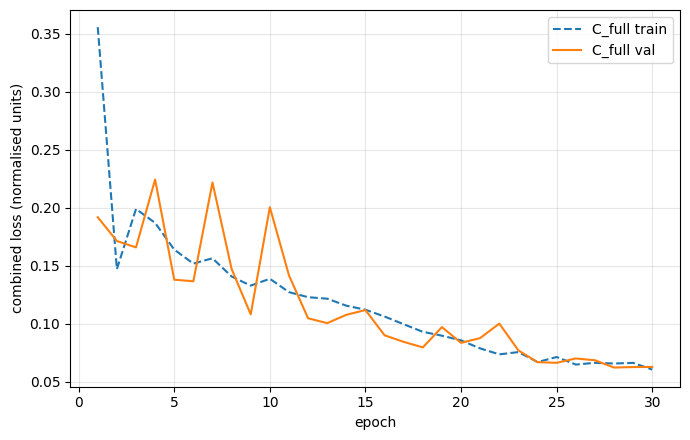

In [24]:
# =============================================================================
# 19. Train
# =============================================================================
HISTORIES = {}
for _variant in CFG["RUN_VARIANTS"]:
    HISTORIES[_variant] = train_variant(_variant,resume=True)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.5))
for v, h in HISTORIES.items():
    ax.plot(range(1, len(h["train_loss"]) + 1), h["train_loss"], "--", label=f"{v} train")
    ax.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], "-", label=f"{v} val")
ax.set_xlabel("epoch"); ax.set_ylabel("combined loss (normalised units)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{CFG['OUTPUT_DIR']}/gnn_loss_curves.png", dpi=140); plt.show()

In [25]:
from IPython.display import FileLink

# Generates a link to download the best model
display(FileLink(r'OceanEmbed_run/checkpoints/gnn_C_full_best.pt'))

# If you also want to download the last epoch's model:
display(FileLink(r'OceanEmbed_run/checkpoints/gnn_C_full_last.pt'))

/kaggle/working/OceanEmbed_run/checkpoints/gnn_C_full_best.pt

/kaggle/working/OceanEmbed_run/checkpoints/gnn_C_full_last.pt

In [26]:
import shutil
from IPython.display import FileLink

# Zip the entire checkpoints folder into a single file named 'all_models.zip'
shutil.make_archive('all_models', 'zip', 'OceanEmbed_run/checkpoints')

# Generate the download link
display(FileLink('all_models.zip'))

/kaggle/working/all_models.zip

## 20. Exhaustive-tile inference and evaluation (spec §8, §11)

`reconstruct_day()` tiles the full basin exhaustively (`STATE["origins_exh"]`, built in Section 7), runs the encoder per tile, and
**averages overlapping predictions with `tile_stitch_weights`** (core weight 1, halo weight ≈0) to produce one seamless full-basin
field — exactly the spec's inference-time procedure. Evaluation then mirrors your U-Net notebook: RMSE / correlation / bias overall,
per depth, and — new, per the spec's own risk note — **per sub-basin** (Arabian Sea vs. Bay of Bengal), plus the physics-loss
diagnostics (density-consistency and monotonicity-violation rate) and an independent check against INCOIS Gridded ARGO.

In [27]:
# =============================================================================
# 20. Exhaustive-tile reconstruction + evaluation
# =============================================================================
def reconstruct_day(model, e, use_skip):
    """Full-basin (D, H, W) reconstruction of temperature (and salinity, if the model has a live S head) for
    one day, via exhaustive overlapping tiling + weighted stitching (spec Sec. 8)."""
    origins = STATE["origins_exh"]
    accumT = np.zeros((D, H, W), dtype="float64")
    accumS = np.zeros((D, H, W), dtype="float64") if STATE.get("have_sal") else None
    wsum = np.zeros((D, H, W), dtype="float64")
    use_amp = bool(CFG.get("USE_AMP", torch.cuda.is_available())) and DEVICE.type == "cuda"
    model.eval()
    with torch.no_grad():
        for i0 in range(0, len(origins), CFG["EVAL_BATCH_TILES"]):
            batch_origins = origins[i0:i0 + CFG["EVAL_BATCH_TILES"]]
            day_tile_list = [(e, int(r0), int(c0)) for r0, c0 in batch_origins]
            g = build_tile_graph(day_tile_list, need_target=False)
            g = graph_to_device(g, DEVICE)
            with amp_autocast(use_amp):
                t_hat, s_hat = model(g, use_skip=use_skip)
            Tdeg = denormalise(t_hat.float().cpu().numpy(), STATE["tstats"])
            Sdeg = denormalise(s_hat.float().cpu().numpy(), STATE["sstats"]) if accumS is not None else None
            row = g.row_idx.cpu().numpy(); col = g.col_idx.cpu().numpy()
            depth = g.depth_idx.cpu().numpy(); bvec = g.batch.cpu().numpy()
            for bi, (r0, c0) in enumerate(batch_origins):
                m = bvec == bi
                if not m.any():
                    continue
                wt = tile_stitch_weights(int(r0), int(c0))
                w = wt[row[m] - r0, col[m] - c0]
                np.add.at(accumT, (depth[m], row[m], col[m]), Tdeg[m] * w)
                np.add.at(wsum, (depth[m], row[m], col[m]), w)
                if accumS is not None:
                    np.add.at(accumS, (depth[m], row[m], col[m]), Sdeg[m] * w)
    predT = np.where(wsum > 0, accumT / np.maximum(wsum, 1e-12), np.nan).astype("float32")
    predS = (np.where(wsum > 0, accumS / np.maximum(wsum, 1e-12), np.nan).astype("float32")
            if accumS is not None else None)
    return predT, predS


def load_best_model(variant):
    model = build_gnn_model().to(DEVICE)
    model.set_frozen_lookups(STATE["season_labels"])
    ck = load_gnn_checkpoint(f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_best.pt", model)
    print(f"[{variant}] loaded best checkpoint (epoch {ck['epoch']}, val_loss={ck['val_loss']:.5f}).")
    use_skip = variant in ("B_skip", "C_full")
    return model, use_skip


def evaluate_variant(variant, day_stride=None):
    day_stride = day_stride or CFG["EVAL_DAY_STRIDE"]
    model, use_skip = load_best_model(variant)
    ends = STATE["ends_test"][::day_stride]
    print(f"[{variant}] evaluating {len(ends)} test day(s) (stride {day_stride}) ...")

    PRED, TRUE, dates = [], [], []
    t0 = time.time()
    for i, e in enumerate(ends, 1):
        predT, _ = reconstruct_day(model, e, use_skip)
        trueT = denormalise(np.asarray(STATE["Y"][e, :, :H, :W], dtype="float32"), STATE["tstats"])
        predT[~np.isfinite(trueT)] = np.nan
        PRED.append(predT); TRUE.append(trueT); dates.append(str(STATE["times"][e]))
        if i % max(len(ends) // 10, 1) == 0 or i == len(ends):
            print(f"    {i}/{len(ends)} days reconstructed ({(time.time()-t0)/i:.1f}s/day)", flush=True)
    PRED, TRUE = np.stack(PRED), np.stack(TRUE)

    overall_m = metrics_per_depth(PRED, TRUE)
    df = pd.DataFrame({"depth_m": CFG["STANDARD_DEPTHS"].astype(int), "rmse_degC": overall_m["rmse"],
                       "correlation": overall_m["corr"], "bias_degC": overall_m["bias"]})
    print(f"\n[{variant}] Overall skill vs. depth:")
    print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    v = np.isfinite(PRED) & np.isfinite(TRUE)
    overall = {"rmse_degC": float(np.sqrt(np.mean((PRED[v] - TRUE[v]) ** 2))),
              "bias_degC": float(np.mean(PRED[v] - TRUE[v])),
              "mae_degC": float(np.mean(np.abs(PRED[v] - TRUE[v]))),
              "correlation": float(np.corrcoef(PRED[v], TRUE[v])[0, 1]), "n_valid_cells": int(v.sum())}
    print(f"[{variant}] Overall: {json.dumps(overall, indent=2)}")

    subbasin_rows = []
    for name, (lo, hi) in CFG["SUBBASINS"].items():
        lon_mask = (TARGET_LON >= lo) & (TARGET_LON < hi)
        sb = metrics_per_depth(PRED[:, :, :, lon_mask], TRUE[:, :, :, lon_mask])
        vv = np.isfinite(PRED[:, :, :, lon_mask]) & np.isfinite(TRUE[:, :, :, lon_mask])
        pv, tv = PRED[:, :, :, lon_mask][vv], TRUE[:, :, :, lon_mask][vv]
        subbasin_rows.append({"subbasin": name, "rmse_degC": float(np.sqrt(np.mean((pv - tv) ** 2))),
                              "bias_degC": float(np.mean(pv - tv)), "correlation": float(np.corrcoef(pv, tv)[0, 1])})
    sb_df = pd.DataFrame(subbasin_rows)
    print(f"\n[{variant}] Per sub-basin (spec Sec. 8/11 -- checks a single basin fit isn't masking a weak one):")
    print(sb_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    density = density_consistency_metrics(model, use_skip)
    argo_df = argo_validation(PRED, dates)

    os.makedirs(CFG["OUTPUT_DIR"], exist_ok=True)
    df.to_csv(f"{CFG['OUTPUT_DIR']}/gnn_{variant}_metrics_per_depth.csv", index=False)
    sb_df.to_csv(f"{CFG['OUTPUT_DIR']}/gnn_{variant}_metrics_subbasin.csv", index=False)
    json.dump({"overall": overall, "density": density}, open(f"{CFG['OUTPUT_DIR']}/gnn_{variant}_metrics_overall.json", "w"), indent=2)

    return {"variant": variant, "overall": overall, "per_depth": df, "per_subbasin": sb_df,
           "density": density, "argo": argo_df, "PRED": PRED, "TRUE": TRUE, "dates": dates}


def density_consistency_metrics(model, use_skip, day_stride=None):
    """mean |rho_hat - rho_true| and the monotonicity-violation rate (spec Sec. 9.3, 11 -- PGTransNet Sec. 3.6 style)."""
    if not (STATE.get("have_sal") and HAVE_GSW):
        print("Density-consistency check skipped (no salinity cache or gsw unavailable).")
        return None
    day_stride = day_stride or CFG["DENSITY_EVAL_DAY_STRIDE"]
    ends = STATE["ends_test"][::day_stride]
    p3 = np.broadcast_to(STATE["p_tab"].T[:, :, None], (D, H, W)).astype("float64")
    fac3 = np.transpose(STATE["sa_fac"], (2, 0, 1)).astype("float64")
    diffs, viol_rates = [], []
    for e in ends:
        predT, predS = reconstruct_day(model, e, use_skip)
        trueT = denormalise(np.asarray(STATE["Y"][e, :, :H, :W], dtype="float32"), STATE["tstats"])
        trueS = denormalise(np.asarray(STATE["S"][e], dtype="float32"), STATE["sstats"])
        valid = np.isfinite(predT) & np.isfinite(predS) & np.isfinite(trueT) & np.isfinite(trueS)
        if valid.sum() == 0:
            continue
        rho_h = np.full((D, H, W), np.nan); rho_t = np.full((D, H, W), np.nan)
        rho_h[valid] = gsw.rho_t_exact((predS.astype("float64") * fac3)[valid], predT.astype("float64")[valid], p3[valid])
        rho_t[valid] = gsw.rho_t_exact((trueS.astype("float64") * fac3)[valid], trueT.astype("float64")[valid], p3[valid])
        diffs.append(np.abs(rho_h - rho_t)[valid])
        dcons = rho_h[1:] - rho_h[:-1]
        vp = np.isfinite(dcons)
        if vp.sum() > 0:
            viol_rates.append(float(((dcons < 0) & vp).sum() / vp.sum()))
    if not diffs:
        print("Density-consistency check: no valid (T, S) overlap on the sampled test days.")
        return None
    all_diffs = np.concatenate(diffs)
    out = {"mean_abs_rho_diff_kg_m3": float(np.nanmean(all_diffs)),
          "mono_violation_rate_pct": float(100 * np.mean(viol_rates)) if viol_rates else None,
          "n_days": len(diffs)}
    print(f"Density-consistency over {out['n_days']} test day(s): "
          f"mean |rho_hat-rho_true| = {out['mean_abs_rho_diff_kg_m3']:.4f} kg/m^3, "
          f"monotonicity-violation rate = {out['mono_violation_rate_pct']:.2f}%")
    return out


def _regrid_and_crop_nd(da):
    """Like Section 5's regrid_and_crop, but keeps ANY leading dims (time and/or depth), not just 'time' --
    Section 5's own version only special-cases 'time' before lat/lon, so it drops a bare 'depth' dim on
    transpose (it was only ever exercised on (time, lat, lon) or (lat, lon) arrays there). Used here for
    Argo validation, which regrids (depth, lat, lon) monthly slices."""
    if da["lat"].values[0] > da["lat"].values[-1]:
        da = da.isel(lat=slice(None, None, -1))
    if da["lon"].values[0] > da["lon"].values[-1]:
        da = da.isel(lon=slice(None, None, -1))
    out = da.interp(lat=TARGET_LAT, lon=TARGET_LON, method="linear", kwargs={"fill_value": "extrapolate"})
    other = [d for d in out.dims if d not in ("lat", "lon")]
    return out.transpose(*other, "lat", "lon")


def argo_validation(pred_by_day, dates):
    """Independent check against INCOIS Gridded ARGO monthly fields (spec Sec. 11: 'the actual bar')."""
    try:
        argo_parts = load_argo_parts()
    except Exception as e:
        print("Could not open Gridded Argo for independent validation:", e)
        return None
    if not argo_parts:
        print("No Gridded Argo file found -> independent validation skipped.")
        return None
    argo = argo_parts[0] if len(argo_parts) == 1 else xr.concat(argo_parts, dim="time").sortby("time")
    if "depth" not in argo.dims:
        print(f"Gridded Argo has no depth dimension (dims={argo.dims}) -> independent validation skipped.")
        return None
    pred_months = np.asarray(pd.to_datetime(dates).values, dtype="datetime64[M]")
    argo_months = np.asarray(argo["time"].values, dtype="datetime64[M]")
    common = sorted(set(argo_months.tolist()) & set(pred_months.tolist()))
    if not common:
        print("No overlapping months with Gridded Argo -> independent validation skipped.")
        return None
    nd = np.asarray(argo["depth"].values, dtype="float64"); order = np.argsort(nd)
    lo, hi, w = _vertical_weights(nd[order], CFG["STANDARD_DEPTHS"])
    P_rows, A_rows = [], []
    for mth in common:
        pm = pred_months == mth
        if not pm.any():
            continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)   # all-NaN (land) pixels are expected here
            P_rows.append(np.nanmean(pred_by_day[pm], axis=0))
        sel = np.flatnonzero(argo_months == mth)
        sub = argo.isel(time=sel).mean("time") if len(sel) > 1 else argo.isel(time=sel[0])
        a = _regrid_and_crop_nd(sub).transpose("depth", "lat", "lon").values.astype("float32")[order]
        A_rows.append(a[lo] * (1 - w)[:, None, None] + a[hi] * w[:, None, None])
    if not P_rows:
        print("No evaluated day actually falls in an overlapping Argo month -> independent validation skipped.")
        return None
    P, Aarr = np.stack(P_rows), np.stack(A_rows)
    P[~np.isfinite(Aarr)] = np.nan
    m = metrics_per_depth(P, Aarr)
    df = pd.DataFrame({"depth_m": CFG["STANDARD_DEPTHS"].astype(int), "rmse_degC": m["rmse"],
                       "correlation": m["corr"], "bias_degC": m["bias"]})
    print(f"\nIndependent validation vs. INCOIS Gridded ARGO ({len(common)} overlapping month(s)):")
    print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return df

## 21. Run the evaluation (and the ablation comparison, if more than one variant was trained)

In [28]:
# import os
# import json
# import subprocess
# from kaggle_secrets import UserSecretsClient

# # 1. Authenticate using Kaggle Secrets
# try:
#     user_secrets = UserSecretsClient()
#     os.environ["KAGGLE_USERNAME"] = user_secrets.get_secret("KAGGLE_USERNAME")
#     os.environ["KAGGLE_KEY"] = user_secrets.get_secret("KAGGLE_KEY")
# except Exception as e:
#     raise RuntimeError("Ensure you have added KAGGLE_USERNAME and KAGGLE_KEY to Add-ons > Secrets.") from e

# # 2. Configuration
# # MUST be lowercase alphanumeric and dashes only, and unique to your account
# dataset_slug = "oceanembed-working-dir-backup" 
# dataset_title = "OceanEmbed Working Directory Backup"
# target_dir = "/kaggle/working"

# # 3. Initialize and configure dataset metadata
# print("Generating dataset metadata...")
# subprocess.run(["kaggle", "datasets", "init", "-p", target_dir], check=True)

# meta_path = os.path.join(target_dir, "dataset-metadata.json")
# with open(meta_path, "r") as f:
#     meta = json.load(f)

# meta["id"] = f"{os.environ['KAGGLE_USERNAME']}/{dataset_slug}"
# meta["title"] = dataset_title

# with open(meta_path, "w") as f:
#     json.dump(meta, f, indent=4)

# # 4. Upload the dataset
# print(f"Uploading {target_dir} to Kaggle Datasets...")
# result = subprocess.run(
#     ["kaggle", "datasets", "create", "-p", target_dir, "--dir-mode", "tar"], 
#     capture_output=True, text=True
# )

# if result.returncode == 0:
#     print("Dataset successfully uploaded!")
#     print(result.stdout)
# else:
#     print("Upload failed. Error output:")
#     print(result.stderr)

[C_full] loaded best checkpoint (epoch 28, val_loss=0.06216).
[C_full] evaluating 365 test day(s) (stride 1) ...
    36/365 days reconstructed (6.3s/day)
    72/365 days reconstructed (6.3s/day)
    108/365 days reconstructed (6.3s/day)
    144/365 days reconstructed (6.3s/day)
    180/365 days reconstructed (6.3s/day)
    216/365 days reconstructed (6.3s/day)
    252/365 days reconstructed (6.2s/day)
    288/365 days reconstructed (6.2s/day)
    324/365 days reconstructed (6.2s/day)
    360/365 days reconstructed (6.2s/day)
    365/365 days reconstructed (6.2s/day)

[C_full] Overall skill vs. depth:
 depth_m  rmse_degC  correlation  bias_degC
       0     0.9908       0.8438    -0.0431
       5     0.8971       0.8722    -0.0951
      10     0.8460       0.8669    -0.0865
      20     0.9162       0.8390    -0.1377
      30     0.9256       0.8419    -0.0452
      50     1.1754       0.7988    -0.1737
      75     1.2615       0.8302    -0.3547
     100     1.2278       0.8540    -0.1

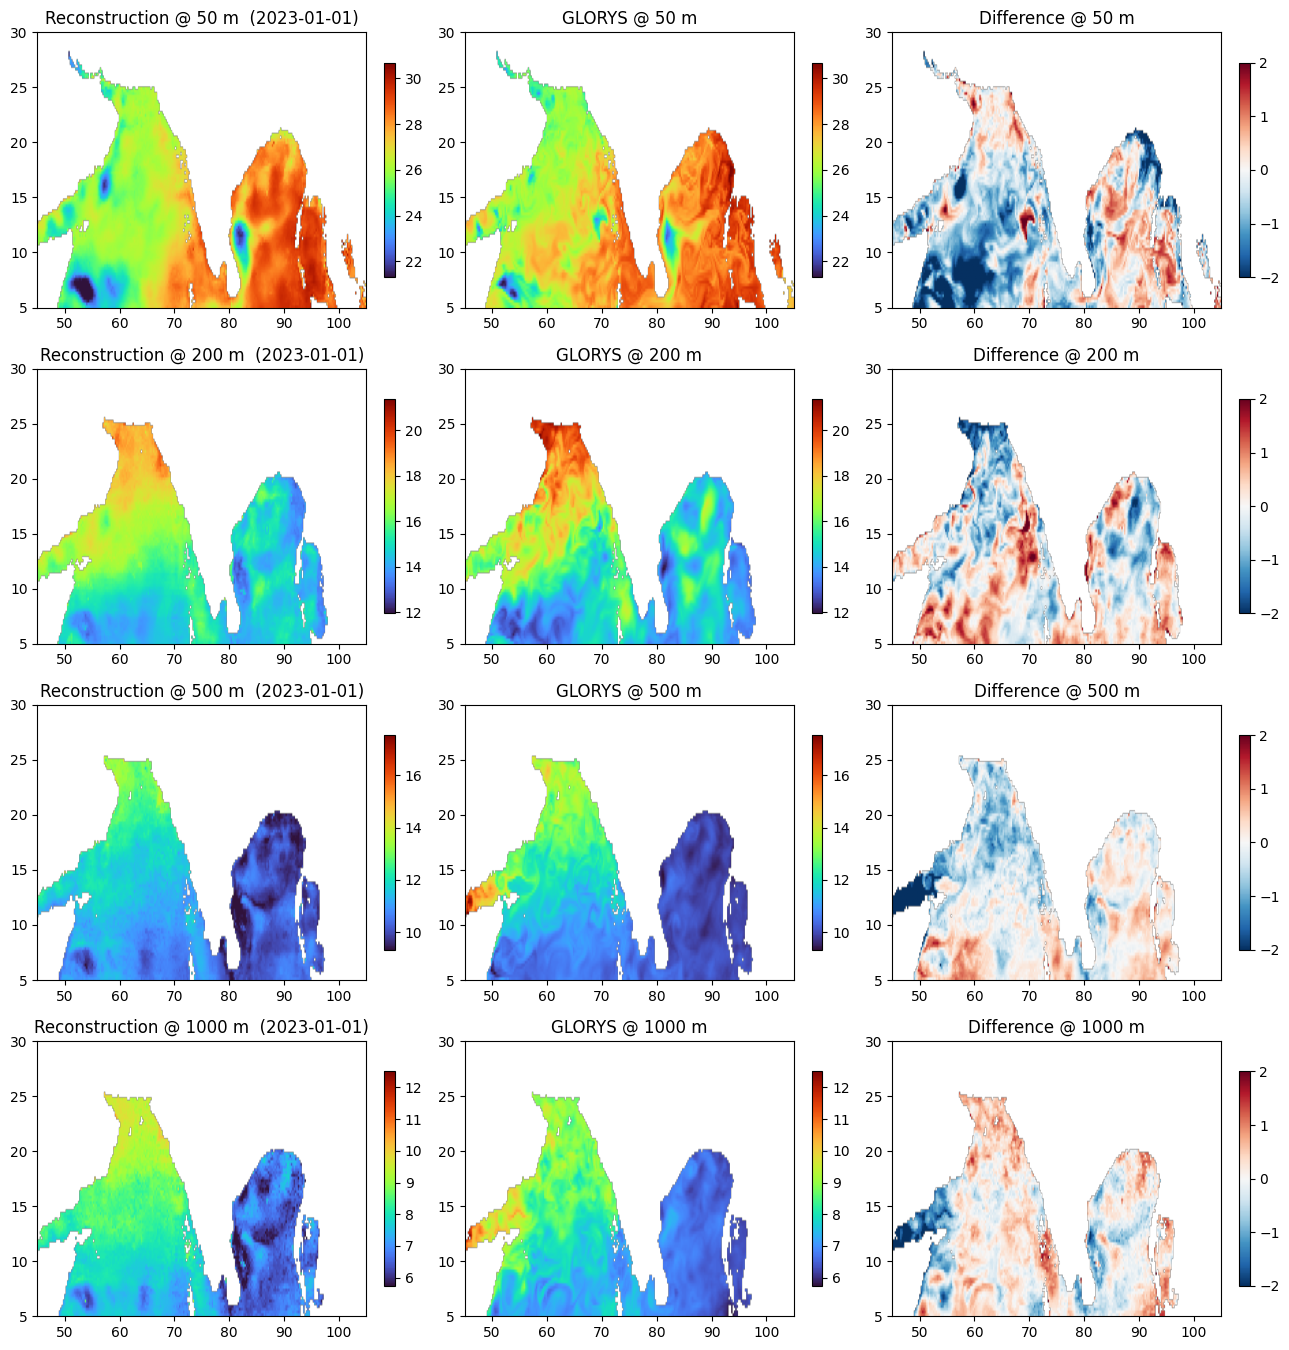

Wrote /kaggle/working/OceanEmbed_run/outputs/gnn_oam_reconstructed_temperature_test_period.nc


In [29]:
# =============================================================================
# 21. Evaluate every trained variant; compare if more than one was run (spec Sec. 11 ablation)
# =============================================================================
RESULTS = {}
for _variant in CFG["RUN_VARIANTS"]:
    RESULTS[_variant] = evaluate_variant(_variant)

if len(RESULTS) > 1:
    abl = pd.DataFrame([{"variant": v, "overall_RMSE_degC": r["overall"]["rmse_degC"],
                         "overall_correlation": r["overall"]["correlation"],
                         "overall_bias_degC": r["overall"]["bias_degC"],
                         "mean_abs_rho_diff": (r["density"] or {}).get("mean_abs_rho_diff_kg_m3")}
                        for v, r in RESULTS.items()])
    print("\n=== Ablation summary (spec Sec. 11: A_base -> B_skip -> C_full) ===")
    print(abl.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x is not None else "n/a"))
    abl.to_csv(f"{CFG['OUTPUT_DIR']}/ablation_summary.csv", index=False)

# --- spatial maps + NetCDF export for the LAST evaluated variant --------------------------------------
_last = list(RESULTS.values())[-1]
PRED, TRUE, dates = _last["PRED"], _last["TRUE"], _last["dates"]
EXTENT = [CFG["LON_MIN"], CFG["LON_MAX"], CFG["LAT_MIN"], CFG["LAT_MAX"]]


def _depth_idx(ds):
    return [int(np.argmin(np.abs(CFG["STANDARD_DEPTHS"] - d))) for d in ds]


def plot_gnn_maps(sample_idx=0, depths_to_plot=(50, 200, 500, 1000)):
    idx = _depth_idx(depths_to_plot)
    fig, axes = plt.subplots(len(idx), 3, figsize=(13, 3.4 * len(idx)), squeeze=False)
    for row, (di, d) in enumerate(zip(idx, depths_to_plot)):
        p, t = PRED[sample_idx, di], TRUE[sample_idx, di]
        vmin, vmax = np.nanmin(t), np.nanmax(t)
        for col, (field, title, kw) in enumerate((
                (p, "Reconstruction", dict(vmin=vmin, vmax=vmax, cmap="turbo")),
                (t, "GLORYS", dict(vmin=vmin, vmax=vmax, cmap="turbo")),
                (p - t, "Difference", dict(cmap="RdBu_r", vmin=-2, vmax=2)))):
            ax = axes[row][col]
            im = ax.imshow(field, origin="lower", extent=EXTENT, aspect="auto", **kw)
            ax.set_title(f"{title} @ {int(d)} m" + (f"  ({dates[sample_idx][:10]})" if col == 0 else ""))
            plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    plt.savefig(f"{CFG['OUTPUT_DIR']}/gnn_spatial_maps.png", dpi=140)
    plt.show()


plot_gnn_maps()

out_nc = f"{CFG['OUTPUT_DIR']}/gnn_oam_reconstructed_temperature_test_period.nc"
xr.DataArray(
    PRED, dims=["time", "depth", "lat", "lon"],
    coords={"time": pd.to_datetime([d[:10] for d in dates]), "depth": CFG["STANDARD_DEPTHS"],
           "lat": TARGET_LAT, "lon": TARGET_LON},
    name="reconstructed_temperature",
    attrs={"units": "degC", "long_name": "OceanEmbed-GNN-OAM reconstructed ocean temperature",
          "domain": "North Indian Ocean 5N-30N, 45E-105E", "resolution": "0.25 deg, daily",
          "variant": _last["variant"]},
).to_dataset().to_netcdf(out_nc)
print("Wrote", out_nc)

## 22. Verification: the SP→SA conversion factor is (to machine precision) linear in SP over this domain

Section 15 uses a single precomputed `sa_fac(lat, lon, depth)` and applies it as `SA ≈ SP · sa_fac`, rather than calling
`gsw.SA_from_SP` on every batch (which would need lon/lat/pressure broadcast through the training loop for no benefit). This is
exact only if `SA_from_SP` is linear in `SP` at fixed `(p, lon, lat)` — checked directly below, not assumed.

In [30]:
# =============================================================================
# 22. Verify SA_from_SP linearity in SP (justifies the precomputed sa_fac lookup used by the physics loss)
# =============================================================================
if HAVE_GSW:
    rng = np.random.default_rng(0)
    n_check = 2000
    lat_s = rng.uniform(CFG["LAT_MIN"], CFG["LAT_MAX"], n_check)
    lon_s = rng.uniform(CFG["LON_MIN"], CFG["LON_MAX"], n_check)
    p_s = rng.uniform(0, 1000, n_check)
    sp_s = rng.uniform(20, 40, n_check)
    sa_direct = np.asarray(gsw.SA_from_SP(sp_s, p_s, lon_s, lat_s))
    fac_s = np.asarray(gsw.SA_from_SP(np.full(n_check, 35.0), p_s, lon_s, lat_s)) / 35.0
    sa_via_fac = sp_s * fac_s
    max_err = float(np.max(np.abs(sa_direct - sa_via_fac)))
    print(f"SA_from_SP linearity check over {n_check} random (SP, p, lon, lat) points: "
         f"max |SA_direct - SP*factor| = {max_err:.2e} g/kg")
    assert max_err < 1e-8, "SA_from_SP is not linear in SP here -- the precomputed sa_fac lookup is invalid; " \
                           "switch gsw_density() to a direct gsw.SA_from_SP call per batch instead."
    print("Confirmed linear to machine precision -- the precomputed sa_fac lookup used in Section 15 is exact.")
else:
    print("gsw unavailable -- skipping (the physics-guided loss is already disabled in this session).")

SA_from_SP linearity check over 2000 random (SP, p, lon, lat) points: max |SA_direct - SP*factor| = 1.42e-14 g/kg
Confirmed linear to machine precision -- the precomputed sa_fac lookup used in Section 15 is exact.


## 23. Consolidated deviations and implementation choices

Every place this notebook's *implementation* had to resolve something the spec left open, beyond the ten deviations the spec
itself already lists from GNN-OAM/PGTransNet (spec §12, reproduced in Section 3's docstring-equivalent comments throughout).
Read this before treating a mismatch with the spec document as a bug.

| # | Choice | What / why | Section |
|---|---|---|---|
| 1 | RF regression target | Spec doesn't name it; here the forest regresses the full 15-depth temperature profile from window statistics of the 7 surface channels (mirrors GNN-OAM's own RF→GNN relationship) | 9 |
| 2 | RF cross-fitting | Not required by the spec but necessary in practice: without it, `z_col` on training days comes from a forest that has already seen those days' temperature, handing the GNN a leaked, near-perfect input feature. Fixed by `RF_N_FOLDS` time-blocked out-of-fold prediction with a `T_WINDOW`-day exclusion buffer | 9 |
| 3 | A^S depth pairing | PCC is a property of a *column*, so a literal reading of the spec links every depth pair of two similar columns (`SIM_DEPTH_PAIRING="all"`, the default); capped to `SIM_MAX_PARTNERS` per column purely as a memory guard (set to `None` for the fully literal, uncapped version) | 6, 11 |
| 4 | Edge-feature lookup | Eq. 7 says E_ij comes from "the same PCC values used to build A^S" — implemented as one raw (un-thresholded) column-PCC matrix per tile, reused for A^N, A^S and I edges alike, rather than three separate PCC computations | 11 |
| 5 | OAM computed as sparse scatter/gather | Algebraically identical to the literal per-edge Eq. 8-9 (Section 14 checks this to float32 precision) — only the implementation is different (edge-list sparse ops instead of a dense N×N attention matrix), for memory reasons the spec itself flags in Section 8 | 12, 13, 14 |
| 6 | Multi-head combination | GNN-OAM Eq. 9 averages the C heads; this implementation concatenates them before the FFC projection (standard multi-head-attention practice). FFC's learned weights can represent the paper's `(1/C)·Σ` as one of their solutions, so no function the formula can express is lost — just a different (weakly more expressive) parameterisation | 13 |
| 7 | `Loss_rho` gradient | `gsw` is NumPy-only; `GswRhoTExact` is a custom `torch.autograd.Function` whose backward pass is a central finite difference of the same `gsw.rho_t_exact` call (step 1e-3), checked against whole-loss finite differences in Section 15/14 | 15 |
| 8 | Practical→absolute salinity | `SA ≈ SP · sa_fac(lat, lon, depth)`, a factor pre-computed once (Section 7) rather than calling `gsw.SA_from_SP` every batch. Verified linear in SP to <1e-8 g/kg over this domain (Section 22) | 15, 22 |
| 9 | Potential vs. in-situ temperature | The spec's Eq. in §9.1 passes `T_hat`/`T_true` directly as `rho_t_exact`'s in-situ-temperature argument; GLORYS `thetao` is potential temperature. Implemented literally per the spec. The two differ by roughly 0.1-0.5°C at 1000 m in this basin — small relative to typical reconstruction RMSE, but a caveat worth stating in a write-up: a stricter implementation would convert with `gsw.pt_from_t`'s inverse before calling the density function |9|
| 10 | Depth meta-graph | `DEPTH_PCC_MODE="raw"` (literal spec: PCC of the *pooled* temperature field) is the default; `"anomaly"` (PCC of each column's temporal anomaly, removing the mean seasonal cycle first) is offered as an alternative that some spectral-clustering practitioners would consider more standard, and is worth comparing if the discovered depth clusters look driven by the mean vertical profile rather than by co-variability | 8 |
| 11 | Tiling vs. full-basin graph | Required by the spec itself (§8); `TILE_SIZE=12` with `HALO=2` gives ≈2,160 nodes/tile, inside GNN-OAM's own validated 1,000-4,000 node range | 7, 10 |
| 12 | Cluster-count override | `K_OVERRIDE`/`M_OVERRIDE` let you force a specific cluster count instead of the eigengap choice, for direct comparison against a hand-specified oceanographic banding if your write-up wants that ablation | 8 |

### Practical notes
* **Session timeouts.** Every long step is independently resumable: `build_finetune_cache` / `build_salinity_cache` (chunk-level), `build_rf_z_cache` (day-level), and `train_variant` (epoch-level, per-variant checkpoints under `CFG["CHECKPOINT_DIR"]`). Re-running Sections 16-19 after a restart picks up where it left off.
* **No salinity files found.** `C_full` silently trains as `B_skip` (data-only + cluster skip) instead of failing — check the Section 6b / 17 log lines. Add GLORYS `so` files to any path in `CFG["DATA_ROOT_CANDIDATES"]` and re-run Sections 6b, 16 and 17 to enable the physics loss.
* **Out of memory.** Lower `CFG["BATCH_TILES"]` first (cheapest), then `CFG["TILE_SIZE"]` (fewer nodes/tile), then `CFG["SIM_MAX_PARTNERS"]` (fewer A^S edges) — in that order, since batch size costs nothing in fidelity while tile size and similarity edges are the two places this implementation already trades exactness for memory (deviations #3, #11).
* **Comparing against the U-Net.** Both notebooks share the exact same `finetune_x.npy`/`finetune_y.npy` cache, the same year split, and `metrics_per_depth` definition, so `gnn_C_full_metrics_per_depth.csv` here and `metrics_per_depth.csv` from the U-Net notebook are directly comparable RMSE-for-RMSE.
* **RF-only baseline** (Section 9, `rf_only_baseline()`) is worth quoting alongside the full GNN-OAM result in a write-up: it is the skill you get from surface-window statistics alone, with no graph attention or physics loss at all, and is the honest floor the rest of the architecture has to beat.

## 24. Fine-tuning on 2024 data — discovery

**No, the notebook above stops at the 2023 test year — it does not fine-tune on 2024.** Everything from here down is new: it
discovers the 2024 files, builds an independent cache for them (reusing the *frozen* 2016–2023 normalisation, RF forests and
cluster tables — nothing upstream is retrained), and fine-tunes an already-trained checkpoint on 2024 at a reduced learning rate.

**Three structural realities of your actual dataset, all handled below, not assumed:**
1. Every surface variable's 2024 file (`SST_2024.nc`, `SSS_2024 (1).nc`, `SSH_2024.nc`, `OSCAR_currents_2024.nc`,
  `ERA5_winds_2024.nc`) sits **in the same folder** as the 2016–2023 file(s) for that variable — but for `sss` specifically,
  your Section 3 cell already contains a line that deliberately drops the 2024 file from the training-time list. Section 24
  does its **own** independent file scan for the 2024 files, so that exclusion — correct for 2016–2023 training — is bypassed
  here without touching Section 3.
2. **`GLORYS 2024` is one file covering every depth** (`..._5.08-1062.44m_2024-01-01-2024-12-31.nc`), not the one-file-per-depth
  layout `glorys_parts()` expects. A dedicated reader (`glorys2024_parts` / `load_glorys_2024_days`) opens that one file and
  slices its native depth levels, then reuses the exact same `load_days` + `_vertical_weights` machinery as the 2016–2023
  reader for spatial regridding and vertical interpolation to the 15 standard depths.
3. **A `Spare Data Files`-style folder contains decoys that overlap real years by name** — e.g. a `..._2016_2024.nc` SSH file
  and a combined-currents file with no year at all. `_is_2024_only_file()` requires `2024` to appear as a standalone year
  token *and* none of 2016–2023 to also appear, so a decoy naming its full covered range is correctly rejected even though a
  plain `"2024" in filename` check would have accepted it. `CFG["SCAN_EXCLUDE"]` in the Configuration cell also now excludes
  that folder outright, which protects Section 3's *original* discovery from the same decoys.

**A related, more fundamental fix lives in Section 3b, not here**: because your Kaggle input mount is static for the whole
session, `GLORYS 2024` is visible from the very first cell, not just once you reach this section — so without a fix, Section
3's classifier would sweep it into `glorys_temp` and corrupt the *original* 2016–2023 training, long before this cell ever
runs. Section 3b now removes any file with more than one native depth level from `glorys_temp` generically (not by year or
filename), so `GLORYS 2024` — or any future combined multi-level export — never reaches the one-file-per-depth reader at all;
this cell's own `glorys2024_parts()` finds it independently.

**Performance note.** GLORYS salinity now arrives split across five differently-named folders (a multi-part Drive-zip export),
and combined with everything else in the dataset that's a lot more filesystem to walk than before. Section 3b introduced a
**shared, one-time file scan** (`_all_data_files()`) that both that cell and this one reuse — the previous version of this
cell scanned the whole dataset once per surface channel (8 separate full walks), which is what made it look stuck on a larger
dataset. This version scans once, total, across the whole notebook.

**No 2024 salinity was provided** (`GLORYS 2024` contains temperature only), so the physics-guided loss has no 2024 target and
is **disabled for this fine-tuning stage** regardless of which variant you fine-tune — `C_full` fine-tunes with plain masked-MSE
+ its cluster skip, i.e. the same loss `B_skip` used. This is stated again where it matters (Section 27) so it isn't missed.

In [31]:
# =============================================================================
# 24. Discover the 2024 files (surface variables + the single multi-depth GLORYS 2024 file)
# =============================================================================
FT2024_CUTOFF = np.datetime64("2024-01-01")
_LEGACY_YEARS = tuple(range(2016, 2024))     # any of these appearing in a filename marks it NOT 2024-only


def _is_2024_only_file(path):
    """True if '2024' appears as a standalone year token in the basename and none of 2016-2023 do --
    guards against decoy multi-year files (e.g. 'duacs_ssh_sla_..._2016_2024.nc' under a 'Spare Data
    Files'-style folder) that would otherwise match a plain '2024' substring search just as well as
    the real dedicated file."""
    base = os.path.basename(path)
    if not re.search(r'(?<!\d)2024(?!\d)', base):
        return False
    return not any(re.search(rf'(?<!\d){y}(?!\d)', base) for y in _LEGACY_YEARS)


def variable_parts_2024(key):
    """Independent 2024-only file scan for a surface channel -- deliberately bypasses any exclusion
    filter Section 3 applied to CFG['RAW_PATHS'][key] (e.g. the 'sss' -> smap-combined-only filter),
    since that filter is correct for 2016-2023 training and wrong here. Reuses the shared, one-time
    file scan from Section 3b instead of walking the filesystem again."""
    cache_key = f"{key}__2024"
    if cache_key in _PARTS_CACHE:
        return _PARTS_CACHE[cache_key]
    hit_keys = dict(_CLASSIFY_RULES).get(key)
    matches = [f for f in _all_data_files()
              if hit_keys and any(s in f.lower() for s in hit_keys) and _is_2024_only_file(f)]
    if not matches:          # current_v / wind_v aren't their own classify-rule keys -- fall back to
        matches = [f for f in CFG["RAW_PATHS"].get(key, []) if _is_2024_only_file(f)]
    if not matches:
        raise FileNotFoundError(f"No 2024-only file found for '{key}' (looked for a standalone '2024' "
                                f"year token, with none of 2016-2023 also present, under "
                                f"CFG['DATA_ROOT_CANDIDATES']). Confirm the file was added to the Kaggle "
                                f"dataset/input, not just to Drive.")
    if len(matches) > 1:
        print(f"  NOTE: [{key}] matched more than one 2024-only file -- using all of them: "
             f"{[os.path.basename(m) for m in matches]}. If that's wrong, narrow CFG['RAW_PATHS'] "
             f"or this cell's matching by hand.")
    parts = []
    for p in matches:
        da = _open_one(p, key)
        days = np.asarray(da["time"].values, dtype="datetime64[D]")
        parts.append((da, days))
    _PARTS_CACHE[cache_key] = parts
    print(f"[{key}] 2024 file(s): {[os.path.basename(p) for p in matches]}  "
         f"({parts[0][1][0]} .. {parts[0][1][-1]})")
    return parts


def load_surface_channel_mixed(key, days):
    """(len(days), H, W) float32 + n_imputed, sourcing days < 2024-01-01 from the ORIGINAL discovery
    (unchanged) and days >= 2024-01-01 from the independent 2024 scan above."""
    days = np.asarray(days, dtype="datetime64[D]")
    legacy = days < FT2024_CUTOFF
    out = np.empty((len(days), CFG["NATIVE_H"], CFG["NATIVE_W"]), dtype="float32")
    n_imp = 0
    if legacy.any():
        a, ni = load_days(variable_parts(key), days[legacy], impute=True, label=f"{key}(legacy)")
        out[legacy] = a
        n_imp += ni
    if (~legacy).any():
        a, ni = load_days(variable_parts_2024(key), days[~legacy], impute=True, label=f"{key}(2024)")
        out[~legacy] = a
        n_imp += ni
    return out, n_imp


def glorys2024_parts():
    """[(native_depth_m, DataArray, day_index), ...] from the ONE multi-depth 2024 GLORYS file --
    same return contract as Section 5's glorys_parts(), built from one file's depth dimension
    instead of one file per depth."""
    if "parts2024" in _GLORYS_CACHE:
        return _GLORYS_CACHE["parts2024"]
    matches = [f for f in _all_data_files()
              if _is_2024_only_file(f) and any(s in f.lower() for s in ("glorys", "thetao", "cmems_mod_glo"))]
    if not matches:
        raise FileNotFoundError("No 2024-only GLORYS temperature file found under CFG['DATA_ROOT_CANDIDATES'] "
                               "(looked for 'glorys'/'thetao'/'cmems_mod_glo' + a standalone '2024' year "
                               "token, with 2016-2023 absent, in the filename).")
    path = sorted(matches)[0]
    ds = xr.open_dataset(path, chunks={}, decode_times=True)
    names = set(ds.variables) | set(ds.dims)
    meta = dict(CFG["VAR_NAMES"]["glorys_temp"])          # copy: this file's internal names may differ slightly
    for axis, cands in (("lat", _LAT_CANDS), ("lon", _LON_CANDS), ("time", _TIME_CANDS)):
        if meta.get(axis) not in names:
            got = _pick(names, cands)
            if got:
                meta[axis] = got
    if meta.get("depth") not in names:
        got = _pick(names, _DEPTH_CANDS)
        if got:
            meta["depth"] = got
    if meta["var"] not in ds.data_vars:
        got = _pick(list(ds.data_vars), _VAR_HINTS["glorys_temp"])
        if got is None and len(ds.data_vars) == 1:
            got = list(ds.data_vars)[0]
        if got:
            meta["var"] = got
    ds = _normalise_names(ds, meta)
    dkey = meta.get("depth", "depth")
    if dkey not in ds.variables:
        raise ValueError(f"No depth dimension found in {os.path.basename(path)} (dims={dict(ds.sizes)}). "
                         f"Edit CFG['VAR_NAMES']['glorys_temp'] or this cell's dkey resolution.")
    depth_vals = np.asarray(ds[dkey].values, dtype="float64")
    print(f"GLORYS 2024 ({os.path.basename(path)}): var='{meta['var']}', {len(depth_vals)} native depth "
         f"level(s), {depth_vals.min():.2f}-{depth_vals.max():.2f} m")
    if depth_vals.min() > CFG["STANDARD_DEPTHS"].min():
        print(f"  NOTE: shallowest native level ({depth_vals.min():.2f} m) is deeper than the shallowest "
             f"standard depth ({CFG['STANDARD_DEPTHS'].min():.0f} m) -- that standard depth will be "
             f"clamped to the shallowest native level, same convention as Section 5.")
    parts = []
    for k, dz in enumerate(depth_vals):
        da_k = ds[meta["var"]].isel({dkey: k}, drop=True)
        da_k = _flatten_extra_dims(da_k)
        da_k = da_k.transpose(*[d for d in ("time", "lat", "lon") if d in da_k.dims])
        dayidx = np.asarray(da_k["time"].values, dtype="datetime64[D]")
        parts.append((float(dz), da_k, dayidx))
    parts.sort(key=lambda t: t[0])
    ds.close()
    _GLORYS_CACHE["parts2024"] = parts
    return parts


def load_glorys_2024_days(days):
    """(len(days), 15, NATIVE_H, NATIVE_W) float32 -- literal twin of Section 5's load_glorys_days,
    sourced from glorys2024_parts() instead of glorys_parts()."""
    parts = glorys2024_parts()
    nd = [p[0] for p in parts]
    T = len(days)
    stack = np.empty((T, len(parts), CFG["NATIVE_H"], CFG["NATIVE_W"]), dtype="float32")
    for i, (_, da, dayidx) in enumerate(parts):
        arr, _ = load_days([(da, dayidx)], days, impute=True, label=f"glorys2024@{nd[i]}m")
        stack[:, i] = arr
    lo, hi, w = _vertical_weights(nd, CFG["STANDARD_DEPTHS"])
    out = stack[:, lo] * (1.0 - w)[None, :, None, None] + stack[:, hi] * w[None, :, None, None]
    return out.astype("float32")


def load_glorys_days_mixed(days):
    """(len(days), 15, NATIVE_H, NATIVE_W) float32, splitting at the 2024 boundary and routing each
    side to its own reader; used for the small pre-2024 warm-up buffer (Section 25) as well as the
    2024 days themselves."""
    days = np.asarray(days, dtype="datetime64[D]")
    legacy = days < FT2024_CUTOFF
    out = np.empty((len(days), CFG["N_DEPTHS"], CFG["NATIVE_H"], CFG["NATIVE_W"]), dtype="float32")
    if legacy.any():
        out[legacy] = load_glorys_days(days[legacy])
    if (~legacy).any():
        out[~legacy] = load_glorys_2024_days(days[~legacy])
    return out


# Sanity pass: touch every source once so problems surface here, not mid-cache-build.
for _k in CFG["CHANNEL_ORDER"]:
    variable_parts_2024(_k)
glorys2024_parts()
print("2024 discovery OK. (No 2024 salinity was provided -> the physics-guided loss stays OFF for fine-tuning.)")

[sst] 2024 file(s): ['SST_2024.nc']  (2024-01-01 .. 2024-12-31)
[sss] 2024 file(s): ['SSS_2024 (1).nc']  (2024-01-01 .. 2024-03-10)
[adt] 2024 file(s): ['SSH_2024.nc']  (2024-01-01 .. 2024-12-31)
[current_u] 2024 file(s): ['OSCAR_currents_2024.nc']  (2024-01-01 .. 2024-12-31)
[current_v] 2024 file(s): ['OSCAR_currents_2024.nc']  (2024-01-01 .. 2024-12-31)
[wind_u] 2024 file(s): ['ERA5_winds_2024.nc']  (2024-01-01 .. 2024-12-31)
[wind_v] 2024 file(s): ['ERA5_winds_2024.nc']  (2024-01-01 .. 2024-12-31)
GLORYS 2024 (cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao_45.00E-105.00E_5.00N-30.00N_5.08-1062.44m_2024-01-01-2024-12-31.nc): var='thetao', 32 native depth level(s), 5.08-1062.44 m
  NOTE: shallowest native level (5.08 m) is deeper than the shallowest standard depth (0 m) -- that standard depth will be clamped to the shallowest native level, same convention as Section 5.
2024 discovery OK. (No 2024 salinity was provided -> the physics-guided loss stays OFF for fine-tuning.)


## 25. Build the 2024 fine-tune cache

A new, independent cache (`finetune2024_x.npy` / `finetune2024_y.npy`) — **not merged into the original `finetune_x/y.npy`**,
so nothing about the original 2016–2023 cache changes. It reuses the **frozen mean/std/min-max from the original cache's
`input_stats`/`target_stats`** (never recomputed on 2024), because the pretrained model's weights only make sense against the
normalisation they were trained on. A `T_WINDOW - 1`-day warm-up buffer immediately before 2024-01-01 is included (read from
the *original* 2016–2023 sources) purely so the very first days of 2024 have a full surface-history window for the RF module
and the A^S similarity graph — those buffer days are never used as prediction targets (Section 27 restricts training/eval to
`year == 2024`).

In [32]:
# =============================================================================
# 25. Build the 2024 fine-tune cache (X, Y only -- no salinity cache; reuses ORIGINAL normalisation)
# =============================================================================
FT2024_STAGE = "finetune2024"
FT2024_WARMUP_DAYS = CFG["T_WINDOW"] - 1


def ft2024_master_days():
    start = FT2024_CUTOFF - np.timedelta64(FT2024_WARMUP_DAYS, "D")
    end = np.datetime64("2024-12-31")
    # clip 'end' to whatever the 2024 GLORYS file actually covers, in case it's a partial year
    avail = np.unique(np.concatenate([d for _, _, d in glorys2024_parts()]))
    end = min(end, avail.max())
    return np.arange(start, end + np.timedelta64(1, "D"), dtype="datetime64[D]")


def build_finetune2024_cache(overwrite=False):
    master = ft2024_master_days()
    N = len(master)
    orig_meta = json.load(open(cache_paths("finetune")["meta"]))
    stats, tstats = orig_meta["input_stats"], orig_meta["target_stats"]
    print(f"2024 master axis: {N} days ({master[0]} .. {master[-1]}), "
         f"of which {int((master >= FT2024_CUTOFF).sum())} are actual 2024 target-eligible days "
         f"and {FT2024_WARMUP_DAYS} are pre-2024 warm-up context.")

    itemsize = np.dtype(CFG["CACHE_DTYPE"]).itemsize
    est = N * (CFG["N_CHANNELS"] + CFG["N_DEPTHS"]) * CFG["PAD_H"] * CFG["PAD_W"] * itemsize
    root = ensure_cache_root(est)
    P = cache_paths(FT2024_STAGE, root)

    meta = None
    if os.path.exists(P["meta"]) and not overwrite:
        meta = json.load(open(P["meta"]))
        if meta.get("n") == N and meta.get("done") == len(meta["chunks"]):
            print(f"2024 fine-tune cache already complete ({N} days) -- skipping.")
            return meta
        print(f"Found an INCOMPLETE 2024 cache ({meta.get('done')}/{len(meta.get('chunks', []))} chunks) "
             f"-- resuming.")

    chunks = _chunk_bounds(N, CFG["PREPROCESS_CHUNK_DAYS"])
    if meta is None or meta.get("n") != N:
        meta = {"stage": FT2024_STAGE, "n": N, "dtype": CFG["CACHE_DTYPE"], "chunks": chunks, "done": 0,
                "channels": CFG["CHANNEL_ORDER"] + (["land_mask"] if CFG["USE_LAND_MASK_CHANNEL"] else []),
                "depths": CFG["STANDARD_DEPTHS"].tolist(), "pad_h": CFG["PAD_H"], "pad_w": CFG["PAD_W"],
                "input_stats": stats, "target_stats": tstats, "imputed": {k: 0 for k in CFG["CHANNEL_ORDER"]},
                "reused_normalisation_from": "finetune (2016-2023)"}
        mode = "w+"
    else:
        mode = "r+"

    np.save(P["t"], master)
    Xc = np.lib.format.open_memmap(P["x"], mode=mode, dtype=CFG["CACHE_DTYPE"],
                                   shape=(N, CFG["N_CHANNELS"], CFG["PAD_H"], CFG["PAD_W"]))
    Yc = np.lib.format.open_memmap(P["y"], mode=mode, dtype=CFG["CACHE_DTYPE"],
                                   shape=(N, CFG["N_DEPTHS"], CFG["PAD_H"], CFG["PAD_W"]))
    LAND = build_land_sea_mask()
    print(f"Writing 2024 cache: X {Xc.shape} + Y {Yc.shape} = {_human(est)} of {CFG['CACHE_DTYPE']}")

    t0 = time.time()
    for ci in range(meta["done"], len(chunks)):
        i0, i1 = chunks[ci]
        days = master[i0:i1]
        for c, k in enumerate(CFG["CHANNEL_ORDER"]):
            a, n_imp = load_surface_channel_mixed(k, days)
            meta["imputed"][k] += int(n_imp)
            z = normalise(a, stats[k])
            fv = fill_value(stats[k])
            z = np.nan_to_num(z, nan=fv, posinf=fv, neginf=fv)
            Xc[i0:i1, c] = pad_spatial(z).astype(CFG["CACHE_DTYPE"])
            del a, z
        if CFG["USE_LAND_MASK_CHANNEL"]:
            Xc[i0:i1, len(CFG["CHANNEL_ORDER"])] = LAND.astype(CFG["CACHE_DTYPE"])[None]
        g = load_glorys_days_mixed(days)
        Yc[i0:i1] = pad_spatial(normalise(g, tstats)).astype(CFG["CACHE_DTYPE"])
        del g

        meta["done"] = ci + 1
        Xc.flush(); Yc.flush()
        json.dump(meta, open(P["meta"], "w"), indent=2)
        el = time.time() - t0
        print(f"  2024 chunk {ci+1}/{len(chunks)}  {days[0]}..{days[-1]}  ({el/60:.1f} min elapsed)", flush=True)

    del Xc, Yc
    print("2024 fine-tune cache complete ->", root)
    return meta


FT2024_META = build_finetune2024_cache()

2024 master axis: 395 days (2023-12-03 .. 2024-12-31), of which 366 are actual 2024 target-eligible days and 29 are pre-2024 warm-up context.
2024 fine-tune cache already complete (395 days) -- skipping.


## 26. Swap `STATE` onto the 2024 cache, and build its `z_col` (RF) cache

`STATE` is a plain dict that every training/graph/evaluation function (`build_tile_graph`, `run_gnn_epoch`, `reconstruct_day`,
...) reads as a **global**, so pointing the whole pipeline at 2024 is a matter of rebinding the name `STATE` to a new dict —
nothing about those functions' code changes. `STATE_2024` is built as a **shallow copy of the original `STATE`** (so the ocean
mask, tile geometry, `gsw` pressure/salinity-factor tables, and the frozen `depth_cluster`/`season_regime`/`K`/`M` lookups are
all reused unchanged — they are properties of the domain and the calendar, not of any particular year) with only the
day-indexed fields replaced. `STATE_ORIGINAL` is kept so Section 29 can restore it.

`z_col` for 2024 is produced by the **existing, unmodified `build_rf_z_cache`** — the *frozen* RF forests fitted on 2016–2023
are applied to 2024's surface-window features exactly as they already are to the 2022/2023 validation/test days (averaged
across the `RF_N_FOLDS` forests, since no 2024 day was in any forest's training fold; see Section 9). Only the **output path**
differs, redirected via a temporary rebind of `z_cache_paths` so it cannot collide with the original `gnn_z.npy`.

In [33]:
# =============================================================================
# 26. STATE_2024 (shares domain/calendar-invariant fields with STATE; day-indexed fields point at 2024)
# =============================================================================
STATE_ORIGINAL = STATE   # keep the 2016-2023 STATE so Section 29 can restore it

ft = cache_paths(FT2024_STAGE)
ft_meta = json.load(open(ft["meta"]))
if ft_meta.get("done") != len(ft_meta["chunks"]):
    raise RuntimeError("2024 fine-tune cache is incomplete -- re-run Section 25 (it resumes).")
times2024 = np.load(ft["t"])
N2024 = len(times2024)
X2024 = np.load(ft["x"], mmap_mode="r")
Y2024 = np.load(ft["y"], mmap_mode="r")

dti2024 = pd.DatetimeIndex(times2024.astype("datetime64[ns]"))
year_of_2024 = dti2024.year.values
doy_of_2024 = dti2024.dayofyear.values
ok_end_2024 = valid_window_ends(times2024, T_WIN)
ends_all_2024 = np.flatnonzero(ok_end_2024)
actual2024 = np.flatnonzero(year_of_2024 == 2024)          # excludes the pre-2024 warm-up buffer
ends_actual = np.intersect1d(ends_all_2024, actual2024)
if len(ends_actual) == 0:
    raise RuntimeError("No valid T_WINDOW-day window falls inside an actual 2024 day -- check the cache.")

# --- month-block split within 2024, with an automatic fallback if less than a full year is available ---
train_end = CFG.get("FT2024_TRAIN_END", np.datetime64("2024-10-31"))
val_end = CFG.get("FT2024_VAL_END", np.datetime64("2024-11-30"))
last_actual = times2024[actual2024].max()
if last_actual >= val_end:
    ft_train_days = actual2024[times2024[actual2024] <= train_end]
    ft_val_days = actual2024[(times2024[actual2024] > train_end) & (times2024[actual2024] <= val_end)]
    ft_test_days = actual2024[times2024[actual2024] > val_end]
    split_desc = f"date cutoffs (train <= {train_end}, val <= {val_end}, test after)"
else:
    a, b = int(len(actual2024) * 0.70), int(len(actual2024) * 0.85)
    ft_train_days, ft_val_days, ft_test_days = actual2024[:a], actual2024[a:b], actual2024[b:]
    split_desc = f"70/15/15 fraction (only {last_actual} of 2024 available so far)"
ends_ft_train = np.intersect1d(ends_actual, ft_train_days)
ends_ft_val = np.intersect1d(ends_actual, ft_val_days)
ends_ft_test = np.intersect1d(ends_actual, ft_test_days)
for nm, arr in (("fine-tune train", ends_ft_train), ("fine-tune val", ends_ft_val), ("fine-tune test", ends_ft_test)):
    if len(arr) == 0:
        raise RuntimeError(f"No valid windows in the {nm} split ({split_desc}) -- widen the range or add more 2024 days.")
print(f"2024 split ({split_desc}): train {len(ends_ft_train)} | val {len(ends_ft_val)} | test {len(ends_ft_test)} windows")

STATE_2024 = dict(STATE_ORIGINAL)             # reuse everything domain/calendar-invariant...
STATE_2024.update(dict(                       # ...override everything day-indexed
    N=N2024, times=times2024, X=X2024, Y=Y2024, meta=ft_meta,
    year_of=year_of_2024, doy_of=doy_of_2024, ok_end=ok_end_2024, ends_all=ends_all_2024,
    train_days=ft_train_days, val_days=ft_val_days, test_days=ft_test_days,
    ends_train=ends_ft_train, ends_val=ends_ft_val, ends_test=ends_ft_test,
    tstats=ft_meta["target_stats"], istats=ft_meta["input_stats"],
    have_sal=False,
))
STATE_2024.pop("S", None)
STATE_2024.pop("sstats", None)
STATE_2024.pop("Zmm", None)                   # force a fresh (2024) z_col memmap to be loaded below

STATE = STATE_2024   # <-- from here down, every existing function (build_tile_graph, run_gnn_epoch, ...) sees 2024

_z_cache_paths_original = z_cache_paths


def z_cache_paths_2024(root=None):
    root = root or ensure_cache_root()
    return {"z": f"{root}/gnn_z_2024.npy", "meta": f"{root}/gnn_z_2024_meta.json"}


z_cache_paths = z_cache_paths_2024
try:
    FOLD_OF_END_2024 = np.full(STATE["N"], -1, dtype="int64")   # no 2024 day was in any RF training fold
    Z2024_META = build_rf_z_cache(RF_MODELS, FOLD_OF_END_2024, overwrite=False)
finally:
    z_cache_paths = _z_cache_paths_original

STATE["Zmm"] = np.load(z_cache_paths_2024()["z"], mmap_mode="r")   # pre-populate: build_tile_graph then skips its own load
print("STATE now points at the 2024 cache. RF forests and cluster tables are the frozen 2016-2023 ones (unchanged).")

2024 split (date cutoffs (train <= 2024-10-31, val <= 2024-11-30, test after)): train 305 | val 30 | test 31 windows
RF z_col cache already complete -- skipping.
STATE now points at the 2024 cache. RF forests and cluster tables are the frozen 2016-2023 ones (unchanged).


## 27. Fine-tune on 2024

Loads an already-trained checkpoint and continues training it — same architecture, same optimizer type, but a **lower learning
rate** (`FT_LR`, default a 10th of `CFG["LR"]`) and few epochs (`FT_EPOCHS`), which is the standard recipe for adapting a
converged model to a new period without washing out what it already learned. The loss is **plain masked-MSE on temperature +
the cluster skip** for every variant, `C_full` included — there is no 2024 salinity target, so the physics-guided terms are
switched off here regardless of which checkpoint you fine-tune (Section 24). Checkpoints save under a **new name**
(`gnn_<variant>_finetuned2024_best.pt` / `..._last.pt`), so the original 2016–2023 checkpoint is never overwritten.

In [34]:
# =============================================================================
# 27. Fine-tune (masked-MSE + cluster skip only -- no physics term, no 2024 salinity)
# =============================================================================
FT_VARIANTS = CFG.get("RUN_VARIANTS_FINETUNE", CFG["RUN_VARIANTS"])
FT_LR = CFG.get("FT_LR", CFG["LR"] * 0.1)
FT_EPOCHS = CFG.get("FT_EPOCHS", 5)
FT_STEPS_PER_EPOCH = CFG.get("FT_STEPS_PER_EPOCH", CFG["STEPS_PER_EPOCH"])
FT_MAX_HOURS = CFG.get("FT_MAX_TRAIN_HOURS", CFG["MAX_TRAIN_HOURS"])

_ft_loss_fn = PhysicsGuidedLoss(DEPTH_WEIGHTS.to(DEVICE), CFG["LAMBDAS"], CFG["LAMBDA_MONO"], use_physics=False)


def make_tile_loaders_2024():
    tr = TrainTileDataset("train", FT_STEPS_PER_EPOCH * CFG["BATCH_TILES"], seed=CFG["SEED"] + 2024)
    va_fixed = make_fixed_tiles("val", CFG["VAL_TILES"], seed=CFG["SEED"] + 2025)
    va = TrainTileDataset("val", 0, fixed=va_fixed)
    tr_loader = DataLoader(tr, batch_size=CFG["BATCH_TILES"], shuffle=True, num_workers=0, collate_fn=collate_train)
    va_loader = DataLoader(va, batch_size=CFG["EVAL_BATCH_TILES"], shuffle=False, num_workers=0, collate_fn=collate_train)
    print(f"2024 fine-tune: {FT_STEPS_PER_EPOCH} steps/epoch x {CFG['BATCH_TILES']} tiles | "
         f"val: {len(va_fixed)} fixed tiles ({len(va_loader)} batches)")
    return tr_loader, va_loader


def finetune_variant_2024(variant, resume=True):
    use_skip = variant in ("B_skip", "C_full")
    if variant == "C_full":
        print(f"[{variant}] fine-tuning WITHOUT the physics term (no 2024 salinity) -- "
             f"effectively the same loss as B_skip for this stage only.")

    model = build_gnn_model().to(DEVICE)
    model.set_frozen_lookups(STATE["season_labels"])   # unchanged: frozen 2016-2023 lookup, reused as-is
    src_path = f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_best.pt"
    if not os.path.exists(src_path):
        raise FileNotFoundError(f"No trained checkpoint at {src_path} -- train '{variant}' (Section 19) first.")
    ck = load_gnn_checkpoint(src_path, model)
    print(f"[{variant}] loaded pretrained checkpoint (epoch {ck['epoch']}, 2016-2023 val_loss={ck['val_loss']:.5f}).")

    optimizer = torch.optim.AdamW(model.parameters(), lr=FT_LR, weight_decay=CFG["WEIGHT_DECAY"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(FT_EPOCHS, 1))
    scaler = make_scaler(bool(CFG.get("USE_AMP", torch.cuda.is_available())) and DEVICE.type == "cuda")
    stopper = EarlyStopping(patience=CFG["EARLY_STOP_PATIENCE"])
    history = {"train_loss": [], "val_loss": []}
    start_epoch = 1

    last_path = f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_finetuned2024_last.pt"
    best_path = f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_finetuned2024_best.pt"
    if resume and os.path.exists(last_path):
        ck2 = load_gnn_checkpoint(last_path, model, optimizer)
        start_epoch = int(ck2.get("epoch", 0)) + 1
        history = ck2.get("history") or history
        stopper.best = float(ck2.get("best", float("inf")))
        for _ in range(start_epoch - 1):
            scheduler.step()
        print(f"[{variant}] resuming fine-tune from epoch {start_epoch} (best 2024-val {stopper.best:.5f}).")

    tr_loader, va_loader = make_tile_loaders_2024()
    deadline = time.time() + FT_MAX_HOURS * 3600
    print(f"=== [{variant}] fine-tuning on 2024, {DEVICE} ===", flush=True)

    for epoch in range(start_epoch, FT_EPOCHS + 1):
        t0 = time.time()
        tr = run_gnn_epoch(model, tr_loader, _ft_loss_fn, use_skip, 1.0, optimizer, scaler,
                           tag=f"{variant} ft e{epoch} train", deadline=deadline)
        va = run_gnn_epoch(model, va_loader, _ft_loss_fn, use_skip, 1.0, tag=f"{variant} ft e{epoch} val")
        scheduler.step()
        history["train_loss"].append(tr["loss_total"]); history["val_loss"].append(va["loss_total"])
        is_best = stopper.step(va["loss_total"])
        print(f"[{variant}] ft epoch {epoch}/{FT_EPOCHS} train={tr['loss_total']:.5f} val={va['loss_total']:.5f} "
             f"lr={scheduler.get_last_lr()[0]:.2e} {time.time()-t0:.0f}s" + ("  <- new best" if is_best else ""),
             flush=True)
        save_gnn_checkpoint(last_path, model, optimizer, epoch, va["loss_total"], history, stopper.best)
        if is_best:
            save_gnn_checkpoint(best_path, model, optimizer, epoch, va["loss_total"], history, stopper.best)
        if time.time() > deadline:
            print(f"[{variant}] fine-tune wall-clock budget reached -- stopping. Re-run to resume.")
            break
        if stopper.should_stop:
            print(f"[{variant}] fine-tune early stopping at epoch {epoch}.")
            break
    print(f"=== [{variant}] fine-tuning done. best 2024-val {stopper.best:.5f} -> {best_path} ===")
    return history


FT_HISTORIES = {}
for _variant in FT_VARIANTS:
    FT_HISTORIES[_variant] = finetune_variant_2024(_variant)

[C_full] fine-tuning WITHOUT the physics term (no 2024 salinity) -- effectively the same loss as B_skip for this stage only.
[C_full] loaded pretrained checkpoint (epoch 28, 2016-2023 val_loss=0.06216).
[C_full] resuming fine-tune from epoch 6 (best 2024-val 0.00088).
2024 fine-tune: 1000 steps/epoch x 6 tiles | val: 1500 fixed tiles (125 batches)
=== [C_full] fine-tuning on 2024, cuda ===
=== [C_full] fine-tuning done. best 2024-val 0.00088 -> /kaggle/working/OceanEmbed_run/checkpoints/gnn_C_full_finetuned2024_best.pt ===


/tmp/ipykernel_58/4289262670.py:53: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


## 28. Evaluate the fine-tuned model on held-out 2024 days

Same exhaustive-tile reconstruction and stitching as Section 20 (`reconstruct_day`, unchanged), applied to the fine-tune test
split (Section 26) with `STATE` still pointing at 2024.

In [40]:
# =============================================================================
# 28. Evaluate on the 2024 fine-tune test split
# =============================================================================
def evaluate_finetuned_2024(variant, day_stride=None):
    day_stride = day_stride or CFG["EVAL_DAY_STRIDE"]
    use_skip = variant in ("B_skip", "C_full")
    model = build_gnn_model().to(DEVICE)
    model.set_frozen_lookups(STATE["season_labels"])
    ck = load_gnn_checkpoint(f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_finetuned2024_best.pt", model)
    print(f"[{variant}] loaded fine-tuned checkpoint (epoch {ck['epoch']}, val_loss={ck['val_loss']:.5f}).")

    ends = STATE["ends_test"][::day_stride]
    print(f"[{variant}] evaluating {len(ends)} held-out 2024 day(s) (stride {day_stride}) ...")
    PRED, TRUE = [], []
    t0 = time.time()
    for i, e in enumerate(ends, 1):
        predT, _ = reconstruct_day(model, e, use_skip)
        trueT = denormalise(np.asarray(STATE["Y"][e, :, :H, :W], dtype="float32"), STATE["tstats"])
        predT[~np.isfinite(trueT)] = np.nan
        PRED.append(predT); TRUE.append(trueT)
        if i % max(len(ends) // 10, 1) == 0 or i == len(ends):
            print(f"    {i}/{len(ends)} days reconstructed ({(time.time()-t0)/i:.1f}s/day)", flush=True)
    PRED, TRUE = np.stack(PRED), np.stack(TRUE)

    m = metrics_per_depth(PRED, TRUE)
    df = pd.DataFrame({"depth_m": CFG["STANDARD_DEPTHS"].astype(int), "rmse_degC": m["rmse"],
                       "correlation": m["corr"], "bias_degC": m["bias"]})
    print(f"\n[{variant}] 2024 held-out skill vs. depth:")
    print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    v = np.isfinite(PRED) & np.isfinite(TRUE)
    overall = {"rmse_degC": float(np.sqrt(np.mean((PRED[v] - TRUE[v]) ** 2))),
              "bias_degC": float(np.mean(PRED[v] - TRUE[v])),
              "correlation": float(np.corrcoef(PRED[v], TRUE[v])[0, 1]), "n_valid_cells": int(v.sum())}
    print(f"[{variant}] 2024 overall: {json.dumps(overall, indent=2)}")

    os.makedirs(CFG["OUTPUT_DIR"], exist_ok=True)
    df.to_csv(f"{CFG['OUTPUT_DIR']}/gnn_{variant}_finetuned2024_metrics_per_depth.csv", index=False)
    json.dump(overall, open(f"{CFG['OUTPUT_DIR']}/gnn_{variant}_finetuned2024_metrics_overall.json", "w"), indent=2)
    return {"variant": variant, "overall": overall, "per_depth": df, "PRED": PRED, "TRUE": TRUE}


FT_RESULTS = {v: evaluate_finetuned_2024(v) for v in FT_VARIANTS}

if len(FT_RESULTS) > 1:
    abl = pd.DataFrame([{"variant": v, "rmse_degC": r["overall"]["rmse_degC"],
                         "correlation": r["overall"]["correlation"], "bias_degC": r["overall"]["bias_degC"]}
                        for v, r in FT_RESULTS.items()])
    print("\n=== 2024 fine-tune comparison ===")
    print(abl.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    abl.to_csv(f"{CFG['OUTPUT_DIR']}/finetune2024_comparison.csv", index=False)


# Extract the 2024 predictions from your evaluation dictionary
# (IMPORTANT: Change 'FT_RESULTS' below if you named your dictionary something else!)
_last_2024 = list(FT_RESULTS.values())[-1]
PRED = _last_2024["PRED"]
TRUE = _last_2024["TRUE"]


[C_full] loaded fine-tuned checkpoint (epoch 5, val_loss=0.00088).
[C_full] evaluating 31 held-out 2024 day(s) (stride 1) ...
    3/31 days reconstructed (6.0s/day)
    6/31 days reconstructed (6.2s/day)
    9/31 days reconstructed (6.2s/day)
    12/31 days reconstructed (6.1s/day)
    15/31 days reconstructed (6.1s/day)
    18/31 days reconstructed (6.1s/day)
    21/31 days reconstructed (6.2s/day)
    24/31 days reconstructed (6.2s/day)
    27/31 days reconstructed (6.2s/day)
    30/31 days reconstructed (6.2s/day)
    31/31 days reconstructed (6.2s/day)

[C_full] 2024 held-out skill vs. depth:
 depth_m  rmse_degC  correlation  bias_degC
       0     0.5090       0.9465     0.1183
       5     0.5196       0.9443     0.1424
      10     0.5155       0.9428     0.2350
      20     0.5255       0.9208    -0.0036
      30     0.6866       0.8835     0.2574
      50     1.0429       0.7924    -0.0105
      75     1.5719       0.7631    -0.1567
     100     1.7705       0.7084    -0.2438


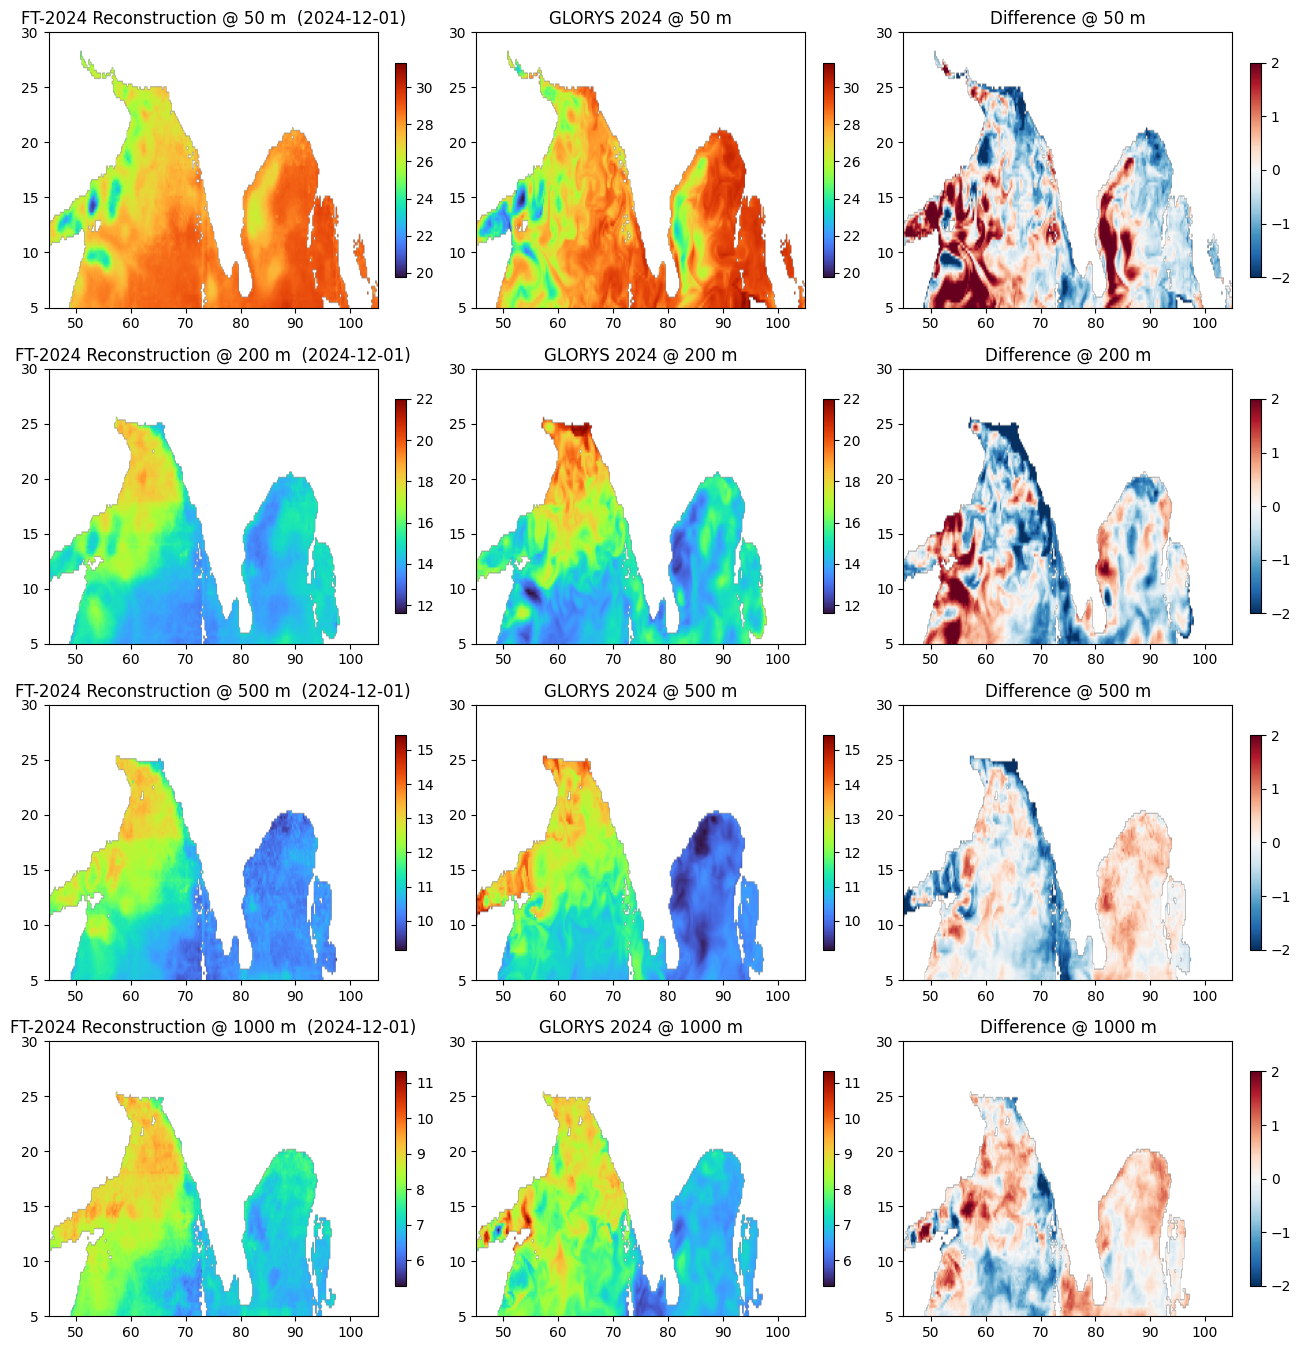

Wrote fine-tuned outputs to: /kaggle/working/OceanEmbed_run/outputs/gnn_oam_reconstructed_temperature_2024_test_period.nc


In [43]:
# =============================================================================
# 28. Spatial maps + NetCDF export for the 2024 Fine-Tuned Model
# =============================================================================

# EXTENT remains the same as your pre-training configuration
EXTENT = [CFG["LON_MIN"], CFG["LON_MAX"], CFG["LAT_MIN"], CFG["LAT_MAX"]]

# Extract the date strings for the 2024 test days evaluated in the previous cell
# Extract the date strings for the 2024 test days evaluated in the previous cell
ends = STATE["ends_test"][::CFG["EVAL_DAY_STRIDE"]]
dates_2024 = np.datetime_as_string(STATE["times"][ends], unit='D')

def _depth_idx(ds):
    return [int(np.argmin(np.abs(CFG["STANDARD_DEPTHS"] - d))) for d in ds]

def plot_ft2024_maps(sample_idx=0, depths_to_plot=(50, 200, 500, 1000)):
    idx = _depth_idx(depths_to_plot)
    fig, axes = plt.subplots(len(idx), 3, figsize=(13, 3.4 * len(idx)), squeeze=False)
    
    for row, (di, d) in enumerate(zip(idx, depths_to_plot)):
        # PRED and TRUE come from the 2024 evaluation loop above
        p, t = PRED[sample_idx, di], TRUE[sample_idx, di]
        vmin, vmax = np.nanmin(t), np.nanmax(t)
        
        for col, (field, title, kw) in enumerate((
                (p, "FT-2024 Reconstruction", dict(vmin=vmin, vmax=vmax, cmap="turbo")),
                (t, "GLORYS 2024", dict(vmin=vmin, vmax=vmax, cmap="turbo")),
                (p - t, "Difference", dict(cmap="RdBu_r", vmin=-2, vmax=2)))):
            ax = axes[row][col]
            im = ax.imshow(field, origin="lower", extent=EXTENT, aspect="auto", **kw)
            ax.set_title(f"{title} @ {int(d)} m" + (f"  ({dates_2024[sample_idx]})" if col == 0 else ""))
            plt.colorbar(im, ax=ax, fraction=0.03)
            
    plt.tight_layout()
    plt.savefig(f"{CFG['OUTPUT_DIR']}/gnn_ft2024_spatial_maps.png", dpi=140)
    plt.show()

# Plot the maps for the first evaluated 2024 test day
plot_ft2024_maps(sample_idx=0)



# Export to NetCDF
# Extract the predictions from your 2024 results dictionary and name it PRED_2024
_last_2024 = list(FT_RESULTS.values())[-1]
PRED_2024 = _last_2024["PRED"]

# Now export to NetCDF
out_nc = f"{CFG['OUTPUT_DIR']}/gnn_oam_reconstructed_temperature_2024_test_period.nc"
xr.DataArray(
    PRED_2024, dims=["time", "depth", "lat", "lon"], # <-- This will now work perfectly
    coords={"time": pd.to_datetime(dates_2024), "depth": CFG["STANDARD_DEPTHS"],
# ... rest of your code ...
           "lat": TARGET_LAT, "lon": TARGET_LON},
    name="reconstructed_temperature",
    attrs={"units": "degC", "long_name": "OceanEmbed-GNN-OAM Finetuned reconstructed ocean temperature",
          "domain": "North Indian Ocean 5N-30N, 45E-105E", "resolution": "0.25 deg, daily",
          "variant": f"{_variant}_finetuned2024"},
).to_dataset().to_netcdf(out_nc)
print("Wrote fine-tuned outputs to:", out_nc)

## 29. Restore `STATE`, and what to check before trusting these numbers

`STATE` is switched back to the original 2016–2023 object so anything you run afterward (re-opening Sections 16-21, say) behaves
exactly as it did before this appendix. `STATE_2024` and `STATE_ORIGINAL` both stay in memory if you need to compare the two
directly (e.g. `STATE_2024["ends_test"]`).

**Before reporting the fine-tuned numbers, worth checking:**
1. **No 2024 salinity → no physics loss here.** If your write-up compares `C_full`'s 2016–2023 test skill against its 2024
  fine-tuned skill, note the loss changed too, not just the data period — some of any change in RMSE reflects that, not only
  the distribution shift into 2024. Fine-tuning on a plain masked-MSE objective can also let `Loss_rho`-consistent behaviour
  the physics term encouraged during original training drift slightly over the fine-tuning epochs, since nothing is anchoring
  it anymore; Section 20's density-consistency check (rerun with `STATE = STATE_2024`, `density_consistency_metrics(model,
  use_skip)`) will not run without salinity, but a spot check of vertical monotonicity in `reconstruct_day`'s output costs one
  extra loop and catches this if you want the reassurance.
2. **The warm-up buffer is real 2016–2023 data, not synthetic padding** — Section 26's split already excludes it from every
  train/val/test set, so this is a non-issue for the numbers, only flagged here so it isn't mistaken for a bug if you inspect
  `STATE_2024["times"]` and see dates before 2024-01-01 at the front.
3. **`FT_LR`/`FT_EPOCHS` are a starting point, not a tuned choice.** If 2024 skill barely moves from the un-fine-tuned
  checkpoint's 2024 zero-shot skill (worth computing once for comparison: `evaluate_finetuned_2024` reads a
  `..._finetuned2024_best.pt` checkpoint, so pointing `load_gnn_checkpoint` at `..._best.pt` instead for one run gives that
  zero-shot baseline for free), the learning rate may be too low or too few epochs were run; if it moves a lot in the wrong
  direction, it's usually too high a learning rate for a short fine-tune.
4. **Kaggle dataset freshness.** All of this assumes the Kaggle input path already contains the 2024 files found on Drive
  today (`SST_2024.nc`, `SSS_2024.nc`, `SSH_2024.nc`, `OSCAR_currents_2024.nc`, `ERA5_winds_2024.nc`, and the `GLORYS 2024`
  folder's single multi-depth file). If Section 24's discovery cell raises `FileNotFoundError`, the Kaggle dataset version
  likely needs updating from Drive before re-running.

In [44]:
# =============================================================================
# 29. Restore STATE to the original 2016-2023 pipeline
# =============================================================================
STATE = STATE_ORIGINAL
print("STATE restored to the original 2016-2023 pipeline. STATE_2024 remains available for inspection.")

STATE restored to the original 2016-2023 pipeline. STATE_2024 remains available for inspection.


In [45]:
import glob
import re

# =============================================================================
# 29. Generate Heatmaps tracking Model Progression Across All Epochs
# =============================================================================

def plot_epoch_progression(variant="C_full", sample_day_idx=0, depths_to_plot=(50, 200, 500, 1000), is_finetuned=False):
    """
    Loads the model for each saved epoch, predicts the temperature for a single test day, 
    and saves the heatmaps to show the model's progression over time.
    """
    # Pick a specific day to evaluate across all epochs (ensures an apples-to-apples comparison)
    e = STATE["ends_test"][sample_day_idx]
    date_str = np.datetime_as_string(STATE["times"][e], unit='D')
    
    print(f"Generating epoch progression maps for {variant} on {date_str}...")
    
    # Define the pattern to find the epoch checkpoints
    if is_finetuned:
        checkpoint_pattern = f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_finetuned2024_epoch_*.pt"
    else:
        checkpoint_pattern = f"{CFG['CHECKPOINT_DIR']}/gnn_{variant}_epoch_*.pt"
        
    epoch_files = glob.glob(checkpoint_pattern)
    
    # Helper to extract the epoch number from the filename so we can sort them correctly (1, 2, ..., 10)
    def extract_epoch(filepath):
        match = re.search(r'_epoch_(\d+)\.pt', filepath)
        return int(match.group(1)) if match else -1
            
    epoch_files = sorted([f for f in epoch_files if extract_epoch(f) != -1], key=extract_epoch)
    
    if not epoch_files:
        print(f"No epoch checkpoints found matching: {checkpoint_pattern}")
        return
        
    EXTENT = [CFG["LON_MIN"], CFG["LON_MAX"], CFG["LAT_MIN"], CFG["LAT_MAX"]]
    idx = _depth_idx(depths_to_plot)
    use_skip = variant in ("B_skip", "C_full")
    
    # The true GLORYS target field is constant for this specific day
    trueT = denormalise(np.asarray(STATE["Y"][e, :, :CFG["NATIVE_H"], :CFG["NATIVE_W"]], dtype="float32"), STATE["tstats"])
    
    for ckpt_path in epoch_files:
        epoch_num = extract_epoch(ckpt_path)
        
        # 1. Load the model from this specific epoch
        model = build_gnn_model().to(DEVICE)
        model.set_frozen_lookups(STATE["season_labels"])
        ck = load_gnn_checkpoint(ckpt_path, model)
        model.eval()
        
        # 2. Reconstruct the day
        predT, _ = reconstruct_day(model, e, use_skip)
        predT[~np.isfinite(trueT)] = np.nan
        
        # 3. Plot
        fig, axes = plt.subplots(len(idx), 3, figsize=(13, 3.4 * len(idx)), squeeze=False)
        fig.suptitle(f"Epoch {epoch_num} - {variant} | Date: {date_str}", fontsize=16, y=1.02)
        
        for row, (di, d) in enumerate(zip(idx, depths_to_plot)):
            p, t = predT[di], trueT[di]
            vmin, vmax = np.nanmin(t), np.nanmax(t)
            
            for col, (field, title, kw) in enumerate((
                    (p, f"Reconstruction (Ep {epoch_num})", dict(vmin=vmin, vmax=vmax, cmap="turbo")),
                    (t, "GLORYS Target", dict(vmin=vmin, vmax=vmax, cmap="turbo")),
                    (p - t, "Difference", dict(cmap="RdBu_r", vmin=-2, vmax=2)))):
                
                ax = axes[row][col]
                im = ax.imshow(field, origin="lower", extent=EXTENT, aspect="auto", **kw)
                ax.set_title(f"{title} @ {int(d)} m")
                plt.colorbar(im, ax=ax, fraction=0.03)
                
        plt.tight_layout()
        
        # Save the figure to disk and close it to free up memory (prevents Kaggle from crashing)
        suffix = "ft2024" if is_finetuned else "pretrain"
        out_img = f"{CFG['OUTPUT_DIR']}/heatmap_progression_{variant}_{suffix}_ep{epoch_num:03d}.png"
        plt.savefig(out_img, dpi=120, bbox_inches='tight')
        plt.close(fig) 
        print(f"Saved: {out_img}")

# Run for the pre-training epochs (2016-2023)
for var in CFG["RUN_VARIANTS"]:
    plot_epoch_progression(variant=var, sample_day_idx=0, is_finetuned=False)

# Optional: Uncomment below if you also want to generate progression maps for your 2024 fine-tuning epochs
# for var in CFG["RUN_VARIANTS"]:
#     plot_epoch_progression(variant=var, sample_day_idx=0, is_finetuned=True)

print("All epoch heatmaps generated! Check your output directory.")

Generating epoch progression maps for C_full on 2023-01-01...
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep001.png
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep002.png
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep003.png
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep004.png
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep005.png
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep006.png
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep007.png
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep008.png
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep009.png
Saved: /kaggle/working/OceanEmbed_run/outputs/heatmap_progression_C_full_pretrain_ep010.png
Saved: /kaggle/wor

# VALIDATION ON 2025

In [ ]:
# =============================================================================
# 31. Independent validation: fine-tuned model vs. real ARGO floats (2025)
# =============================================================================
# Section 29 restored STATE to the original 2016-2023 pipeline -- point it back at the 2025 cache
# built in Sections 24-26. If this raises, re-run Section 26 first (it's resumable/idempotent).
if "STATE_2025" not in globals():
    raise RuntimeError("STATE_2025 isn't in memory (kernel restarted?). Re-run Sections 24-26 to "
                       "rebuild the 2025 cache and its z_col cache before this cell.")
STATE = STATE_2025

VALIDATE_VARIANT = "C_full"   # the variant you fine-tuned
use_skip = VALIDATE_VARIANT in ("B_skip", "C_full")

model = build_gnn_model().to(DEVICE)
model.set_frozen_lookups(STATE["season_labels"])
ck_path = f"{CFG['CHECKPOINT_DIR']}/gnn_{VALIDATE_VARIANT}_finetuned2025_best.pt"
if not os.path.exists(ck_path):
    raise FileNotFoundError(f"No fine-tuned checkpoint at {ck_path} -- run Section 27 for "
                            f"'{VALIDATE_VARIANT}' first.")
ck = load_gnn_checkpoint(ck_path, model)
print(f"[{VALIDATE_VARIANT}] loaded FINE-TUNED checkpoint (epoch {ck['epoch']}, "
     f"2025 val_loss={ck['val_loss']:.5f}).")

# --- find out which 2025 months the REAL Argo file actually covers, before reconstructing anything ---
# (the file also has 2025 entries -- we deliberately never touch those, since we have no 2025 inputs)
argo_parts = load_argo_parts()
if not argo_parts:
    raise FileNotFoundError("No real Argo file discovered under CFG['RAW_PATHS']['argo_temp'] -- confirm "
                            "'incois_argo_validation_2yr_claude_convertedfromcsv.nc' is on the Kaggle "
                            "input path (Validation folder) and re-run Section 3's discovery if needed.")
argo_all = argo_parts[0] if len(argo_parts) == 1 else xr.concat(argo_parts, dim="time").sortby("time")
argo_time = pd.to_datetime(argo_all["time"].values)
argo_2025_months = sorted(set(argo_time[argo_time.year == 2025].to_period("M")))
print(f"Real Argo file covers {len(argo_2025_months)} month(s) in 2025: {[str(m) for m in argo_2025_months]}")
if not argo_2025_months:
    raise RuntimeError("The Argo file has no 2025-dated entries -- nothing to validate against.")

# --- reconstruct model predictions only for the days that actually fall in those months -----------------
DAY_STRIDE_2025_ARGO = 1   # 1 = every day in the matching months; raise to 2-3 for a faster, coarser check
actual_2025 = np.union1d(STATE["ends_train"], np.union1d(STATE["ends_val"], STATE["ends_test"]))
day_months = pd.PeriodIndex(pd.to_datetime(STATE["times"][actual_2025]), freq="M")
needed = actual_2025[np.isin(day_months, argo_2025_months)][::DAY_STRIDE_2025_ARGO]
print(f"Reconstructing predictions for {len(needed)} model day(s) across those months ...")

PRED2025, dates2025 = [], []
t0 = time.time()
for i, e in enumerate(needed, 1):
    predT, _ = reconstruct_day(model, e, use_skip)
    PRED2025.append(predT)
    dates2025.append(str(STATE["times"][e]))
    if i % max(len(needed) // 10, 1) == 0 or i == len(needed):
        print(f"    {i}/{len(needed)} days reconstructed ({(time.time()-t0)/i:.1f}s/day)", flush=True)
PRED2025 = np.stack(PRED2025)
print(f"Done in {(time.time()-t0)/60:.1f} min.")

In [ ]:
# =============================================================================
# 31b. Compute the metrics and save them
# =============================================================================
argo_df_2025 = argo_validation(PRED2025, dates2025)   # reuses your existing, already-fixed function unchanged

if argo_df_2025 is not None:
    os.makedirs(CFG["OUTPUT_DIR"], exist_ok=True)
    out_path = f"{CFG['OUTPUT_DIR']}/{VALIDATE_VARIANT}_argo2025_independent_validation.csv"
    argo_df_2025.to_csv(out_path, index=False)
    print(f"\nSaved per-depth results -> {out_path}")

    print(f"\nMean across depths: RMSE {argo_df_2025['rmse_degC'].mean():.3f} degC | "
         f"correlation {argo_df_2025['correlation'].mean():.3f} | "
         f"bias {argo_df_2025['bias_degC'].mean():+.3f} degC")

    print("\nNote: 2025 was also used to fine-tune this checkpoint, so this number is expected to look "
         "somewhat better than true out-of-sample skill would -- it's a sanity check against real floats, "
         "not a clean held-out test. A genuinely independent check would need 2025 surface inputs, which "
         "aren't available yet (only SST_2025.nc exists; SSS/SSH/currents/winds/GLORYS for 2025 are missing).")
else:
    print("No overlapping (day, month) between reconstructed predictions and the real Argo file -- nothing to report.")


Independent validation vs. INCOIS Gridded ARGO (12 overlapping month(s)):
 depth_m  rmse_degC  correlation  bias_degC
       0     1.5653       0.4552     0.8136
       5     1.5748       0.4497     0.8220
      10     1.5705       0.4898     0.8828
      20     1.5333       0.5111     0.8976
      30     1.3894       0.6707     0.9265
      50     1.2171       0.7217     0.6517
      75     1.3791       0.6253     0.5048
     100     1.7458       0.5996     0.9450
     125     1.6024       0.6500     0.8611
     150     1.3621       0.7036     0.5801
     200     0.9256       0.8204     0.3472
     300     0.6258       0.8720     0.2136
     500     0.6426       0.8205     0.3432
     700     0.6722       0.8019     0.3207
    1000     0.6755       0.7775     0.4181

Saved per-depth results -> /kaggle/working/OceanEmbed_run/outputs/C_full_argo2024_independent_validation.csv

Mean across depths: RMSE 1.232 degC | correlation 0.665 | bias +0.635 degC

Note: 2024 was also used to fine-t

# Exporting Zip File for Prototype 

In [ ]:
# =============================================================================
# 30. Export for the OceanEmbed dashboard  (paste as the LAST cell of OceanEmbed-GNN-OAM-FULL.ipynb)
# =============================================================================
# Before running this cell, run Sections 1-17 (setup, caches, RF/XGBoost stage, cluster tables).
# For EXPORT_PERIOD = "2025" also run Sections 24-26 (2025 cache + its z_col cache).
# Nothing is retrained; the cached steps are skipped automatically.
#
# Writes /kaggle/working/dashboard_export.zip containing:
#   model_output/thetao_YYYY-MM-DD.nc + .json  -> backend/data/model_output/   (DATA_SOURCE=files)
#   validation/validation_metrics.json         -> backend/data/validation/
#   versions.txt                                (library versions used here)
# and, if EXPORT_ARTIFACTS = True, /kaggle/working/dashboard_artifacts.zip with the files the
# backend needs to run the model itself (DATA_SOURCE=model) -> unzip into backend/model_artifacts/
import zipfile

EXPORT_CHECKPOINT = f"{CFG['CHECKPOINT_DIR']}/gnn_C_full_epoch_28.pt"   # the epoch you want to show
EXPORT_VARIANT = "C_full"
EXPORT_PERIOD = "2025"          # "2025" (fine-tune year, needs Sections 24-26) or "2023" (original test year)
EXPORT_START, EXPORT_END = None, None   # e.g. "2025-12-01", "2025-12-31"; None = whole held-out split
EXPORT_STRIDE = 1               # every Nth day (raise to keep the zip small)
EXPORT_MAX_DAYS = 31            # safety cap on the number of daily files
EXPORT_ARTIFACTS = False        # True -> also zip checkpoint + tree models + cluster JSONs + input cache
EXPORT_DIR = "/kaggle/working/dashboard_export"
MODEL_VERSION = "OceanEmbed GNN-OAM C_full epoch 28 + XGBoost stage"

_STANDARD_LATS = np.round(np.arange(101) * 0.25 + 5.0, 2)
_STANDARD_LONS = np.round(np.arange(241) * 0.25 + 45.0, 2)


def _pick_state():
    if EXPORT_PERIOD == "2025":
        if "STATE_2025" not in globals():
            raise RuntimeError("STATE_2025 not found -- run Sections 24-26 first (or set EXPORT_PERIOD = '2023').")
        return STATE_2025, STATE_2025["ends_test"]
    base = globals().get("STATE_ORIGINAL", STATE)
    return base, base["ends_test"]


def _save_day(pred, day, out_dir, meta):
    """Same format as scripts/save_model_output.py in the dashboard repo."""
    ds = xr.Dataset(
        {"thetao": (("time", "depth", "lat", "lon"), pred[None].astype("float32"),
                    {"units": "degree_Celsius", "standard_name": "sea_water_potential_temperature",
                     "long_name": "Reconstructed sea water potential temperature"})},
        coords={"time": [np.datetime64(day, "ns")], "depth": CFG["STANDARD_DEPTHS"].astype("float32"),
                "lat": _STANDARD_LATS, "lon": _STANDARD_LONS},
        attrs={"Conventions": "CF-1.8", "title": "OceanEmbed subsurface temperature reconstruction",
               "model_version": MODEL_VERSION})
    ds.to_netcdf(f"{out_dir}/thetao_{day}.nc", encoding={
        "thetao": {"zlib": True, "complevel": 4, "_FillValue": np.float32(np.nan)},
        "time": {"units": "days since 1970-01-01 00:00:00", "calendar": "standard"}})
    json.dump(meta, open(f"{out_dir}/thetao_{day}.json", "w"), indent=2)


def export_for_dashboard():
    global STATE
    saved_state = STATE
    S, ends = _pick_state()
    STATE = S                                         # reconstruct_day / build_tile_graph read the global STATE
    try:
        if "Zmm" not in STATE:
            STATE["Zmm"] = np.load((z_cache_paths_2025() if EXPORT_PERIOD == "2025" else z_cache_paths())["z"],
                                   mmap_mode="r")
        times = STATE["times"]
        sel = [int(e) for e in ends
               if (EXPORT_START is None or str(times[e]) >= EXPORT_START)
               and (EXPORT_END is None or str(times[e]) <= EXPORT_END)][::EXPORT_STRIDE][:EXPORT_MAX_DAYS]
        if not sel:
            raise RuntimeError("No days selected -- widen EXPORT_START/EXPORT_END.")

        model = build_gnn_model().to(DEVICE)
        model.set_frozen_lookups(STATE["season_labels"])
        ck = load_gnn_checkpoint(EXPORT_CHECKPOINT, model)
        use_skip = EXPORT_VARIANT in ("B_skip", "C_full")
        print(f"Loaded {os.path.basename(EXPORT_CHECKPOINT)} (epoch {ck.get('epoch')}). "
              f"Exporting {len(sel)} day(s): {times[sel[0]]} .. {times[sel[-1]]}")

        shutil.rmtree(EXPORT_DIR, ignore_errors=True)
        out_dir = f"{EXPORT_DIR}/model_output"
        os.makedirs(out_dir); os.makedirs(f"{EXPORT_DIR}/validation")
        stamp = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
        PRED, TRUE = [], []
        for i, e in enumerate(sel, 1):
            predT, _ = reconstruct_day(model, e, use_skip)
            predT[~STATE["ocean3d"]] = np.nan                                  # land + below the sea floor
            trueT = denormalise(np.asarray(STATE["Y"][e, :, :H, :W], dtype="float32"), STATE["tstats"])
            day = str(times[e])[:10]
            _save_day(predT, day, out_dir, {"model_version": MODEL_VERSION, "generated_at": stamp,
                                            "notes": f"{os.path.basename(EXPORT_CHECKPOINT)}, held-out {EXPORT_PERIOD} day"})
            PRED.append(predT); TRUE.append(np.where(np.isfinite(predT), trueT, np.nan))
            print(f"  {i}/{len(sel)} {day}", flush=True)

        m = metrics_per_depth(np.stack(PRED), np.stack(TRUE))
        n = [int((np.isfinite(np.stack(PRED)[:, k]) & np.isfinite(np.stack(TRUE)[:, k])).sum()) for k in range(D)]
        rnd = lambda v: None if not np.isfinite(v) else round(float(v), 4)
        json.dump({
            "status": "final",
            "reference": "GLORYS12 reanalysis (Copernicus), regridded to 0.25 deg / 15 standard depths - held-out days",
            "period": f"{times[sel[0]]} to {times[sel[-1]]}, {len(sel)} day(s) ({EXPORT_PERIOD} held-out split)",
            "model_version": MODEL_VERSION,
            "checkpoint": os.path.basename(EXPORT_CHECKPOINT),
            "metrics": [{"depth_m": int(CFG["STANDARD_DEPTHS"][k]), "rmse_c": rnd(m["rmse"][k]),
                         "bias_c": rnd(m["bias"][k]), "corr": rnd(m["corr"][k]), "n": n[k]} for k in range(D)],
        }, open(f"{EXPORT_DIR}/validation/validation_metrics.json", "w"), indent=2)

        import sklearn
        vers = {"python": sys.version.split()[0], "numpy": np.__version__, "torch": torch.__version__,
                "scikit-learn": sklearn.__version__, "joblib": joblib.__version__}
        try:
            import xgboost
            vers["xgboost"] = xgboost.__version__
        except ImportError:
            pass
        open(f"{EXPORT_DIR}/versions.txt", "w").write("\n".join(f"{k}=={v}" for k, v in vers.items()) + "\n")

        zpath = "/kaggle/working/dashboard_export.zip"
        with zipfile.ZipFile(zpath, "w", zipfile.ZIP_DEFLATED) as z:
            for rootd, _, files in os.walk(EXPORT_DIR):
                for f in files:
                    z.write(os.path.join(rootd, f), os.path.relpath(os.path.join(rootd, f), EXPORT_DIR))
        print(f"\nWrote {zpath} ({os.path.getsize(zpath) / 1e6:.1f} MB). Versions: {vers}")

        if EXPORT_ARTIFACTS:
            stage = "finetune2025" if EXPORT_PERIOD == "2025" else "finetune"
            cp = cache_paths(stage)
            files = [EXPORT_CHECKPOINT, f"{ARTIFACT_DIR}/depth_cluster.json", f"{ARTIFACT_DIR}/season_regime.json",
                     *rf_paths(), cp["x"], cp["t"], cp["meta"], cp["y"], f"{EXPORT_DIR}/versions.txt"]
            apath = "/kaggle/working/dashboard_artifacts.zip"
            with zipfile.ZipFile(apath, "w", zipfile.ZIP_STORED) as z:
                for f in files:
                    if os.path.exists(f):
                        z.write(f, os.path.basename(f))
            print(f"Wrote {apath} ({os.path.getsize(apath) / 1e9:.2f} GB) -> unzip into backend/model_artifacts/")
    finally:
        STATE = saved_state


export_for_dashboard()

